# 🔵 Setup & Utilities
Mount drive, import libraries, text processing helpers, feature extraction

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, json, math, re, time, sys, subprocess, pkgutil, traceback, html
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from peft import PeftModel
from transformers import AutoTokenizer, AutoConfig, AutoModel, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from decimal import Decimal, ROUND_HALF_UP

if pkgutil.find_loader("gradio") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio>=4.44.0"])
import gradio as gr

/tmp/ipykernel_6415/419189206.py:13: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("gradio") is None:


In [3]:
# =========================
# Runtime / Demo Config
# =========================

def detect_gpu_name():
    if not torch.cuda.is_available():
        return "cpu"
    return torch.cuda.get_device_name(0).lower()


def detect_a100():
    return "a100" in detect_gpu_name()


GPU_NAME = detect_gpu_name()
A100_FAST_INFERENCE = detect_a100()

# ============================================================
# AUTO PROFILE
# ============================================================
# Nếu là A100: chạy full công năng.
# Nếu không phải A100: chạy fast demo để tránh kẹt/OOM.
# ============================================================

RUN_FULL_ON_A100 = True

if A100_FAST_INFERENCE and RUN_FULL_ON_A100:
    # =========================
    # A100 FULL MODE
    # =========================
    FAST_DEMO = False

    # FAST_FEEDBACK_MODE gần như không quan trọng khi FAST_DEMO=False,
    # nhưng để llm_fast cho rõ là dùng LLM feedback.
    FAST_FEEDBACK_MODE = "llm_fast"

    USE_LLM_FEEDBACK = True
    USE_LLM_REPAIR = True
    USE_FEEDBACK_VERIFY_REVISE = True

    USE_LLM_LR_REVIEW = True
    USE_LLM_GRA_REVIEW = True

    EXPLAIN_MAX_INPUT_TOKENS = 4096
    EXPLAIN_USE_CACHE = True

    # Có thể để 1000-1200 nếu muốn feedback dài hơn.
    # 850 nhanh hơn, 1100 đẹp hơn.
    FEEDBACK_MAX_NEW_TOKENS = 1000

    MAX_AGENT_STEPS = 15

else:
    # =========================
    # L4 / T4 / free GPU FAST MODE
    # =========================
    FAST_DEMO = True

    # "compact": nhanh nhất, không gọi Mistral feedback
    # "llm_fast": vẫn gọi Mistral feedback nhưng bỏ repair/verify/revise
    FAST_FEEDBACK_MODE = "compact"

    USE_LLM_FEEDBACK = True
    USE_LLM_REPAIR = False
    USE_FEEDBACK_VERIFY_REVISE = False

    USE_LLM_LR_REVIEW = False
    USE_LLM_GRA_REVIEW = False

    EXPLAIN_MAX_INPUT_TOKENS = 2048
    EXPLAIN_USE_CACHE = True
    FEEDBACK_MAX_NEW_TOKENS = 450

    MAX_AGENT_STEPS = 11


print("GPU_NAME =", GPU_NAME)
print("A100_FAST_INFERENCE =", A100_FAST_INFERENCE)
print("RUN_FULL_ON_A100 =", RUN_FULL_ON_A100)
print("FAST_DEMO =", FAST_DEMO)
print("FAST_FEEDBACK_MODE =", FAST_FEEDBACK_MODE)
print("USE_LLM_FEEDBACK =", USE_LLM_FEEDBACK)
print("USE_LLM_REPAIR =", USE_LLM_REPAIR)
print("USE_FEEDBACK_VERIFY_REVISE =", USE_FEEDBACK_VERIFY_REVISE)
print("USE_LLM_LR_REVIEW =", USE_LLM_LR_REVIEW)
print("USE_LLM_GRA_REVIEW =", USE_LLM_GRA_REVIEW)
print("EXPLAIN_MAX_INPUT_TOKENS =", EXPLAIN_MAX_INPUT_TOKENS)
print("EXPLAIN_USE_CACHE =", EXPLAIN_USE_CACHE)
print("FEEDBACK_MAX_NEW_TOKENS =", FEEDBACK_MAX_NEW_TOKENS)
print("MAX_AGENT_STEPS =", MAX_AGENT_STEPS)

GPU_NAME = nvidia a100-sxm4-40gb
A100_FAST_INFERENCE = True
RUN_FULL_ON_A100 = True
FAST_DEMO = False
FAST_FEEDBACK_MODE = llm_fast
USE_LLM_FEEDBACK = True
USE_LLM_REPAIR = True
USE_FEEDBACK_VERIFY_REVISE = True
USE_LLM_LR_REVIEW = True
USE_LLM_GRA_REVIEW = True
EXPLAIN_MAX_INPUT_TOKENS = 4096
EXPLAIN_USE_CACHE = True
FEEDBACK_MAX_NEW_TOKENS = 1000
MAX_AGENT_STEPS = 15


# 🧩 LangGraph Setup

Cell này cài **LangGraph** để phần orchestration của AES chạy bằng **Graph API**.
Chỉ cần chạy một lần mỗi runtime.


In [4]:
# Install LangGraph for Graph API orchestration
%pip -q install -U langgraph


# 🔵 Setup & Text/Feature Helpers

In [5]:
STOPWORDS = {
    "a","an","the","and","or","but","if","while","is","am","are","was","were",
    "be","been","being","of","to","in","on","for","with","as","at","by","from",
    "that","this","these","those","it","its","he","she","they","them","their",
    "we","our","you","your","i","me","my","mine","his","her","hers","do","does",
    "did","have","has","had","will","would","can","could","should","may","might",
    "not","so","than","then","there","here","about","into","over","after","before",
    "more","most","some","any","such","no","nor","too","very"
}

DISCOURSE_MARKERS = [
    "however", "therefore", "moreover", "furthermore", "in addition",
    "for example", "for instance", "on the one hand", "on the other hand",
    "in conclusion", "to conclude", "in summary", "as a result",
    "firstly", "secondly", "finally", "besides", "nevertheless",
    "thus", "overall", "in contrast", "for this reason"
]

LONG_WORD_MIN_LEN = 7

def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def normalize_text(text):
    text = safe_text(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_words(text):
    text = normalize_text(text)
    return re.findall(r"[a-zA-Z']+", text)

def split_sentences(text):
    text = safe_text(text).strip()
    if not text:
        return []
    sents = re.split(r'(?<=[.!?])\s+', text)
    sents = [s.strip() for s in sents if s.strip()]
    return sents

def split_paragraphs(text):
    text = safe_text(text)
    paras = [p.strip() for p in re.split(r"\n\s*\n+", text) if p.strip()]
    if len(paras) == 0 and text.strip():
        paras = [text.strip()]
    return paras

def word_count(text):
    return len(tokenize_words(text))

def sentence_count(text):
    return len(split_sentences(text))

def unique_ratio(words):
    if len(words) == 0:
        return 0.0
    return len(set(words)) / len(words)

def root_ttr(words):
    if len(words) == 0:
        return 0.0
    return len(set(words)) / math.sqrt(len(words))

def repetition_ratio(words):
    if len(words) <= 1:
        return 0.0
    c = Counter(words)
    repeated = sum(v for v in c.values() if v > 1)
    return repeated / len(words)

def repeated_word_ratio(words):
    if len(words) <= 1:
        return 0.0
    repeated_pairs = 0
    for i in range(1, len(words)):
        if words[i] == words[i - 1]:
            repeated_pairs += 1
    return repeated_pairs / len(words)

def avg_word_len(words):
    if len(words) == 0:
        return 0.0
    return float(np.mean([len(w) for w in words]))

def lexical_density_proxy(words):
    if len(words) == 0:
        return 0.0
    content_like = [w for w in words if len(w) > 3 and w not in STOPWORDS]
    return len(content_like) / len(words)

def long_word_ratio(words, min_len=LONG_WORD_MIN_LEN):
    if len(words) == 0:
        return 0.0
    return sum(len(w) >= min_len for w in words) / len(words)

def sentence_lengths(sentences):
    return [len(tokenize_words(s)) for s in sentences if len(tokenize_words(s)) > 0]

def count_discourse_markers(text):
    low = normalize_text(text)
    counts = []
    found = 0
    found_types = 0
    for m in DISCOURSE_MARKERS:
        c = low.count(m)
        counts.append(c)
        if c > 0:
            found += c
            found_types += 1
    return found, found_types

def prompt_keywords(prompt):
    words = tokenize_words(prompt)
    words = [w for w in words if w not in STOPWORDS and len(w) > 2]
    return set(words)

def jaccard_coverage(prompt, essay):
    pk = prompt_keywords(prompt)
    ew = set(tokenize_words(essay))
    if len(pk) == 0:
        return 0.0
    return len(pk & ew) / len(pk)

def prompt_essay_similarity(prompt, essay):
    pw = prompt_keywords(prompt)
    ew = set([w for w in tokenize_words(essay) if w not in STOPWORDS and len(w) > 2])
    if len(pw) == 0 or len(ew) == 0:
        return 0.0
    return len(pw & ew) / math.sqrt(len(pw) * len(ew))

def has_opinion_statement(text):
    low = normalize_text(text)

    patterns = [
        # basic stance
        r"\bi believe\b",
        r"\bi think\b",
        r"\bin my opinion\b",
        r"\bfrom my perspective\b",
        r"\bpersonally\b",
        r"\bit seems to me\b",
        r"\bi would argue\b",

        # strong agree/disagree
        r"\bi strongly agree\b",
        r"\bi strongly disagree\b",
        r"\bi completely agree\b",
        r"\bi completely disagree\b",
        r"\bi totally agree\b",
        r"\bi totally disagree\b",
        r"\bi firmly agree\b",
        r"\bi firmly disagree\b",
        r"\bi partly agree\b",
        r"\bi partially agree\b",
        r"\bi partly disagree\b",

        # common IELTS thesis forms
        r"\bi agree that\b",
        r"\bi disagree that\b",
        r"\bi accept that\b",
        r"\bi do not agree\b",
        r"\bi don't agree\b",
        r"\bi support\b",
        r"\bi oppose\b",
        r"\bi concur\b",
        r"\bi do not concur\b",

        # stance without first-person start
        r"\bthis essay argues that\b",
        r"\bthis essay will argue that\b",
        r"\bthe advantages outweigh\b",
        r"\bthe disadvantages outweigh\b",
        r"\bit is unlikely that\b",
        r"\bit is more likely that\b",

        # concessive thesis
        r"\bwhile i accept that\b",
        r"\bwhile i acknowledge that\b",
        r"\balthough i accept that\b",
        r"\balthough i acknowledge that\b",
    ]

    return any(re.search(p, low) for p in patterns)
def extract_stance_sentences(essay, max_items=2):
    sents = split_sentences(essay)
    out = []

    stance_patterns = [
        r"\bi strongly agree\b",
        r"\bi strongly disagree\b",
        r"\bi completely agree\b",
        r"\bi completely disagree\b",
        r"\bi believe\b",
        r"\bi think\b",
        r"\bin my opinion\b",
        r"\bfrom my perspective\b",
        r"\bi do not agree\b",
        r"\bi don't agree\b",
        r"\bi agree that\b",
        r"\bi disagree that\b",
        r"\bwhile i accept that\b",
        r"\bwhile i acknowledge that\b",
        r"\balthough i accept that\b",
        r"\balthough i acknowledge that\b",
    ]

    for s in sents:
        low = normalize_text(s)
        if any(re.search(p, low) for p in stance_patterns):
            out.append(s.strip())

    return out[:max_items]

def has_both_views(text):
    low = normalize_text(text)
    return (
        ("on the one hand" in low and "on the other hand" in low) or
        ("while some people think" in low and "others believe" in low) or
        ("some people argue" in low and "others believe" in low)
    )

def has_example(text):
    low = normalize_text(text)
    return any(p in low for p in ["for example", "for instance", "such as", "to illustrate"])

def has_conclusion(text):
    low = normalize_text(text)
    return any(p in low for p in ["in conclusion", "to conclude", "to sum up", "overall"])

def punct_density(text):
    words = tokenize_words(text)
    if len(words) == 0:
        return 0.0
    puncts = re.findall(r"[.,;:!?]", safe_text(text))
    return len(puncts) / len(words)

def repeated_punct_ratio(text):
    raw = safe_text(text)
    if len(raw) == 0:
        return 0.0
    repeated = re.findall(r"([!?.,;:])\1+", raw)
    return len(repeated) / len(raw)

def lowercase_sentence_start_ratio(text):
    sents = split_sentences(text)
    if len(sents) == 0:
        return 0.0
    bad = 0
    checked = 0
    for s in sents:
        m = re.search(r"[A-Za-z]", s)
        if m:
            checked += 1
            ch = s[m.start()]
            if ch.islower():
                bad += 1
    if checked == 0:
        return 0.0
    return bad / checked

def lowercase_i_ratio(text):
    toks = re.findall(r"\b[a-zA-Z']+\b", safe_text(text))
    if len(toks) == 0:
        return 0.0
    bad = sum(1 for t in toks if t == "i")
    return bad / len(toks)

def missing_terminal_punct(text):
    txt = safe_text(text).strip()
    if not txt:
        return 1.0
    return 0.0 if txt[-1] in ".!?" else 1.0

def extract_tr_features(prompt, essay):
    return {
        "tr_prompt_essay_sim": float(prompt_essay_similarity(prompt, essay)),
        "tr_prompt_keyword_coverage": float(jaccard_coverage(prompt, essay)),
        "tr_has_opinion": float(has_opinion_statement(essay)),
        "tr_has_both_views": float(has_both_views(essay)),
        "tr_has_example": float(has_example(essay)),
        "tr_has_conclusion": float(has_conclusion(essay)),
        "tr_word_count": float(word_count(essay)),
    }

def extract_cc_features(prompt, essay):
    paras = split_paragraphs(essay)
    sents = split_sentences(essay)
    sent_lens = sentence_lengths(sents)
    dm_count, dm_div = count_discourse_markers(essay)

    para_lens = [word_count(p) for p in paras] if len(paras) > 0 else [0]

    return {
        "cc_num_paragraphs": float(len(paras)),
        "cc_avg_paragraph_len": float(np.mean(para_lens)) if len(para_lens) > 0 else 0.0,
        "cc_avg_sentence_len": float(np.mean(sent_lens)) if len(sent_lens) > 0 else 0.0,
        "cc_sentence_len_std": float(np.std(sent_lens)) if len(sent_lens) > 0 else 0.0,
        "cc_discourse_marker_count": float(dm_count),
        "cc_discourse_marker_diversity": float(dm_div),
    }

def extract_lr_features(prompt, essay):
    words = tokenize_words(essay)

    return {
        "lr_root_ttr": float(root_ttr(words)),
        "lr_avg_word_len": float(avg_word_len(words)),
        "lr_long_word_ratio": float(long_word_ratio(words)),
        "lr_repetition_ratio": float(repetition_ratio(words)),
        "lr_unique_word_ratio": float(unique_ratio(words)),
        "lr_lexical_density_proxy": float(lexical_density_proxy(words)),
    }

def extract_gra_features(prompt, essay):
    words = tokenize_words(essay)
    sents = split_sentences(essay)
    sent_lens = sentence_lengths(sents)

    return {
        "gf_word_count": float(len(words)),
        "gf_sentence_count": float(len(sents)),
        "gf_avg_sentence_len": float(np.mean(sent_lens)) if len(sent_lens) > 0 else 0.0,
        "gf_short_sentence_ratio": float(sum(l < 8 for l in sent_lens) / len(sent_lens)) if len(sent_lens) > 0 else 0.0,
        "gf_long_sentence_ratio": float(sum(l > 30 for l in sent_lens) / len(sent_lens)) if len(sent_lens) > 0 else 0.0,
        "gf_punct_density": float(punct_density(essay)),
        "gf_repeated_punct_ratio": float(repeated_punct_ratio(essay)),
        "gf_lowercase_sent_start_ratio": float(lowercase_sentence_start_ratio(essay)),
        "gf_lowercase_i_ratio": float(lowercase_i_ratio(essay)),
        "gf_repeated_word_ratio": float(repeated_word_ratio(words)),
        "gf_missing_terminal_punct": float(missing_terminal_punct(essay)),
    }

def build_input_text(prompt, essay):
    prompt = str(prompt).strip()
    essay = str(essay).strip()
    return (
        "You are an IELTS Writing examiner. "
        "Assess the essay based on four criteria: "
        "Task Response (TR), Coherence and Cohesion (CC), "
        "Lexical Resource (LR), and Grammatical Range and Accuracy (GRA).\n\n"
        "[PROMPT]\n"
        f"{prompt}\n\n"
        "[ESSAY]\n"
        f"{essay}"
    )

def standardize_features(feat_dict, cols, mean_, std_):
    arr = np.array([feat_dict[c] for c in cols], dtype=np.float32)
    std_ = np.where(std_ < 1e-6, 1.0, std_)
    arr = (arr - mean_) / std_
    return arr

def round_to_half(x):
    return round_to_half_band(x)

# 🟢 Structure & Template Analysis

In [6]:
from collections import Counter
import re
import numpy as np

TEMPLATE_INTRO_PATTERNS = [
    "nowadays",
    "in modern society",
    "some people think",
    "some people believe",
    "many people think",
    "it is argued that",
    "in this essay",
]

TEMPLATE_CONCLUSION_PATTERNS = [
    "in conclusion",
    "to conclude",
    "to sum up",
    "overall",
    "in my opinion",
]

STRUCTURE_RANGE_MARKERS = [
    "although", "though", "while", "whereas", "if", "unless", "since",
    "because", "which", "who", "whose", "whom", "when", "where",
    "despite", "even though", "rather than", "whether", "in order to"
]

FORMULAIC_SENTENCE_OPENERS = [
    "on the one hand",
    "on the other hand",
    "for example",
    "for instance",
    "this is because",
    "the reason is",
    "in my opinion",
    "to conclude",
    "in conclusion",
    "therefore",
    "however",
    "also",
]

def _count_marker_hits(text, markers):
    low = normalize_text(text)
    total = 0
    for m in markers:
        total += low.count(m.lower())
    return total

def _safe_ratio(a, b):
    return float(a) / float(b) if float(b) != 0 else 0.0

def _sentence_openers(sentences, max_words=2):
    out = []
    for s in sentences:
        toks = tokenize_words(s)
        if not toks:
            continue
        out.append(" ".join(toks[:max_words]).lower())
    return out

def _count_repeated_linker_types(essay):
    lower_essay = str(essay).lower()
    repeated_linkers = 0
    for linker in [
        "firstly", "secondly", "thirdly", "moreover", "besides",
        "however", "therefore", "in conclusion",
        "on the one hand", "on the other hand"
    ]:
        if lower_essay.count(linker) >= 2:
            repeated_linkers += 1
    return repeated_linkers

def extract_structure_range_features(essay):
    sents = split_sentences(essay)
    if not sents:
        return {
            "sentence_count": 0,
            "complex_signal_ratio": 0.0,
            "simple_sentence_ratio": 0.0,
            "subordinator_type_count": 0,
            "subordinator_total_hits": 0,
            "opener_diversity": 0.0,
            "formulaic_opener_ratio": 0.0,
        }

    complex_sent = 0
    simple_like_sent = 0
    sub_types = set()
    sub_hits = 0
    formulaic_openers = 0

    openers = _sentence_openers(sents, max_words=2)

    for s in sents:
        toks = tokenize_words(s)
        low = normalize_text(s)

        has_sub = False
        for m in STRUCTURE_RANGE_MARKERS:
            c = low.count(m)
            if c > 0:
                sub_hits += c
                sub_types.add(m)
                has_sub = True

        has_clause_signal = (
            has_sub or
            ("," in s) or
            (";" in s) or
            (":" in s) or
            any(x in f" {low} " for x in [" and ", " but ", " or ", " so "])
        )

        if has_clause_signal:
            complex_sent += 1

        if len(toks) <= 16 and not has_clause_signal:
            simple_like_sent += 1

        if any(low.startswith(x) for x in FORMULAIC_SENTENCE_OPENERS):
            formulaic_openers += 1

    opener_div = _safe_ratio(len(set([x for x in openers if x])), len([x for x in openers if x]))

    return {
        "sentence_count": len(sents),
        "complex_signal_ratio": _safe_ratio(complex_sent, len(sents)),
        "simple_sentence_ratio": _safe_ratio(simple_like_sent, len(sents)),
        "subordinator_type_count": len(sub_types),
        "subordinator_total_hits": sub_hits,
        "opener_diversity": opener_div,
        "formulaic_opener_ratio": _safe_ratio(formulaic_openers, len(sents)),
    }

def analyze_body_paragraph_development(essay):
    paras = split_paragraphs(essay)

    if len(paras) >= 4:
        body_paras = paras[1:-1]
    elif len(paras) >= 3:
        body_paras = paras[1:]
    else:
        body_paras = paras

    body_infos = []
    shallow_body_count = 0

    for p in body_paras:
        wc = word_count(p)
        sc = sentence_count(p)

        ex_count = _count_marker_hits(
            p,
            ["for example", "for instance", "such as", "to illustrate"]
        )

        support_hits = _count_marker_hits(
            p,
            [
                "because", "since", "therefore", "for this reason", "as a result",
                "also", "moreover", "furthermore", "this means", "in this sense",
                "for instance", "for example", "unlike", "although", "while",
                "however", "nevertheless", "in contrast"
            ]
        )

        sf = extract_structure_range_features(p)

        shallow_flags = 0

        # Ngưỡng cũ <=95 hơi gắt. Bài 80-110 words vẫn có thể phát triển ổn.
        if wc <= 70:
            shallow_flags += 1

        # Đoạn 3 câu vẫn có thể ổn nếu câu dài và support tốt.
        if sc <= 2:
            shallow_flags += 1

        # Không bắt buộc đoạn nào cũng phải có example marker.
        # Nếu không có example nhưng có causal/contrast/support thì vẫn ổn.
        if ex_count == 0 and support_hits <= 1:
            shallow_flags += 1

        if sf["complex_signal_ratio"] <= 0.35:
            shallow_flags += 1

        if sf["subordinator_type_count"] <= 1 and support_hits <= 1:
            shallow_flags += 1

        if shallow_flags >= 4:
            shallow_body_count += 1

        body_infos.append({
            "word_count": wc,
            "sentence_count": sc,
            "example_count": ex_count,
            "support_hits": support_hits,
            "complex_signal_ratio": sf["complex_signal_ratio"],
            "subordinator_type_count": sf["subordinator_type_count"],
            "shallow_flags": shallow_flags,
        })

    return {
        "body_count": len(body_infos),
        "body_infos": body_infos,
        "shallow_body_count": shallow_body_count,
        "avg_body_word_count": float(np.mean([x["word_count"] for x in body_infos])) if body_infos else 0.0,
    }

def extract_template_essay_signals(prompt, essay):
    paras = split_paragraphs(essay)
    sents = split_sentences(essay)
    low = normalize_text(essay)

    first_para = normalize_text(paras[0]) if paras else ""
    last_para = normalize_text(paras[-1]) if paras else ""

    intro_formula = any(x in first_para for x in TEMPLATE_INTRO_PATTERNS)
    balanced_formula = (
        ("on the one hand" in low and "on the other hand" in low) or
        ("some people think" in low and "others believe" in low) or
        ("some people argue" in low and "others believe" in low)
    )
    conclusion_formula = any(x in last_para for x in TEMPLATE_CONCLUSION_PATTERNS)

    example_count = _count_marker_hits(essay, ["for example", "for instance", "such as", "to illustrate"])
    repeated_linkers = _count_repeated_linker_types(essay)

    sf = extract_structure_range_features(essay)
    body_dev = analyze_body_paragraph_development(essay)

    template_points = 0
    if len(paras) == 4:
        template_points += 1
    if intro_formula:
        template_points += 1
    if balanced_formula:
        template_points += 1
    if conclusion_formula:
        template_points += 1
    if 1 <= example_count <= 3:
        template_points += 1
    if sf["opener_diversity"] < 0.72:
        template_points += 1
    if sf["formulaic_opener_ratio"] >= 0.40:
        template_points += 1
    if sf["subordinator_type_count"] <= 4:
        template_points += 1
    if body_dev["shallow_body_count"] >= 2:
        template_points += 2
    if repeated_linkers >= 2:
        template_points += 1

    return {
        "paragraph_count": len(paras),
        "sentence_count": len(sents),
        "intro_formula": intro_formula,
        "balanced_formula": balanced_formula,
        "conclusion_formula": conclusion_formula,
        "example_count": example_count,
        "repeated_linkers": repeated_linkers,
        "opener_diversity": sf["opener_diversity"],
        "formulaic_opener_ratio": sf["formulaic_opener_ratio"],
        "subordinator_type_count": sf["subordinator_type_count"],
        "complex_signal_ratio": sf["complex_signal_ratio"],
        "simple_sentence_ratio": sf["simple_sentence_ratio"],
        "template_points": template_points,
        "body_dev": body_dev,
    }

def apply_multi_caps(pred_scores, cap_map):
    adjusted = dict(pred_scores or {})
    changed = {}

    for crit, cap in (cap_map or {}).items():
        if crit not in adjusted:
            continue
        old_val = float(adjusted[crit])
        new_val = min(old_val, float(cap))
        new_val = round_to_half_band(new_val)
        if new_val < old_val:
            adjusted[crit] = new_val
            changed[crit] = {
                "before": old_val,
                "after": new_val,
                "cap": round_to_half_band(cap),
            }

    adjusted = recompute_overall_from_scores(adjusted)
    return adjusted, changed

# 🟢 Retrieval & Similarity Core

In [7]:
def normalize_diff(a, b, scale):
    try:
        return abs(float(a) - float(b)) / float(scale)
    except Exception:
        return 0.0


def detect_prompt_type(prompt: str):
    p = normalize_text(prompt)

    if "advantages outweigh the disadvantages" in p or "advantages and disadvantages" in p:
        return "advantages_disadvantages"
    if "discuss both views" in p and "give your own opinion" in p:
        return "both_views_opinion"
    if "discuss both views" in p:
        return "both_views"
    if "to what extent do you agree or disagree" in p:
        return "agree_disagree"
    if "what are the causes" in p and "what can be done" in p:
        return "causes_solutions"
    if "what problems" in p and "what solutions" in p:
        return "problems_solutions"
    if "what are the reasons" in p and "what are the effects" in p:
        return "reasons_effects"
    return "other"


def extract_retrieval_features(prompt, essay):
    text = safe_text(essay)
    prompt_text = safe_text(prompt)

    words = re.findall(r"\b\w+\b", text.lower())
    prompt_words = re.findall(r"\b\w+\b", prompt_text.lower())

    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentences if s.strip()]

    essay_len = len(words)
    unique_words = len(set(words))
    lexical_diversity = unique_words / max(essay_len, 1)
    avg_sent_len = essay_len / max(len(sentences), 1)

    prompt_relevance = 0.0
    try:
        tr_feat = extract_tr_features(prompt, essay)
        if "prompt_relevance" in tr_feat:
            prompt_relevance = float(tr_feat["prompt_relevance"])
        else:
            prompt_set = set([w for w in prompt_words if w not in STOPWORDS])
            essay_set = set([w for w in words if w not in STOPWORDS])
            if prompt_set:
                prompt_relevance = len(prompt_set & essay_set) / len(prompt_set)
    except Exception:
        prompt_set = set([w for w in prompt_words if w not in STOPWORDS])
        essay_set = set([w for w in words if w not in STOPWORDS])
        if prompt_set:
            prompt_relevance = len(prompt_set & essay_set) / len(prompt_set)

    return {
        "essay_len": float(essay_len),
        "prompt_relevance": float(prompt_relevance),
        "lexical_diversity": float(lexical_diversity),
        "readability_score": float(avg_sent_len),
    }


def ensure_retrieval_columns(df):
    df = df.copy()

    if "evaluation" not in df.columns:
        df["evaluation"] = ""

    if "essay_len" not in df.columns:
        df["essay_len"] = df["essay"].astype(str).apply(lambda x: len(re.findall(r"\b\w+\b", x)))

    if "prompt_relevance" not in df.columns:
        def _prompt_rel(row):
            try:
                return float(jaccard_coverage(row["prompt"], row["essay"]))
            except Exception:
                return 0.0
        df["prompt_relevance"] = df.apply(_prompt_rel, axis=1)

    if "lexical_diversity" not in df.columns:
        def _lex_div(x):
            words = re.findall(r"\b\w+\b", str(x).lower())
            return len(set(words)) / max(len(words), 1)
        df["lexical_diversity"] = df["essay"].astype(str).apply(_lex_div)

    if "readability_score" not in df.columns:
        def _readability(x):
            sents = [s.strip() for s in re.split(r"[.!?]+", str(x)) if s.strip()]
            words = re.findall(r"\b\w+\b", str(x).lower())
            return len(words) / max(len(sents), 1)
        df["readability_score"] = df["essay"].astype(str).apply(_readability)

    if "prompt_type" not in df.columns:
        df["prompt_type"] = df["prompt"].astype(str).apply(detect_prompt_type)

    return df


def quality_distance(row, pred_scores, feat_dict):
    score_dist = (
        normalize_diff(row.get("TR", 0), pred_scores["TR"], 9.0) +
        normalize_diff(row.get("CC", 0), pred_scores["CC"], 9.0) +
        normalize_diff(row.get("LR", 0), pred_scores["LR"], 9.0) +
        normalize_diff(row.get("GRA", 0), pred_scores["GRA"], 9.0)
    )

    feat_dist = (
        normalize_diff(row.get("essay_len", 0), feat_dict["essay_len"], 400.0) +
        normalize_diff(row.get("prompt_relevance", 0), feat_dict["prompt_relevance"], 1.0) +
        normalize_diff(row.get("lexical_diversity", 0), feat_dict["lexical_diversity"], 1.0) +
        normalize_diff(row.get("readability_score", 0), feat_dict["readability_score"], 100.0)
    )

    return score_dist + 0.5 * feat_dist


def retrieve_cases(
    query_embedding,
    db_embeddings,
    df,
    pred_scores,
    feat_dict,
    prompt,
    top_k_vector=20,
    top_k_final=5,
):
    df = ensure_retrieval_columns(df)

    sims = cosine_similarity(query_embedding.reshape(1, -1), db_embeddings)[0]
    candidate_idx = np.argsort(-sims)[:top_k_vector]
    candidates = df.iloc[candidate_idx].copy()

    candidates["vector_sim"] = sims[candidate_idx]
    candidates["quality_dist"] = candidates.apply(
        lambda row: quality_distance(row, pred_scores, feat_dict),
        axis=1
    )

    query_prompt_type = detect_prompt_type(prompt)
    candidates["same_prompt_type"] = (
        candidates["prompt_type"].astype(str) == str(query_prompt_type)
    ).astype(float)

    # Hybrid score: semantic + score/profile similarity + prompt-type bonus
    candidates["final_score"] = (
        candidates["vector_sim"]
        - 0.70 * candidates["quality_dist"]
        + 0.05 * candidates["same_prompt_type"]
    )

    candidates = candidates.sort_values("final_score", ascending=False)
    return candidates.head(top_k_final)


def retrieve_similar_essays_for_inference(
    prompt,
    essay,
    df,
    db_embeddings,
    top_k_vector=20,
    top_k_final=5,
    pred_result=None,
    pred_scores=None,
):
    if pred_scores is None:
        pred_result, pred_scores = get_pred_scores(prompt, essay)

    feat_dict = extract_retrieval_features(prompt, essay)

    query_text = f"""
IELTS Writing Task 2 Prompt:
{prompt}

Essay:
{essay}

Predicted scores:
TR={pred_scores['TR']}, CC={pred_scores['CC']}, LR={pred_scores['LR']}, GRA={pred_scores['GRA']}
""".strip()

    query_embedding = embed_texts([query_text], batch_size=1)[0]

    top_cases_df = retrieve_cases(
        query_embedding=query_embedding,
        db_embeddings=db_embeddings,
        df=df,
        pred_scores=pred_scores,
        feat_dict=feat_dict,
        prompt=prompt,
        top_k_vector=top_k_vector,
        top_k_final=top_k_final,
    )

    top_cases = top_cases_df.to_dict(orient="records")

    return {
        "pred_result": pred_result,
        "pred_scores": pred_scores,
        "feat_dict": feat_dict,
        "top_cases": top_cases,
    }


def format_top_cases_for_prompt(top_cases, prompt=None, max_cases=3, max_chars_each=900):
    if top_cases is None:
        return "[]"

    try:
        df_cases = pd.DataFrame(top_cases)
    except Exception:
        return "[]"

    if len(df_cases) == 0:
        return "[]"

    if prompt is not None and "prompt" in df_cases.columns:
        q_type = detect_prompt_type(prompt)
        df_cases["prompt_type"] = df_cases["prompt"].astype(str).apply(detect_prompt_type)
        matched = df_cases[df_cases["prompt_type"] == q_type]
        if len(matched) > 0:
            df_cases = matched.copy()

    if "final_score" in df_cases.columns:
        df_cases = df_cases.sort_values("final_score", ascending=False)

    items = []
    for i, (_, row) in enumerate(df_cases.head(max_cases).iterrows(), start=1):
        prompt_txt = str(row.get("prompt", ""))[:400]
        essay_txt = str(row.get("essay", ""))[:max_chars_each]

        eval_txt = str(row.get("evaluation", "")).strip()
        if eval_txt:
            eval_txt = re.sub(r"\s+", " ", eval_txt)[:300]

        tr = row.get("TR", row.get("tr", "N/A"))
        cc = row.get("CC", row.get("cc", "N/A"))
        lr = row.get("LR", row.get("lr", "N/A"))
        gra = row.get("GRA", row.get("gra", "N/A"))
        overall = row.get("Overall", row.get("overall", row.get("band", "N/A")))
        score = row.get("final_score", row.get("vector_sim", "N/A"))

        block = f"""
[Reference Case {i}]
Prompt: {prompt_txt}
Scores: TR={tr}, CC={cc}, LR={lr}, GRA={gra}, Overall={overall}
Hybrid score: {score}
Essay Snippet:
{essay_txt}
""".strip()

        if eval_txt:
            block += f"\nReference Note: {eval_txt}"

        items.append(block)

    return "\n\n".join(items) if items else "[]"

In [8]:
# =========================
# QUALITY-AWARE RETRIEVAL HELPERS
# =========================
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
def embed_texts(texts, batch_size=32): return embedding_model.encode(texts, batch_size=batch_size, convert_to_numpy=True, normalize_embeddings=True)


QUALITY_FEATURES = {
    "TR": [
        "tr_prompt_essay_sim",
        "tr_prompt_keyword_coverage",
        "tr_has_opinion",
        "tr_has_both_views",
        "tr_has_example",
        "tr_has_conclusion",
        "tr_word_count",
    ],
    "CC": [
        "cc_num_paragraphs",
        "cc_avg_paragraph_len",
        "cc_avg_sentence_len",
        "cc_sentence_len_std",
        "cc_discourse_marker_count",
        "cc_discourse_marker_diversity",
    ],
    "LR": [
        "lr_root_ttr",
        "lr_avg_word_len",
        "lr_long_word_ratio",
        "lr_repetition_ratio",
        "lr_unique_word_ratio",
        "lr_lexical_density_proxy",
    ],
    "GRA": [
        "gf_word_count",
        "gf_sentence_count",
        "gf_avg_sentence_len",
        "gf_short_sentence_ratio",
        "gf_long_sentence_ratio",
        "gf_punct_density",
        "gf_repeated_punct_ratio",
        "gf_lowercase_sent_start_ratio",
        "gf_lowercase_i_ratio",
        "gf_repeated_word_ratio",
        "gf_missing_terminal_punct",
    ],
}

QUALITY_INDEX = {}


def _quality_safe_float(x, default=0.0):
    try:
        if x is None:
            return float(default)
        if isinstance(x, str) and x.strip() == "":
            return float(default)
        return float(x)
    except Exception:
        return float(default)


def _quality_case_score(case, criterion, default=None):
    for key in [criterion, criterion.lower(), criterion.upper(), criterion.title()]:
        if key in case and case[key] is not None and str(case[key]).strip() != "":
            try:
                return float(case[key])
            except Exception:
                pass
    return default


def build_quality_profile_from_row(row, criterion):
    criterion = str(criterion).upper()
    prompt_type = str(row.get("prompt_type", "") or "")
    crit_score = _quality_case_score(row, criterion, 0.0)
    overall = _quality_case_score(row, "Overall", _quality_case_score(row, "overall", 0.0))

    parts = [
        f"criterion={criterion}",
        f"criterion_score={crit_score:.1f}",
        f"overall={overall:.1f}",
        f"prompt_type={prompt_type}",
    ]

    for col in QUALITY_FEATURES.get(criterion, []):
        parts.append(f"{col}={_quality_safe_float(row.get(col, 0.0)):.6f}")

    return " | ".join(parts)


def build_quality_query_payload(criterion, prompt, essay, state=None):
    criterion = str(criterion).upper()
    state = state or {}
    prompt_type = detect_prompt_type(prompt)

    if criterion == "TR":
        feats = extract_tr_features(prompt, essay)
    elif criterion == "CC":
        feats = extract_cc_features(prompt, essay)
    elif criterion == "LR":
        feats = extract_lr_features(prompt, essay)
    else:
        feats = extract_gra_features(prompt, essay)

    payload = {
        "criterion": criterion,
        "prompt_type": prompt_type,
        # BỎ criterion_score để tránh retrieval tự xác nhận điểm hiện tại
    }
    for col in QUALITY_FEATURES.get(criterion, []):
        payload[col] = _quality_safe_float(feats.get(col, 0.0))
    return payload


def build_quality_query_text(criterion, prompt, essay, state=None):
    payload = build_quality_query_payload(criterion, prompt, essay, state)
    parts = []
    for k, v in payload.items():
        if isinstance(v, float):
            parts.append(f"{k}={v:.6f}")
        else:
            parts.append(f"{k}={v}")
    return " | ".join(parts), payload


def criterion_feature_distance(query_payload, case_row, criterion):
    criterion = str(criterion).upper()

    if criterion == "TR":
        return (
            abs(_quality_safe_float(query_payload.get("tr_prompt_essay_sim", 0.0)) - _quality_safe_float(case_row.get("tr_prompt_essay_sim", 0.0))) * 1.5
            + abs(_quality_safe_float(query_payload.get("tr_prompt_keyword_coverage", 0.0)) - _quality_safe_float(case_row.get("tr_prompt_keyword_coverage", 0.0))) * 1.8
            + abs(_quality_safe_float(query_payload.get("tr_has_opinion", 0.0)) - _quality_safe_float(case_row.get("tr_has_opinion", 0.0))) * 0.8
            + abs(_quality_safe_float(query_payload.get("tr_has_both_views", 0.0)) - _quality_safe_float(case_row.get("tr_has_both_views", 0.0))) * 0.8
            + abs(_quality_safe_float(query_payload.get("tr_has_example", 0.0)) - _quality_safe_float(case_row.get("tr_has_example", 0.0))) * 0.8
            + abs(_quality_safe_float(query_payload.get("tr_has_conclusion", 0.0)) - _quality_safe_float(case_row.get("tr_has_conclusion", 0.0))) * 0.8
            + abs(_quality_safe_float(query_payload.get("tr_word_count", 0.0)) - _quality_safe_float(case_row.get("tr_word_count", 0.0))) / 120.0
        )

    if criterion == "CC":
        return (
            abs(_quality_safe_float(query_payload.get("cc_num_paragraphs", 0.0)) - _quality_safe_float(case_row.get("cc_num_paragraphs", 0.0))) * 1.2
            + abs(_quality_safe_float(query_payload.get("cc_avg_paragraph_len", 0.0)) - _quality_safe_float(case_row.get("cc_avg_paragraph_len", 0.0))) / 60.0
            + abs(_quality_safe_float(query_payload.get("cc_avg_sentence_len", 0.0)) - _quality_safe_float(case_row.get("cc_avg_sentence_len", 0.0))) / 12.0
            + abs(_quality_safe_float(query_payload.get("cc_sentence_len_std", 0.0)) - _quality_safe_float(case_row.get("cc_sentence_len_std", 0.0))) / 10.0
            + abs(_quality_safe_float(query_payload.get("cc_discourse_marker_count", 0.0)) - _quality_safe_float(case_row.get("cc_discourse_marker_count", 0.0))) / 5.0
            + abs(_quality_safe_float(query_payload.get("cc_discourse_marker_diversity", 0.0)) - _quality_safe_float(case_row.get("cc_discourse_marker_diversity", 0.0))) * 1.5
        )

    if criterion == "LR":
        return (
            abs(_quality_safe_float(query_payload.get("lr_root_ttr", 0.0)) - _quality_safe_float(case_row.get("lr_root_ttr", 0.0))) / 1.5
            + abs(_quality_safe_float(query_payload.get("lr_avg_word_len", 0.0)) - _quality_safe_float(case_row.get("lr_avg_word_len", 0.0))) / 0.8
            + abs(_quality_safe_float(query_payload.get("lr_long_word_ratio", 0.0)) - _quality_safe_float(case_row.get("lr_long_word_ratio", 0.0))) * 6.0
            + abs(_quality_safe_float(query_payload.get("lr_repetition_ratio", 0.0)) - _quality_safe_float(case_row.get("lr_repetition_ratio", 0.0))) * 8.0
            + abs(_quality_safe_float(query_payload.get("lr_unique_word_ratio", 0.0)) - _quality_safe_float(case_row.get("lr_unique_word_ratio", 0.0))) * 6.0
            + abs(_quality_safe_float(query_payload.get("lr_lexical_density_proxy", 0.0)) - _quality_safe_float(case_row.get("lr_lexical_density_proxy", 0.0))) * 5.0
        )

    if criterion == "GRA":
        return (
            abs(_quality_safe_float(query_payload.get("gf_word_count", 0.0)) - _quality_safe_float(case_row.get("gf_word_count", 0.0))) / 120.0
            + abs(_quality_safe_float(query_payload.get("gf_sentence_count", 0.0)) - _quality_safe_float(case_row.get("gf_sentence_count", 0.0))) / 8.0
            + abs(_quality_safe_float(query_payload.get("gf_avg_sentence_len", 0.0)) - _quality_safe_float(case_row.get("gf_avg_sentence_len", 0.0))) / 10.0
            + abs(_quality_safe_float(query_payload.get("gf_short_sentence_ratio", 0.0)) - _quality_safe_float(case_row.get("gf_short_sentence_ratio", 0.0))) * 5.0
            + abs(_quality_safe_float(query_payload.get("gf_long_sentence_ratio", 0.0)) - _quality_safe_float(case_row.get("gf_long_sentence_ratio", 0.0))) * 5.0
            + abs(_quality_safe_float(query_payload.get("gf_repeated_punct_ratio", 0.0)) - _quality_safe_float(case_row.get("gf_repeated_punct_ratio", 0.0))) * 8.0
            + abs(_quality_safe_float(query_payload.get("gf_lowercase_sent_start_ratio", 0.0)) - _quality_safe_float(case_row.get("gf_lowercase_sent_start_ratio", 0.0))) * 10.0
            + abs(_quality_safe_float(query_payload.get("gf_lowercase_i_ratio", 0.0)) - _quality_safe_float(case_row.get("gf_lowercase_i_ratio", 0.0))) * 10.0
            + abs(_quality_safe_float(query_payload.get("gf_repeated_word_ratio", 0.0)) - _quality_safe_float(case_row.get("gf_repeated_word_ratio", 0.0))) * 8.0
            + abs(_quality_safe_float(query_payload.get("gf_missing_terminal_punct", 0.0)) - _quality_safe_float(case_row.get("gf_missing_terminal_punct", 0.0))) * 2.0
        )

    return 0.0


def build_quality_index(df, embed_model, store_name="main_quality", criteria=("TR", "CC", "LR", "GRA")):
    df = df.copy().reset_index(drop=True)

    if "prompt_type" not in df.columns:
        df["prompt_type"] = df["prompt"].fillna("").map(detect_prompt_type)

    QUALITY_INDEX[store_name] = {}

    for criterion in criteria:
        texts = [build_quality_profile_from_row(row, criterion) for _, row in df.iterrows()]
        embs = embed_model.encode(
            texts,
            batch_size=64,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=True,
        )
        QUALITY_INDEX[store_name][criterion] = {
            "data": df,
            "texts": texts,
            "embeddings": embs.astype(np.float32),
        }
        print(f"[quality-index] {criterion}: {len(texts)} cases")

    return QUALITY_INDEX[store_name]


def retrieve_quality_cases_for_criterion(
    criterion,
    prompt,
    essay,
    state,
    store_name="main_quality",
    top_k_stage1=40,
    top_k_final=5,
    target_before=None,
    allowed_band_gap=1.0,
):
    criterion = str(criterion).upper()

    if store_name not in QUALITY_INDEX or criterion not in QUALITY_INDEX[store_name]:
        return []

    bucket = QUALITY_INDEX[store_name][criterion]
    data = bucket["data"]
    emb = bucket["embeddings"]

    query_text, query_payload = build_quality_query_text(criterion, prompt, essay, state)
    q_emb = embedding_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    ).astype(np.float32)[0]

    sims = emb @ q_emb
    stage1_idx = np.argsort(-sims)[:max(top_k_stage1, top_k_final)]

    pred_scores = dict(state.get("pred_scores") or {})
    if target_before is None:
        target_before = _quality_safe_float(pred_scores.get(criterion, 0.0))

    prompt_type = detect_prompt_type(prompt)

    # AUDIT MODE: mở rộng band pool, tránh tự-confirm 7.5
    if target_before >= 7.5:
        min_band = 5.5
    elif target_before >= 7.0:
        min_band = 5.0
    else:
        min_band = 4.0

    candidates = []
    for idx in stage1_idx:
        row = data.iloc[int(idx)].to_dict()
        row["_vector_sim"] = float(sims[int(idx)])
        row["_criterion"] = criterion
        row["_idx"] = int(idx)

        case_band = _quality_case_score(row, criterion, 0.0)
        if case_band < min_band:
            continue

        # giảm ảnh hưởng của band_match
        feat_dist = criterion_feature_distance(query_payload, row, criterion)
        feature_match = 1.0 / (1.0 + feat_dist)
        ptype_bonus = 0.05 if str(row.get("prompt_type", "")) == prompt_type else 0.0

        final_score = (
            0.70 * float(row["_vector_sim"]) +
            0.25 * float(feature_match) +
            ptype_bonus
        )

        row["_feature_distance"] = float(feat_dist)
        row["_feature_match"] = float(feature_match)
        row["_final_quality_score"] = float(final_score)
        candidates.append(row)

    candidates = sorted(candidates, key=lambda x: x["_final_quality_score"], reverse=True)[:top_k_final]

    if state is not None:
        if not isinstance(state.get("quality_cases"), dict):
            state["quality_cases"] = {}
        state["quality_cases"][criterion] = candidates

    return candidates

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 🟢 Retrieval Database & Quality Index

In [9]:
def build_doc_text(row):
    return f"[PROMPT]\n{safe_text(row['prompt'])}\n\n[ESSAY]\n{safe_text(row['essay'])}".strip()
def build_retrieval_database(csv_path):
    df = pd.read_csv(csv_path)
    df = ensure_retrieval_columns(df)
    df["doc_text"] = df.apply(build_doc_text, axis=1)
    embeddings = embed_texts(df["doc_text"].tolist())
    return df, embeddings

In [10]:
import os
import glob

def find_retrieval_csv():
    candidate_files = [
        "/content/ielts_train_df2.csv",
        "/content/drive/MyDrive/ielts_train_df2.csv",
        "/content/drive/MyDrive/ielts_train_aug_df.csv",
        "/content/ielts_train_aug_df.csv",
    ]
    for f in candidate_files:
        if os.path.exists(f):
            return f

    for root in ["/content", "/content/drive/MyDrive"]:
        if not os.path.exists(root):
            continue
        hits = glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
        hits = [h for h in hits if "train" in os.path.basename(h).lower() and "ielts" in os.path.basename(h).lower()]
        if hits:
            return sorted(hits)[0]

    raise FileNotFoundError("Không tìm thấy file train CSV để build retrieval database.")

TRAIN_CSV = find_retrieval_csv()
print("Using TRAIN_CSV =", TRAIN_CSV)
df_retrieval, db_embeddings = build_retrieval_database(TRAIN_CSV)

quality_index = build_quality_index(df_retrieval, embedding_model, store_name="main_quality")
print("Quality-aware retrieval index ready.")


Using TRAIN_CSV = /content/drive/MyDrive/ielts_train_aug_df.csv


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

[quality-index] TR: 9682 cases


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

[quality-index] CC: 9682 cases


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

[quality-index] LR: 9682 cases


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

[quality-index] GRA: 9682 cases
Quality-aware retrieval index ready.


# 🟣 Model Metadata & Config

In [11]:
import os
import glob
import zipfile

def find_exported_model_dir():
    candidate_dirs = [
        "/content/B7_light_best_model",
        "/content/drive/MyDrive/B7_light_best_model",
    ]

    for d in candidate_dirs:
        if os.path.exists(os.path.join(d, "export_meta.json")) and os.path.exists(os.path.join(d, "custom_heads.pt")):
            return d

    search_roots = ["/content", "/content/drive/MyDrive"]
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for meta_path in glob.glob(os.path.join(root, "**", "export_meta.json"), recursive=True):
            model_dir = os.path.dirname(meta_path)
            if os.path.exists(os.path.join(model_dir, "custom_heads.pt")):
                return model_dir

    zip_candidates = [
        "/content/B7_light_best_model.zip",
        "/content/drive/MyDrive/B7_light_best_model.zip",
    ]
    for zip_path in zip_candidates:
        if os.path.exists(zip_path):
            extract_dir = os.path.splitext(zip_path)[0]
            if not os.path.exists(os.path.join(extract_dir, "export_meta.json")):
                with zipfile.ZipFile(zip_path, "r") as zf:
                    zf.extractall(extract_dir)
                inner_meta = glob.glob(os.path.join(extract_dir, "**", "export_meta.json"), recursive=True)
                if inner_meta:
                    return os.path.dirname(inner_meta[0])
            else:
                return extract_dir

    raise FileNotFoundError(
        "Không tìm thấy thư mục model export từ notebook train. "
        "Cần có export_meta.json và custom_heads.pt."
    )

MODEL_DIR = find_exported_model_dir()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using MODEL_DIR =", MODEL_DIR)


Using MODEL_DIR = /content/drive/MyDrive/B7_light_best_model


In [12]:
with open(os.path.join(MODEL_DIR, "export_meta.json"), "r", encoding="utf-8") as f:
    META = json.load(f)

MODEL_NAME = META["model_name"]
MAX_LENGTH = META.get("max_length", 1536)
HEAD_DROPOUT = META.get("head_dropout", 0.1)

TARGET_COLS = META.get("target_cols", ["TR", "CC", "LR", "GRA"])

TR_FEATURE_COLS = META["tr_feature_cols"]
CC_FEATURE_COLS = META["cc_feature_cols"]
LR_FEATURE_COLS = META["lr_feature_cols"]
GRA_FEATURE_COLS = META["gra_feature_cols"]

tr_feat_mean = np.array(META["tr_feat_mean"], dtype=np.float32)
tr_feat_std  = np.array(META["tr_feat_std"], dtype=np.float32)

cc_feat_mean = np.array(META["cc_feat_mean"], dtype=np.float32)
cc_feat_std  = np.array(META["cc_feat_std"], dtype=np.float32)

lr_feat_mean = np.array(META["lr_feat_mean"], dtype=np.float32)
lr_feat_std  = np.array(META["lr_feat_std"], dtype=np.float32)

gra_feat_mean = np.array(META["gra_feat_mean"], dtype=np.float32)
gra_feat_std  = np.array(META["gra_feat_std"], dtype=np.float32)

SCORE_MIN = 4.0
SCORE_MAX = 9.0
POOLING = META.get("pooling", "last_token")
FUSION_TYPE = META.get("fusion_type", "gated_score_fusion")

print("MODEL_NAME =", MODEL_NAME)
print("TARGET_COLS =", TARGET_COLS)
print("POOLING =", POOLING)
print("FUSION_TYPE =", FUSION_TYPE)


MODEL_NAME = Qwen/Qwen2.5-3B-Instruct
TARGET_COLS = ['TR', 'CC', 'LR', 'GRA']
POOLING = last_token
FUSION_TYPE = gated_score_fusion


# 🟡 Scoring Model (Qwen)

In [13]:
class QwenForIELTSMultiTask(nn.Module):
    def __init__(self, model_name: str, tokenizer, head_dropout: float = 0.1):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.config.pad_token_id = tokenizer.pad_token_id

        base_model = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        )
        base_model.config.pad_token_id = tokenizer.pad_token_id
        base_model.config.use_cache = False

        self.backbone = PeftModel.from_pretrained(base_model, MODEL_DIR)

        hidden_size = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(head_dropout)

        self.tr_feat_dim = len(TR_FEATURE_COLS)
        self.cc_feat_dim = len(CC_FEATURE_COLS)
        self.lr_feat_dim = len(LR_FEATURE_COLS)
        self.gra_feat_dim = len(GRA_FEATURE_COLS)

        # ===== TR =====
        self.tr_llm_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, 1),
        )
        self.tr_feat_head = nn.Sequential(
            nn.Linear(self.tr_feat_dim, 64),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(64, 1),
        )
        self.tr_gate = nn.Sequential(
            nn.Linear(hidden_size + self.tr_feat_dim, 128),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(128, 1),
        )

        # ===== CC =====
        self.cc_llm_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, 1),
        )
        self.cc_feat_head = nn.Sequential(
            nn.Linear(self.cc_feat_dim, 64),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(64, 1),
        )
        self.cc_gate = nn.Sequential(
            nn.Linear(hidden_size + self.cc_feat_dim, 128),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(128, 1),
        )

        # ===== LR =====
        self.lr_llm_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, 1),
        )
        self.lr_feat_head = nn.Sequential(
            nn.Linear(self.lr_feat_dim, 64),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(64, 1),
        )
        self.lr_gate = nn.Sequential(
            nn.Linear(hidden_size + self.lr_feat_dim, 128),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(128, 1),
        )

        # ===== GRA =====
        self.gra_llm_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, 1),
        )
        self.gra_feat_head = nn.Sequential(
            nn.Linear(self.gra_feat_dim, 64),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(64, 1),
        )
        self.gra_gate = nn.Sequential(
            nn.Linear(hidden_size + self.gra_feat_dim, 128),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(128, 1),
        )

    def _last_token_pool(self, hidden_states, attention_mask):
        last_token_idx = attention_mask.sum(dim=1) - 1
        last_token_idx = last_token_idx.clamp(min=0)
        batch_idx = torch.arange(hidden_states.size(0), device=hidden_states.device)
        pooled = hidden_states[batch_idx, last_token_idx]
        return pooled

    def _fuse_score(self, pooled, feat, llm_head, feat_head, gate_net):
        llm_score = llm_head(pooled)                     # [B, 1]
        feat_score = feat_head(feat)                    # [B, 1]

        gate_input = torch.cat([pooled, feat], dim=1)   # [B, H + F]
        gate = torch.sigmoid(gate_net(gate_input))      # [B, 1]

        fused_score = gate * llm_score + (1.0 - gate) * feat_score
        return fused_score, gate

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        tr_features=None,
        cc_features=None,
        lr_features=None,
        gra_features=None,
        labels=None,
        **kwargs
    ):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            **kwargs,
        )

        hidden_states = outputs.last_hidden_state
        pooled = self._last_token_pool(hidden_states, attention_mask)
        pooled = self.dropout(pooled)

        head_dtype = self.tr_llm_head[0].weight.dtype
        pooled = pooled.to(dtype=head_dtype)

        tr_features = tr_features.to(device=pooled.device, dtype=head_dtype)
        cc_features = cc_features.to(device=pooled.device, dtype=head_dtype)
        lr_features = lr_features.to(device=pooled.device, dtype=head_dtype)
        gra_features = gra_features.to(device=pooled.device, dtype=head_dtype)

        tr, tr_gate = self._fuse_score(
            pooled, tr_features, self.tr_llm_head, self.tr_feat_head, self.tr_gate
        )
        cc, cc_gate = self._fuse_score(
            pooled, cc_features, self.cc_llm_head, self.cc_feat_head, self.cc_gate
        )
        lr, lr_gate = self._fuse_score(
            pooled, lr_features, self.lr_llm_head, self.lr_feat_head, self.lr_gate
        )
        gra, gra_gate = self._fuse_score(
            pooled, gra_features, self.gra_llm_head, self.gra_feat_head, self.gra_gate
        )

        combined_logits = torch.cat([tr, cc, lr, gra], dim=1)

        return {
            "logits": combined_logits,
            "reg_logits": combined_logits,
            "tr_gate": tr_gate,
            "cc_gate": cc_gate,
            "lr_gate": lr_gate,
            "gra_gate": gra_gate,
        }

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = QwenForIELTSMultiTask(
    MODEL_NAME,
    tokenizer,
    head_dropout=HEAD_DROPOUT,
)

head_state = torch.load(os.path.join(MODEL_DIR, "custom_heads.pt"), map_location="cpu")

print("Loading custom heads from:", os.path.join(MODEL_DIR, "custom_heads.pt"))
print("Head keys:", list(head_state.keys()))

model.tr_llm_head.load_state_dict(head_state["tr_llm_head"])
model.tr_feat_head.load_state_dict(head_state["tr_feat_head"])
model.tr_gate.load_state_dict(head_state["tr_gate"])

model.cc_llm_head.load_state_dict(head_state["cc_llm_head"])
model.cc_feat_head.load_state_dict(head_state["cc_feat_head"])
model.cc_gate.load_state_dict(head_state["cc_gate"])

model.lr_llm_head.load_state_dict(head_state["lr_llm_head"])
model.lr_feat_head.load_state_dict(head_state["lr_feat_head"])
model.lr_gate.load_state_dict(head_state["lr_gate"])

model.gra_llm_head.load_state_dict(head_state["gra_llm_head"])
model.gra_feat_head.load_state_dict(head_state["gra_feat_head"])
model.gra_gate.load_state_dict(head_state["gra_gate"])

model.to(DEVICE)
model.eval()

@torch.no_grad()
def predict_ielts(prompt: str, essay: str):
    tr_feat = extract_tr_features(prompt, essay)
    cc_feat = extract_cc_features(prompt, essay)
    lr_feat = extract_lr_features(prompt, essay)
    gra_feat = extract_gra_features(prompt, essay)

    tr_arr = standardize_features(tr_feat, TR_FEATURE_COLS, tr_feat_mean, tr_feat_std)
    cc_arr = standardize_features(cc_feat, CC_FEATURE_COLS, cc_feat_mean, cc_feat_std)
    lr_arr = standardize_features(lr_feat, LR_FEATURE_COLS, lr_feat_mean, lr_feat_std)
    gra_arr = standardize_features(gra_feat, GRA_FEATURE_COLS, gra_feat_mean, gra_feat_std)

    text = build_input_text(prompt, essay)
    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
        return_tensors="pt",
    )

    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        tr_features=torch.tensor(tr_arr, dtype=torch.float32).unsqueeze(0).to(DEVICE),
        cc_features=torch.tensor(cc_arr, dtype=torch.float32).unsqueeze(0).to(DEVICE),
        lr_features=torch.tensor(lr_arr, dtype=torch.float32).unsqueeze(0).to(DEVICE),
        gra_features=torch.tensor(gra_arr, dtype=torch.float32).unsqueeze(0).to(DEVICE),
    )

    preds = outputs["logits"].squeeze(0).detach().float().cpu().numpy()
    preds = np.clip(preds, SCORE_MIN, SCORE_MAX)

    raw_scores = {
        "TR": float(preds[0]),
        "CC": float(preds[1]),
        "LR": float(preds[2]),
        "GRA": float(preds[3]),
    }

    final_scores = {k: round_to_half(v) for k, v in raw_scores.items()}
    final_scores["Overall"] = round_to_half(np.mean([
        final_scores["TR"],
        final_scores["CC"],
        final_scores["LR"],
        final_scores["GRA"],
    ]))

    gate_info = {
        "tr_gate": float(outputs["tr_gate"].mean().detach().cpu()),
        "cc_gate": float(outputs["cc_gate"].mean().detach().cpu()),
        "lr_gate": float(outputs["lr_gate"].mean().detach().cpu()),
        "gra_gate": float(outputs["gra_gate"].mean().detach().cpu()),
    }

    return {
        "raw_scores": raw_scores,
        "final_scores": final_scores,
        "features": {
            "tr": tr_feat,
            "cc": cc_feat,
            "lr": lr_feat,
            "gra": gra_feat,
        },
        "gates": gate_info,
    }

def get_pred_scores(prompt, essay):
    res = predict_ielts(prompt, essay)
    return res, res["final_scores"]


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loading custom heads from: /content/drive/MyDrive/B7_light_best_model/custom_heads.pt
Head keys: ['tr_llm_head', 'tr_feat_head', 'tr_gate', 'cc_llm_head', 'cc_feat_head', 'cc_gate', 'lr_llm_head', 'lr_feat_head', 'lr_gate', 'gra_llm_head', 'gra_feat_head', 'gra_gate']


# 🟠 Explain Model (Mistral)

In [14]:
EXPLAIN_MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"
explain_tokenizer = AutoTokenizer.from_pretrained(EXPLAIN_MODEL_NAME, use_fast=False)
if explain_tokenizer.pad_token is None: explain_tokenizer.pad_token = explain_tokenizer.eos_token
explain_tokenizer.padding_side = "left"
explain_model = AutoModelForCausalLM.from_pretrained(EXPLAIN_MODEL_NAME, torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32, device_map="auto").eval()

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [15]:
def mistral_explain_writer(prompt_text, temperature=0.15, max_new_tokens=600):
    full_prompt = f"[INST]\nYou are an expert IELTS examiner.\n{prompt_text}\n[/INST]"

    model_inputs = explain_tokenizer(
        [full_prompt],
        return_tensors="pt",
        truncation=True,
        max_length=EXPLAIN_MAX_INPUT_TOKENS,
    ).to(explain_model.device)

    gen_kwargs = {
        "max_new_tokens": max_new_tokens,
        "repetition_penalty": 1.05,
        "use_cache": EXPLAIN_USE_CACHE,
    }

    if temperature > 0:
        gen_kwargs.update({
            "do_sample": True,
            "temperature": temperature,
            "top_p": 0.9,
        })
    else:
        gen_kwargs.update({
            "do_sample": False,
        })

    with torch.inference_mode():
        output_ids = explain_model.generate(**model_inputs, **gen_kwargs)

    out = explain_tokenizer.batch_decode(
        output_ids[:, model_inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )[0].strip()

    del model_inputs, output_ids
    return out

def safe_json_loads(text, default=None):
    if default is None:
        default = {}
    if text is None:
        return default

    text = str(text).strip()
    if not text:
        return default

    try:
        return json.loads(text)
    except Exception:
        pass

    m = re.search(r"```(?:json)?\s*(\{.*?\}|\[.*?\])\s*```", text, flags=re.S)
    if m:
        try:
            return json.loads(m.group(1))
        except Exception:
            pass

    m = re.search(r"(\{.*\}|\[.*\])", text, flags=re.S)
    if m:
        try:
            return json.loads(m.group(1))
        except Exception:
            pass

    return default

# 🔴 Tool: Predict Scores

In [16]:
def tool_predict_scores(prompt, essay, state):
    res, scores = get_pred_scores(prompt, essay)
    state["pred_scores"] = scores
    return {"scores": scores}

# 🔴 Tool: Task Mismatch Detection

In [17]:
def build_task_mismatch_prompt(prompt, essay, pred_scores):
    return f"""
You are a strict IELTS Writing Task 2 task-response checker.

Your job:
Determine whether the essay clearly addresses the prompt, only partially addresses it, or is off-topic.

Fixed predicted scores:
TR={pred_scores["TR"]}, CC={pred_scores["CC"]}, LR={pred_scores["LR"]}, GRA={pred_scores["GRA"]}, Overall={pred_scores["Overall"]}

Essay prompt:
{prompt}

Essay:
{essay}

Judging rules:
1. Focus only on task alignment and relevance.
2. Do NOT judge grammar, vocabulary, or cohesion here.
3. "pass" = the essay clearly answers the correct prompt overall.
4. "partial_mismatch" = the essay is still on the same main topic and task, but one important task part is missing, misunderstood, or only partly addressed.
5. "off_topic" = the essay mainly answers a different topic, a different IELTS question, or discusses a substantially different issue from the prompt.
6. If the essay uses the correct essay structure but discusses a different main topic, it is still "off_topic".
7. If the prompt asks about topic A but the essay mainly discusses topic B, choose "off_topic".
8. For "off_topic", topic similarity matters more than essay structure.
9. Do NOT choose "partial_mismatch" when the central topic is replaced by another topic.
10. Be strict: if the main subject of the essay is different from the prompt, choose "off_topic".

Output valid JSON only in this format:
{{
  "verdict": "pass" or "partial_mismatch" or "off_topic",
  "reason": "...",
  "missing_parts": ["...", "..."],
  "evidence": "..."
}}
""".strip()


def normalize_task_check_result(obj):
    if not isinstance(obj, dict):
        obj = {}

    raw_verdict = str(obj.get("verdict", "")).strip().lower()
    raw_verdict = raw_verdict.replace("-", "_").replace(" ", "_").replace(".", "")

    if raw_verdict in ["pass", "on_topic", "match", "ok"]:
        verdict = "pass"
    elif raw_verdict in ["partial", "partial_mismatch", "partial_off_topic"]:
        verdict = "partial_mismatch"
    elif raw_verdict in ["offtopic", "off_topic"]:
        verdict = "off_topic"
    else:
        joined = " ".join([
            str(obj.get("verdict", "")),
            str(obj.get("reason", "")),
            str(obj.get("evidence", "")),
            " ".join([str(x) for x in obj.get("missing_parts", []) or []]),
        ]).lower()

        if (
            "off topic" in joined or
            "different question" in joined or
            "different topic" in joined or
            "another topic" in joined or
            "mainly answers a different" in joined
        ):
            verdict = "off_topic"
        elif (
            "partial" in joined or
            "missing part" in joined or
            "only partly" in joined
        ):
            verdict = "partial_mismatch"
        else:
            verdict = "pass"

    missing_parts = obj.get("missing_parts", [])
    if not isinstance(missing_parts, list):
        missing_parts = []

    return {
        "verdict": verdict,
        "reason": str(obj.get("reason", "")).strip(),
        "missing_parts": [str(x).strip() for x in missing_parts if str(x).strip()],
        "evidence": str(obj.get("evidence", "")).strip(),
    }


def round_to_half_band(x):
    return float(
        (Decimal(str(x)) * Decimal("2")).quantize(Decimal("1"), rounding=ROUND_HALF_UP)
        / Decimal("2")
    )


def apply_tr_guardrail(pred_scores, task_check):
    if pred_scores is None:
        return pred_scores

    guarded = dict(pred_scores)
    verdict = str(task_check.get("verdict", "pass")).strip().lower()

    if verdict == "pass":
        return recompute_overall_from_scores(guarded)

    if verdict == "partial_mismatch":
        guarded["TR"] = min(float(guarded.get("TR", 0.0)), 6.5)
        return recompute_overall_from_scores(guarded)

    if verdict == "off_topic":
        guarded["TR"] = 0.0
        guarded["CC"] = 0.0
        guarded["LR"] = 0.0
        guarded["GRA"] = 0.0
        guarded["Overall"] = 0.0
        return guarded

    return recompute_overall_from_scores(guarded)


def tool_detect_task_mismatch(prompt, essay, state):
    pred_scores = state["pred_scores"]

    task_prompt = build_task_mismatch_prompt(
        prompt=prompt,
        essay=essay,
        pred_scores=pred_scores,
    )

    raw = mistral_explain_writer(
        task_prompt,
        temperature=0.0,
        max_new_tokens=500,
    )

    parsed = safe_json_loads(raw, default={})
    task_check = normalize_task_check_result(parsed)
    task_check["raw"] = str(raw)

    # heuristic fallback
    feats = extract_tr_features(prompt, essay)
    coverage = float(feats.get("tr_prompt_keyword_coverage", 0.0))
    sim = float(feats.get("tr_prompt_essay_sim", 0.0))

    joined = " ".join([
        task_check.get("reason", ""),
        task_check.get("evidence", ""),
        " ".join(task_check.get("missing_parts", [])),
        str(raw),
    ]).lower()

    hard_off_topic_signal = (
        "off topic" in joined or
        "different question" in joined or
        "different topic" in joined or
        "another topic" in joined
    )

    if task_check["verdict"] != "off_topic":
        if hard_off_topic_signal:
            task_check["verdict"] = "off_topic"
        elif coverage < 0.06 and sim < 0.22:
            task_check["verdict"] = "off_topic"
            task_check["reason"] = (
                task_check["reason"] + " Heuristic override: extremely low prompt-topic overlap."
            ).strip()

    state["task_check"] = task_check

    original_scores = dict(state["pred_scores"])
    adjusted_scores = apply_tr_guardrail(state["pred_scores"], task_check)
    state["pred_scores"] = adjusted_scores

    return {
        "task_check": {
            "verdict": task_check["verdict"],
            "reason": task_check["reason"],
            "missing_parts": task_check["missing_parts"],
            "evidence": task_check["evidence"],
        },
        "score_adjustment": {
            "TR_before": original_scores["TR"],
            "TR_after": adjusted_scores["TR"],
            "CC_before": original_scores["CC"],
            "CC_after": adjusted_scores["CC"],
            "LR_before": original_scores["LR"],
            "LR_after": adjusted_scores["LR"],
            "GRA_before": original_scores["GRA"],
            "GRA_after": adjusted_scores["GRA"],
            "Overall_before": original_scores["Overall"],
            "Overall_after": adjusted_scores["Overall"],
        }
    }

# 🧠 LR Risk + LLM Review Helpers

In [18]:
LR_FUNCTION_WORDS = {
    "the","a","an","and","or","but","if","while","although","because","so","to","of","in","on","at","for","with",
    "from","by","as","is","are","was","were","be","been","being","do","does","did","have","has","had","can","could",
    "will","would","should","may","might","must","this","that","these","those","it","they","them","their","there",
    "we","our","you","your","i","he","she","his","her","its","not","than","then","also","very","more","most","such"
}

GENERIC_TOPIC_WORDS = {
    "people","person","society","government","student","students","children","child","parents","family","families",
    "country","countries","city","cities","problem","problems","issue","issues","thing","things","way","ways",
    "life","lives","work","job","jobs","education","school","schools","technology","environment","housing","home",
    "money","cost","benefit","benefits","drawback","drawbacks","advantage","advantages","disadvantage","disadvantages"
}

LR_SUSPECT_BIGRAMS = {
    ("strong", "rain"): "the collocation may be unnatural",
    ("make", "homework"): "the verb-noun collocation may be inaccurate",
    ("do", "a decision"): "the verb-noun collocation may be inaccurate",
    ("discuss", "about"): "the verb-preposition pattern may be inaccurate",
    ("lack", "of money"): "ok",  # placeholder safe example, ignored below
    ("more", "better"): "the comparative form may be inaccurate",
    ("very", "essential"): "the intensifier use may be unnatural",
    ("big", "traffic"): "the collocation may be unnatural",
    ("convenient", "for people to access"): "the phrase may be awkward",
}

def _lr_clean_text(x):
    return re.sub(r"\s+", " ", str(x or "")).strip()

def _lr_excerpt(text, start, end, window=40):
    s = max(0, start - window)
    e = min(len(text), end + window)
    return _lr_clean_text(text[s:e])

def _safe_json_loads_local(text, default=None):
    default = {} if default is None else default
    try:
        return json.loads(text)
    except Exception:
        pass

    if isinstance(text, str):
        m = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if m:
            try:
                return json.loads(m.group(0))
            except Exception:
                pass
    return default

def _normalize_lr_llm_result(obj):
    if not isinstance(obj, dict):
        obj = {}

    valid_levels = {"low", "medium", "high"}
    valid_variety = {"limited", "adequate", "wide"}
    valid_naturalness = {"poor", "acceptable", "natural"}
    valid_accuracy = {"frequent_errors", "occasional_errors", "mostly_accurate"}

    risk_level = str(obj.get("risk_level", "low")).strip().lower()
    if risk_level not in valid_levels:
        risk_level = "low"

    variety = str(obj.get("lexical_variety", "adequate")).strip().lower()
    if variety not in valid_variety:
        variety = "adequate"

    naturalness = str(obj.get("collocation_naturalness", "acceptable")).strip().lower()
    if naturalness not in valid_naturalness:
        naturalness = "acceptable"

    accuracy = str(obj.get("word_choice_accuracy", "mostly_accurate")).strip().lower()
    if accuracy not in valid_accuracy:
        accuracy = "mostly_accurate"

    suggested_cap = obj.get("suggested_cap", None)
    try:
        suggested_cap = float(suggested_cap) if suggested_cap is not None else None
    except Exception:
        suggested_cap = None

    issues = []
    raw_issues = obj.get("issues", [])
    if isinstance(raw_issues, list):
        for x in raw_issues[:5]:
            x = _lr_clean_text(x)
            if x:
                issues.append(x)

    evidence = []
    raw_ev = obj.get("evidence", [])
    if isinstance(raw_ev, list):
        for x in raw_ev[:5]:
            x = _lr_clean_text(x)
            if x:
                evidence.append(x)

    return {
        "risk_level": risk_level,
        "lexical_variety": variety,
        "collocation_naturalness": naturalness,
        "word_choice_accuracy": accuracy,
        "suggested_cap": suggested_cap,
        "issues": issues,
        "evidence": evidence,
    }

def extract_lr_risk_candidates(
    essay,
    max_candidates=6,
    max_per_type=2,
    min_repeat_count=3,
):
    text = str(essay or "").strip()
    if not text:
        return []

    words = tokenize_words(text)
    sents = split_sentences(text)
    if not sents:
        sents = [text]

    candidates = []
    seen = set()
    type_counter = Counter()

    def add(snippet, reason, category, severity=1):
        snippet = _lr_clean_text(snippet)
        if not snippet:
            return
        key = (snippet.lower(), category, reason.lower())
        if key in seen or type_counter[category] >= max_per_type:
            return
        seen.add(key)
        type_counter[category] += 1
        candidates.append({
            "snippet": snippet,
            "reason": reason,
            "category": category,
            "severity": int(severity),
            "source": "rule",
        })

    # 1) repeated content words
    content_words = []
    for w in words:
        wl = w.lower()
        if len(wl) >= 4 and wl not in LR_FUNCTION_WORDS:
            content_words.append(wl)
    cnt = Counter(content_words)

    for w, c in cnt.most_common(10):
        if c >= min_repeat_count and w not in GENERIC_TOPIC_WORDS:
            add(
                snippet=w,
                reason="a content word may be repeated too often",
                category="repetition",
                severity=1 if c == min_repeat_count else 2,
            )

    # 2) repeated sentence openings / formulaic openings
    openers = []
    for s in sents:
        toks = tokenize_words(s)
        if toks:
            openers.append(" ".join([t.lower() for t in toks[:2]]))
    opener_counts = Counter([x for x in openers if x])

    for op, c in opener_counts.items():
        if c >= 2 and op in {
            "on the", "for example", "this is", "the reason", "in conclusion",
            "to conclude", "moreover", "however", "therefore", "besides", "firstly", "secondly"
        }:
            add(
                snippet=op,
                reason="the essay may rely on repeated formulaic wording",
                category="formulaic",
                severity=1,
            )

    # 3) suspicious collocations / awkward short patterns
    lower_text = text.lower()
    for pair, reason in LR_SUSPECT_BIGRAMS.items():
        if reason == "ok":
            continue
        phrase = " ".join(pair)
        idx = lower_text.find(phrase)
        if idx >= 0:
            add(
                snippet=_lr_excerpt(text, idx, idx + len(phrase)),
                reason=reason,
                category="collocation",
                severity=2,
            )

    # 4) over-simple vocabulary signal for high predicted LR
    unique_ratio_val = unique_ratio(words)
    root_ttr_val = root_ttr(words)
    long_word_ratio_val = long_word_ratio(words)

    if len(words) >= 80 and unique_ratio_val < 0.36:
        add(
            snippet=f"unique_ratio={unique_ratio_val:.2f}",
            reason="the vocabulary range may be somewhat narrow",
            category="range",
            severity=2,
        )

    if len(words) >= 80 and root_ttr_val < 3.35:
        add(
            snippet=f"root_ttr={root_ttr_val:.2f}",
            reason="lexical variety may be limited across the essay",
            category="range",
            severity=1,
        )

    if len(words) >= 80 and long_word_ratio_val < 0.11:
        add(
            snippet=f"long_word_ratio={long_word_ratio_val:.2f}",
            reason="the essay may show limited lexical sophistication",
            category="sophistication",
            severity=1,
        )

    # 5) same word family repeated within one sentence
    for s in sents:
        toks = [t.lower() for t in tokenize_words(s)]
        local_cnt = Counter([t for t in toks if len(t) >= 5 and t not in LR_FUNCTION_WORDS])
        flagged = [(w, c) for w, c in local_cnt.items() if c >= 2]
        if flagged:
            add(
                snippet=_lr_clean_text(s),
                reason="the sentence may reuse the same lexical item too closely",
                category="local_repetition",
                severity=1,
            )

    candidates = sorted(
        candidates,
        key=lambda x: (-int(x.get("severity", 1)), x.get("category", ""), x.get("snippet", ""))
    )
    return candidates[:max_candidates]


def build_lr_llm_review_prompt(prompt, essay, lr_before, feats, candidates):
    cand_lines = []
    for i, c in enumerate(candidates[:6], 1):
        cand_lines.append(
            f"{i}. [{c.get('category','')}] {c.get('reason','')} | snippet: {c.get('snippet','')}"
        )

    candidate_block = "\n".join(cand_lines) if cand_lines else "(no rule candidates)"

    return f"""
You are reviewing IELTS Writing Task 2 for Lexical Resource (LR).

Your job is NOT to count difficult words.
Your job is to judge whether the current LR score may be too high because of:
- narrow vocabulary range
- repeated wording
- awkward or unnatural collocations
- inaccurate word choice
- formulaic reuse

Be conservative.
Do not over-penalize.
Use the rule candidates as hints, not as guaranteed errors.

Return ONLY valid JSON with this schema:
{{
  "risk_level": "low|medium|high",
  "lexical_variety": "limited|adequate|wide",
  "collocation_naturalness": "poor|acceptable|natural",
  "word_choice_accuracy": "frequent_errors|occasional_errors|mostly_accurate",
  "suggested_cap": 5.5,
  "issues": ["..."],
  "evidence": ["..."]
}}

Important:
- suggested_cap should be null if no cap is needed.
- Only suggest a strict cap (<= 6.0) if lexical problems are frequent and clear.
- If the essay has adequate range but only occasional awkwardness, keep suggested_cap null or mild.
- Evidence must quote short phrases from the essay when possible.

Current LR score before review: {lr_before:.1f}

LR features:
- lr_root_ttr={float(feats.get("lr_root_ttr", 0.0)):.3f}
- lr_avg_word_len={float(feats.get("lr_avg_word_len", 0.0)):.3f}
- lr_long_word_ratio={float(feats.get("lr_long_word_ratio", 0.0)):.3f}
- lr_repetition_ratio={float(feats.get("lr_repetition_ratio", 0.0)):.3f}
- lr_unique_word_ratio={float(feats.get("lr_unique_word_ratio", 0.0)):.3f}
- lr_lexical_density_proxy={float(feats.get("lr_lexical_density_proxy", 0.0)):.3f}

Rule-based lexical risk candidates:
{candidate_block}

Prompt:
{prompt}

Essay:
{essay}
""".strip()


def review_lr_with_llm(prompt, essay, lr_before, feats, candidates, max_new_tokens=350):
    review_prompt = build_lr_llm_review_prompt(
        prompt=prompt,
        essay=essay,
        lr_before=lr_before,
        feats=feats,
        candidates=candidates,
    )
    raw = mistral_explain_writer(
        review_prompt,
        temperature=0.0,
        max_new_tokens=max_new_tokens,
    )
    parsed = _safe_json_loads_local(raw, default={})
    out = _normalize_lr_llm_result(parsed)

    # anti-hallucination: keep only evidence that is short or anchored
    clean_ev = []
    essay_low = str(essay).lower()
    for ev in out["evidence"]:
        ev_low = ev.lower()
        if len(ev.split()) <= 8 or ev_low in essay_low:
            clean_ev.append(ev)
    out["evidence"] = clean_ev[:4]

    # soften extreme caps
    if out["suggested_cap"] is not None:
        out["suggested_cap"] = float(max(5.5, min(9.0, out["suggested_cap"])))
        out["suggested_cap"] = round_to_half_band(out["suggested_cap"])

    out["raw"] = raw
    return out

LR_SOFT_TOPIC_WORDS = {
    "food", "foods",
    "import", "imports", "imported", "importing",
    "country", "countries",
    "world", "global",
}

LR_AWKWARD_ACADEMIC_PATTERNS = [
    "source a substantial portion of their sustenance",
    "engender several negative consequences",
    "the populace",
    "more profound and positive shift",
    "a level of economic stability",
]


def lr_risk_rank(level):
    level = str(level or "low").lower()
    return {"low": 0, "medium": 1, "high": 2}.get(level, 0)


def max_lr_risk(a, b):
    return a if lr_risk_rank(a) >= lr_risk_rank(b) else b


def stricter_lr_calibration_signals(essay):
    words = tokenize_words(essay)

    content_words = [
        w for w in words
        if len(w) >= 4
        and w not in STOPWORDS
        and w not in LR_FUNCTION_WORDS
    ]

    cnt = Counter(content_words)
    repeated_content = [(w, c) for w, c in cnt.most_common() if c >= 3]

    non_topic_repeated = [
        (w, c) for w, c in repeated_content
        if w not in LR_SOFT_TOPIC_WORDS
    ]

    topic_repeated_heavy = [
        (w, c) for w, c in repeated_content
        if w in LR_SOFT_TOPIC_WORDS and c >= 6
    ]

    low_essay = normalize_text(essay)
    awkward_hits = [
        p for p in LR_AWKWARD_ACADEMIC_PATTERNS
        if p in low_essay
    ]

    points = 0
    issues = []
    evidence = []

# Lặp nhiều từ nội dung ngoài topic
    if len(non_topic_repeated) >= 2:
        strict_lr_points += 1
        strict_lr_issues.append("Several non-topic content words are repeated noticeably.")
        strict_lr_evidence.append(
            "Repeated non-topic terms: "
            + ", ".join([f"`{w}` x{c}" for w, c in non_topic_repeated[:5]])
        )

    # NEW: nếu có nhiều từ nội dung lặp rất rõ thì phạt thêm
    heavy_non_topic_repeated = [
        (w, c) for w, c in non_topic_repeated
        if c >= 4
    ]

    if len(heavy_non_topic_repeated) >= 3:
        strict_lr_points += 1
        strict_lr_issues.append("Multiple important content words are heavily repeated.")
        strict_lr_evidence.append(
            "Heavily repeated non-topic terms: "
            + ", ".join([f"`{w}` x{c}" for w, c in heavy_non_topic_repeated[:5]])
        )

    if len(topic_repeated_heavy) >= 1:
        points += 1
        issues.append("Core topic words are repeated heavily, reducing lexical flexibility.")
        evidence.append(
            "Heavily repeated topic terms: "
            + ", ".join([f"`{w}` x{c}" for w, c in topic_repeated_heavy[:5]])
        )

    if len(awkward_hits) >= 1:
        points += 1
        issues.append("Some academic-sounding phrases feel slightly unnatural or over-formal.")
        evidence.append(
            "Awkward academic phrasing: "
            + ", ".join([f"`{x}`" for x in awkward_hits[:3]])
        )

    return {
        "points": points,
        "issues": issues,
        "evidence": evidence,
        "repeated_content": repeated_content,
        "non_topic_repeated": non_topic_repeated,
        "topic_repeated_heavy": topic_repeated_heavy,
        "awkward_hits": awkward_hits,
    }

# 🧠 GRA Detection & Feedback Generation

In [19]:
def limitation_mentions_structure_problem(text):
    text = str(text or "").lower()
    patterns = [
        "clear introduction, body, and conclusion",
        "introduction, body, and conclusion",
        "lacks proper paragraphing",
        "better paragraphing",
        "clearer paragraphs",
        "organize the essay into clear paragraphs",
        "breaking the essay into separate paragraphs",
        "separate paragraphs for the introduction, body, and conclusion",
    ]
    return any(p in text for p in patterns)


def essay_has_basic_structure(prompt, essay):
    paras = split_paragraphs(essay)
    num_paras = len(paras)
    has_conc = has_conclusion(essay)

    intro_like = False
    if num_paras >= 1:
        first_para = normalize_text(paras[0])
        intro_markers = [
            "i believe", "i think", "in my opinion", "personally",
            "this essay", "i agree", "i disagree", "i truly believe"
        ]
        intro_like = any(m in first_para for m in intro_markers)

    body_like = num_paras >= 2
    conclusion_like = has_conc or num_paras >= 3

    return {
        "num_paragraphs": num_paras,
        "has_intro_like": intro_like,
        "has_body_like": body_like,
        "has_conclusion_like": conclusion_like,
        "has_basic_3part_structure": (num_paras >= 3) or (intro_like and body_like and conclusion_like),
    }



def contains_any(text, patterns):
    text = str(text or "").lower()
    return any(p.lower() in text for p in patterns)


def get_band_aligned_strength(criterion, score):
    criterion = str(criterion).upper()
    try:
        score = float(score)
    except Exception:
        score = 6.0

    if criterion == "TR":
        if score >= 7.0:
            return "Bài viết thể hiện lập trường khá rõ và nhìn chung trả lời đúng trọng tâm yêu cầu của đề."
        elif score >= 6.0:
            return "Bài viết có cố gắng trả lời đề và nêu được quan điểm chính, dù mức độ phát triển ý còn chưa thật sâu."
        else:
            return "Bài viết có nêu được một phần nội dung liên quan đến đề, nhưng cách triển khai còn hạn chế."

    if criterion == "CC":
        if score >= 7.0:
            return "Bài viết có tổ chức tương đối rõ, các đoạn văn nhìn chung hỗ trợ được mạch lập luận."
        elif score >= 6.0:
            return "Bài viết có cấu trúc cơ bản với mở bài, thân bài và kết luận tương đối nhận diện được."
        else:
            return "Bài viết có một số dấu hiệu tổ chức ý, nhưng mạch triển khai và liên kết còn chưa thật ổn định."

    if criterion == "LR":
        if score >= 7.0:
            return "Bài viết sử dụng được một số từ vựng phù hợp với chủ đề và có nỗ lực diễn đạt ý ở mức khá."
        elif score >= 6.0:
            return "Bài viết có đủ vốn từ để truyền đạt ý chính, dù vẫn còn một số cách dùng từ chưa thật tự nhiên."
        else:
            return "Bài viết truyền đạt được ý cơ bản, nhưng vốn từ còn hạn chế và có hiện tượng lặp hoặc diễn đạt chưa chính xác."

    if criterion == "GRA":
        if score >= 7.0:
            return "Bài viết có sử dụng một số cấu trúc câu phức và nhìn chung vẫn truyền đạt được ý chính."
        elif score >= 6.0:
            return "Bài viết có kết hợp câu đơn và câu phức, dù độ chính xác ngữ pháp chưa thật ổn định."
        else:
            return "Bài viết có thể truyền đạt một số ý cơ bản, nhưng lỗi ngữ pháp và kiểm soát câu còn ảnh hưởng đến độ rõ."

    return "Bài viết có một số điểm tích cực, nhưng vẫn cần cải thiện để phản hồi sát tiêu chí hơn."


def rewrite_tr_limitation_if_needed(prompt, essay, pred_scores, tr_block):
    tr_block = dict(tr_block or {})
    limitation = str(tr_block.get("Limitation", "")).strip()
    revision = str(tr_block.get("Revision", "")).strip()

    prompt_type = detect_prompt_type(prompt)
    structure_info = essay_has_basic_structure(prompt, essay)
    has_example_flag = has_example(essay)

    # 1) Agree/Disagree mà lại đòi opposing view -> sửa
    if prompt_type == "agree_disagree" and contains_any(
        limitation,
        [
            "opposing viewpoint",
            "opposing viewpoints",
            "opposite view",
            "counterargument",
            "both sides",
            "other side",
        ],
    ):
        tr_block["Limitation"] = (
            "The writer’s position is clear, but the supporting reasons are developed only briefly and the examples are not specific enough to make the argument fully convincing."
        )
        tr_block["Revision"] = (
            "Develop each supporting reason more clearly and add one specific example showing how tax money benefits society."
        )
        return tr_block

    # 2) Bài đã có basic structure mà TR vẫn chê thiếu intro/body/conclusion -> sửa
    if structure_info["has_basic_3part_structure"] and limitation_mentions_structure_problem(limitation):
        tr_block["Limitation"] = (
            "The response stays on topic and has a clear overall position, but the main ideas are explained only briefly and supporting examples remain too general."
        )
        tr_block["Revision"] = (
            "Keep the current essay structure, but explain each reason in more detail and add a clearer real-world example."
        )
        return tr_block

    # 3) Band thấp + chưa có ví dụ rõ mà limitation đòi personal knowledge quá cứng -> làm mềm
    if float(pred_scores["TR"]) <= 5.0 and not has_example_flag and contains_any(
        limitation,
        [
            "specific examples from personal experience",
            "personal knowledge or experience",
            "own knowledge or experience",
        ],
    ):
        tr_block["Limitation"] = (
            "The ideas are relevant to the topic, but they are developed quite generally and need clearer support."
        )
        tr_block["Revision"] = (
            "Add one simple, specific example to support the main argument more clearly."
        )

    return tr_block


def rewrite_cc_limitation_if_needed(prompt, essay, pred_scores, cc_block):
    cc_block = dict(cc_block or {})

    limitation = str(cc_block.get("Limitation", "") or "")
    revision = str(cc_block.get("Revision", "") or "")

    paras = split_paragraphs(essay)
    num_paras = len(paras)

    structure_info = {
        "has_basic_3part_structure": num_paras >= 3,
    }

    # Bài đã chia đoạn mà vẫn bị chê thiếu paragraphing -> sửa lại cho đúng hơn
    if num_paras >= 3 and limitation_mentions_structure_problem(limitation):
        cc_block["Limitation"] = (
            "Bài viết đã có cấu trúc đoạn cơ bản, nhưng mạch phát triển giữa một số ý vẫn chưa thật mượt "
            "và một vài câu chuyển ý còn làm người đọc phải tự suy luận liên kết."
        )
        cc_block["Revision"] = (
            "Nên giữ cấu trúc đoạn hiện tại, nhưng làm rõ vai trò của từng đoạn và thêm câu nối trực tiếp hơn "
            "giữa các ý chính."
        )
        return cc_block

    # Có cấu trúc cơ bản nhưng flow chưa tốt
    if structure_info["has_basic_3part_structure"] and contains_any(
        limitation,
        ["clear introduction, body, and conclusion", "better paragraphing"]
    ):
        cc_block["Limitation"] = (
            "Cấu trúc tổng thể khá dễ nhận ra, nhưng độ liên kết còn yếu ở một số chỗ vì các ý chuyển khá nhanh "
            "và chưa luôn được nối bằng quan hệ logic rõ ràng."
        )
        cc_block["Revision"] = (
            "Nên dùng các câu nối giải thích quan hệ nguyên nhân, đối lập hoặc kết quả giữa các ý, thay vì chỉ "
            "liệt kê ý theo trình tự."
        )

    # Nếu vẫn còn câu tiếng Anh từ template cũ thì ép đổi
    if contains_any(
        str(cc_block.get("Limitation", "")),
        ["The overall structure", "The essay has a basic paragraph structure", "sentence flow"]
    ):
        cc_block["Limitation"] = (
            "Bài viết có bố cục cơ bản, nhưng sự phát triển ý giữa các đoạn chưa thật liền mạch và một số liên kết "
            "còn mang tính liệt kê."
        )

    if contains_any(
        str(cc_block.get("Revision", "")),
        ["Link ideas", "Keep the current paragraph structure", "avoid abrupt jumps"]
    ):
        cc_block["Revision"] = (
            "Nên làm rõ câu chủ đề và câu kết đoạn, đồng thời thêm liên kết cụ thể giữa ý về rủi ro môi trường "
            "và ý về lợi ích kinh tế."
        )

    return cc_block


def apply_feedback_consistency_rules(feedback, prompt, essay, pred_scores):
    feedback = normalize_feedback_dict(feedback)

    # Strength theo band
    for crit in ["TR", "CC", "LR", "GRA"]:
        feedback[crit]["Strength"] = get_band_aligned_strength(crit, pred_scores[crit])

    # Sửa TR / CC bị chê sai kiểu
    feedback["TR"] = rewrite_tr_limitation_if_needed(
        prompt=prompt,
        essay=essay,
        pred_scores=pred_scores,
        tr_block=feedback.get("TR", {}),
    )

    feedback["CC"] = rewrite_cc_limitation_if_needed(
        prompt=prompt,
        essay=essay,
        pred_scores=pred_scores,
        cc_block=feedback.get("CC", {}),
    )

    # GRA có nhiều lỗi nhìn thấy được thì strength phải bảo thủ
    gra_candidates = extract_gra_error_candidates_v2(
    essay,
    max_candidates=6,
    max_per_type=2,
    gra_before=float(pred_scores.get("GRA", 0.0)),
    use_llm=False,
)

    severe_gra = sum(1 for c in gra_candidates if int(c.get("severity", 1)) >= 3)
    moderate_gra = sum(1 for c in gra_candidates if int(c.get("severity", 1)) == 2)

    if severe_gra >= 2:
        feedback["GRA"]["Strength"] = get_band_aligned_strength(
            "GRA",
            min(float(pred_scores["GRA"]), 5.5)
        )
    elif severe_gra >= 1 or moderate_gra >= 3:
        feedback["GRA"]["Strength"] = get_band_aligned_strength(
            "GRA",
            min(float(pred_scores["GRA"]), 6.0)
        )

    # LR limitation đã nói awkward/repetition thì strength không được khen quá tay
    lr_lim = str(feedback.get("LR", {}).get("Limitation", ""))
    if contains_any(
        lr_lim,
        [
            "awkward phrasing",
            "repetitive wording",
            "imprecise",
            "awkward wording",
            "repetition",
        ],
    ):
        feedback["LR"]["Strength"] = get_band_aligned_strength(
            "LR",
            min(float(pred_scores["LR"]), 5.5)
        )

    return feedback

ENGLISH_FEEDBACK_TRIGGERS = [
    "The essay",
    "The response",
    "The overall structure",
    "Consider using",
    "Consider providing",
    "The explanation",
    "could be developed",
    "could be developed further",
    "real-world impacts",
    "These errors reduce",
    "For example,",
    "This shows that",
    "Link ideas",
    "Keep the current",
    "a wider range",
    "multiple times",
]

LR_IGNORE_REPETITION_WORDS = {
    "can", "could", "may", "might", "must", "should", "would", "will",
    "the", "a", "an", "and", "or", "but", "because", "however", "therefore",
    "this", "that", "these", "those", "they", "their", "there", "which", "while"
}

def looks_english_feedback(text):
    text = str(text or "")
    return any(x.lower() in text.lower() for x in ENGLISH_FEEDBACK_TRIGGERS)

def get_repeated_content_words_for_feedback(essay, top_k=5):
    words = tokenize_words(essay)
    words = [
        w for w in words
        if len(w) >= 4
        and w not in STOPWORDS
        and w not in LR_IGNORE_REPETITION_WORDS
    ]

    cnt = Counter(words)
    repeated = [(w, c) for w, c in cnt.most_common() if c >= 3]
    return repeated[:top_k]

def fallback_vietnamese_lr_block(essay, current_block=None):
    current_block = dict(current_block or {})
    repeated = get_repeated_content_words_for_feedback(essay, top_k=3)

    if repeated:
        rep_text = ", ".join([f"`{w}` ({c} lần)" for w, c in repeated])
        limitation = (
            f"Bài viết còn lặp một số từ/cụm nội dung như {rep_text}, nên độ đa dạng từ vựng chưa thật nổi bật."
        )
        revision = (
            "Nên thay một vài từ bị lặp bằng cách diễn đạt tương đương theo ngữ cảnh, nhưng vẫn giữ các cụm học thuật "
            "đang dùng tốt trong bài."
        )
    else:
        limitation = (
            "Một số cách diễn đạt còn hơi trang trọng hoặc gượng, nên đôi lúc văn phong chưa thật tự nhiên dù từ vựng khá đa dạng."
        )
        revision = (
            "Nên ưu tiên cách diễn đạt tự nhiên hơn ở những cụm quá trang trọng, chẳng hạn cân nhắc dùng `food supply` "
            "thay cho các cách nói quá nặng tính học thuật khi phù hợp."
        )

    return {
        "Strength": current_block.get(
            "Strength",
            "Bài viết sử dụng được nhiều từ vựng học thuật phù hợp với chủ đề và truyền đạt ý khá chính xác."
        ),
        "Limitation": limitation,
        "Revision": revision,
    }
def short_quote(text, max_words=12):
    words = str(text or "").strip().split()
    return " ".join(words[:max_words]) + ("..." if len(words) > max_words else "")

def fallback_vietnamese_gra_block(essay, current_block=None):
    current_block = dict(current_block or {})
    sents = split_sentences(essay)
    long_sents = [s for s in sents if len(tokenize_words(s)) >= 32]

    if long_sents:
        snippet = short_quote(long_sents[0], max_words=12)
        limitation = (
            f"Một số câu khá dài, chẳng hạn `{snippet}`, khiến khả năng kiểm soát cấu trúc câu và độ rõ có thể bị giảm."
        )
        revision = (
            "Nên tách câu dài thành hai câu ngắn hơn hoặc dùng dấu câu rõ hơn để giảm tải thông tin trong cùng một câu."
        )
    else:
        limitation = (
            "Bài viết nhìn chung kiểm soát câu khá tốt, nhưng vẫn nên rà soát các cấu trúc phức để tránh lỗi nhỏ về độ rõ."
        )
        revision = (
            "Nên kiểm tra lại các câu có nhiều mệnh đề và đảm bảo mỗi câu chỉ mang một quan hệ logic chính."
        )

    return {
        "Strength": current_block.get(
            "Strength",
            "Bài viết có sử dụng nhiều cấu trúc câu phức và nhìn chung truyền đạt được ý chính rõ ràng."
        ),
        "Limitation": limitation,
        "Revision": revision,
    }

def fallback_vietnamese_block(criterion, essay, current_block=None, force=False):
    """
    Fallback trung tính, không hard-code topic nào.
    Chỉ dùng khi field bị rỗng hoặc repair fail.
    """
    criterion = str(criterion).upper()
    current_block = dict(current_block or {})

    strength = str(current_block.get("Strength", "") or "").strip()
    limitation = str(current_block.get("Limitation", "") or "").strip()
    revision = str(current_block.get("Revision", "") or "").strip()

    if force:
        limitation = ""
        revision = ""

    if criterion == "TR":
        return {
            "Strength": strength or "Bài viết có nêu quan điểm chính và nhìn chung phản hồi đúng trọng tâm yêu cầu của đề.",
            "Limitation": limitation or "Một số luận điểm vẫn có thể được phát triển sâu hơn bằng phân tích hoặc ví dụ cụ thể hơn.",
            "Revision": revision or "Nên bổ sung thêm phân tích trực tiếp cho các luận điểm chính để làm rõ mức độ thuyết phục của lập trường.",
        }

    if criterion == "CC":
        return {
            "Strength": strength or "Bài viết có bố cục tương đối rõ, các đoạn văn nhìn chung có chức năng riêng.",
            "Limitation": limitation or "Một số đoạn vẫn có thể liên kết chặt hơn để mạch lập luận tự nhiên và liền mạch hơn.",
            "Revision": revision or "Nên thêm câu nối hoặc cụm tham chiếu rõ hơn giữa các ý để cải thiện sự chuyển đoạn.",
        }

    if criterion == "LR":
        return {
            "Strength": strength or "Bài viết sử dụng được một số từ vựng phù hợp với chủ đề và truyền đạt ý chính khá rõ.",
            "Limitation": limitation or "Một số từ hoặc cụm ý còn bị lặp lại, nên độ linh hoạt từ vựng chưa thật nổi bật.",
            "Revision": revision or "Nên thay một số từ lặp bằng cách diễn đạt tương đương theo ngữ cảnh để tăng độ đa dạng từ vựng.",
        }

    if criterion == "GRA":
        return {
            "Strength": strength or "Bài viết có sử dụng nhiều cấu trúc câu khác nhau và nhìn chung truyền đạt được ý chính.",
            "Limitation": limitation or "Một số câu khá dài có thể làm giảm độ rõ và khả năng kiểm soát cấu trúc.",
            "Revision": revision or "Nên tách các câu quá dài hoặc dùng dấu câu rõ hơn để kiểm soát cấu trúc câu tốt hơn.",
        }

    return {
        "Strength": strength,
        "Limitation": limitation,
        "Revision": revision,
    }

def enforce_vietnamese_feedback(feedback, essay):
    feedback = normalize_feedback_dict(feedback)

    for crit in ["TR", "CC", "LR", "GRA"]:
        block = feedback.get(crit, {})
        if not isinstance(block, dict):
            block = {}

        # NEW: nếu thiếu Limitation hoặc Revision thì fill fallback luôn
        missing_any = (
            not str(block.get("Strength", "")).strip()
            or not str(block.get("Limitation", "")).strip()
            or not str(block.get("Revision", "")).strip()
        )

        if missing_any:
            feedback[crit] = fallback_vietnamese_block(crit, essay, block)
            block = feedback[crit]

        # Nếu còn dính tiếng Anh thì sửa theo từng tiêu chí
        for field in ["Strength", "Limitation", "Revision"]:
            text = str(block.get(field, "") or "")

            if crit == "LR" and looks_english_feedback(text):
                feedback["LR"] = fallback_vietnamese_lr_block(essay, feedback.get("LR", {}))
                break

            if crit == "GRA" and looks_english_feedback(text):
                feedback["GRA"] = fallback_vietnamese_gra_block(essay, feedback.get("GRA", {}))
                break

            if crit == "CC" and looks_english_feedback(text):
                feedback["CC"] = fallback_vietnamese_block("CC", essay, feedback.get("CC", {}), force=True)
                break

            if crit == "TR" and looks_english_feedback(text):
                fixed = fallback_vietnamese_block("TR", essay, feedback.get("TR", {}), force=True)
                feedback["TR"] = fixed
                break

    return feedback


def count_backtick_spans(text):
    return len(re.findall(r"`[^`]+`", str(text or "")))


def build_gra_limitation_from_candidates(candidates):
    candidates = candidates or []
    if not candidates:
        return ""

    parts = []
    for c in candidates[:3]:
        parts.append(f"`{c['snippet']}` cho thấy vấn đề về {c['reason']}")

    if len(parts) == 1:
        body = parts[0]
    elif len(parts) == 2:
        body = parts[0] + "; ngoài ra, " + parts[1]
    else:
        body = parts[0] + "; " + parts[1] + "; và " + parts[2]

    return f"Ví dụ, {body}. Những lỗi này làm giảm độ chính xác và độ rõ của câu."


def strengthen_gra_limitation(feedback, essay, min_anchors=2):
    if not isinstance(feedback, dict):
        return feedback

    feedback = {
        k: (v.copy() if isinstance(v, dict) else v)
        for k, v in feedback.items()
    }

    gra_block = feedback.get("GRA", {}) or {}
    limitation = str(gra_block.get("Limitation", "")).strip()

    candidates = extract_gra_error_candidates_v2(
        essay,
        max_candidates=6,
        max_per_type=2,
        gra_before=None,
        use_llm=False,
    )

    if len(candidates) >= min_anchors and count_backtick_spans(limitation) < min_anchors:
        rebuilt = build_gra_limitation_from_candidates(candidates[:3])
        if rebuilt:
            gra_block["Limitation"] = rebuilt
    elif not limitation and candidates:
        gra_block["Limitation"] = build_gra_limitation_from_candidates(candidates[:3])

    feedback["GRA"] = gra_block
    return feedback


def _clean_gra_snippet(text, max_len=180):
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text[:max_len].rstrip(" ,;:")


from collections import Counter
import re

def extract_gra_error_candidates_rule_strict(essay, max_candidates=8, max_per_type=2):
    text = str(essay or "").strip()
    if not text:
        return []

    seen = set()
    candidates = []
    type_counter = Counter()

    def _clean(x, max_len=180):
        x = re.sub(r"\s+", " ", str(x or "")).strip(" ,;:.")
        return x[:max_len]

    def add(snippet, reason, category, severity=2):
        snippet = _clean(snippet)
        if not snippet:
            return
        key = (snippet.lower(), category)
        if key in seen or type_counter[category] >= max_per_type:
            return
        seen.add(key)
        type_counter[category] += 1
        candidates.append({
            "snippet": snippet,
            "reason": reason,
            "category": category,
            "severity": int(severity),
            "source": "rule",
        })

    sentences = split_sentences(text)
    if not sentences:
        sentences = [text]

    # 1) capitalization / punctuation / repetition
    if lowercase_sentence_start_ratio(text) > 0:
        for s in sentences:
            m = re.search(r"[A-Za-z]", s)
            if m and s[m.start()].islower():
                add(s, "the sentence may start with incorrect capitalization", "capitalization", 1)

    if lowercase_i_ratio(text) > 0:
        for m in re.finditer(r"\bi\b", text):
            start = max(0, m.start() - 25)
            end = min(len(text), m.end() + 25)
            add(text[start:end], "the pronoun form may be incorrectly capitalized", "capitalization", 1)

    if missing_terminal_punct(text) >= 1.0:
        add(text[-120:], "the ending punctuation may be missing", "punctuation", 1)

    if repeated_punct_ratio(text) > 0:
        for m in re.finditer(r"([!?.,;:])\1+", text):
            start = max(0, m.start() - 20)
            end = min(len(text), m.end() + 20)
            add(text[start:end], "punctuation may be repeated unnecessarily", "punctuation", 1)

    toks = tokenize_words(text)
    for i in range(1, len(toks)):
        if toks[i].lower() == toks[i - 1].lower():
            add(f"{toks[i-1]} {toks[i]}", "a word may be repeated unnecessarily", "repetition", 1)

    # 2) sentence-level heuristics
    for s in sentences:
        low = normalize_text(s)
        words = re.findall(r"\b[a-zA-Z']+\b", s)
        if not words:
            continue

        # agreement: singular subject + bare verb / plural subject + singular be
        if re.search(r"\b(he|she|it|this|that)\s+(are|were)\b", low):
            add(s, "the sentence may contain an agreement problem", "agreement", 2)

        if re.search(r"\b(people|they|these|those|many people|some people)\s+(is|was)\b", low):
            add(s, "the sentence may contain an agreement problem", "agreement", 2)

        if re.search(r"\bthere\s+is\s+(many|several|various|a number of)\b", low):
            add(s, "the sentence may contain an agreement problem", "agreement", 2)

        # singular-looking subject followed by likely bare verb
        if re.search(
            r"\b(the government|the policy|the problem|the solution|this trend|the idea)\s+(play|mean|show|help|lead|cause|create|make|provide|reduce)\b",
            low
        ):
            add(s, "the sentence may contain an agreement problem", "agreement", 2)

        # article / determiner signals
        for m in re.finditer(r"\b(a|an)\s+([a-z]+)\b", low):
            art = m.group(1)
            nxt = m.group(2)
            if nxt:
                starts_vowel = nxt[0] in "aeiou"
                if (art == "a" and starts_vowel) or (art == "an" and not starts_vowel):
                    add(m.group(0), "the determiner or article form may be inaccurate", "article", 2)

        if re.search(r"\b(play|plays|played)\s+(important|main|vital|key)\s+role\b", low):
            add(s, "the noun phrase around the article may be inaccurate", "article", 2)

        if re.search(r"\b(face|faces|faced)\s+difficulty\b", low):
            add(s, "the noun phrase may need a different determiner or number form", "article", 2)

        # noun number after quantifier
        for m in re.finditer(r"\b(many|several|various|these|those|both|two|three|four|five)\s+([a-z]+)\b", low):
            noun = m.group(2)
            if not noun.endswith("s"):
                add(m.group(0), "the noun number may be inaccurate after a quantifier", "noun_number", 2)

        # modal / infinitive / passive-like verb form
        COMMON_PAST_PARTICIPLE_AFTER_MODAL_OK = {
            "be", "been", "done", "made", "seen", "known", "given", "taken", "used"
        }

        for m in re.finditer(r"\b(can|could|will|would|should|may|might|must)\s+([a-z]+s|[a-z]+ed)\b", low):
            modal = m.group(1)
            verb = m.group(2)

            # bỏ qua các cụm rất ngắn hoặc không chắc chắn
            if verb in COMMON_PAST_PARTICIPLE_AFTER_MODAL_OK:
                continue

            # chỉ flag nếu có dạng rất rõ là sai: modal + verb-s hoặc modal + V-ed thường
            if verb.endswith("s") or verb.endswith("ed"):
                add(m.group(0), "động từ sau modal verb có thể chưa đúng dạng nguyên mẫu", "verb_form", 2)

        if re.search(r"\bto\s+be\s+[a-z]+(?!ed\b)\b", low):
            add(s, "the passive or infinitive verb form may be inaccurate", "verb_form", 2)

        if re.search(r"\bmeans\s+[a-z]+\b", low):
            add(s, "the verb pattern may be grammatically awkward", "verb_form", 1)

        # awkward clause / malformed phrase
        if re.search(r"\bhowever while\b", low):
            add(s, "the connector use may create an awkward clause structure", "clause_form", 2)

        if re.search(r"\bwhich\s+contribute\s+to\s+make\b", low):
            add(s, "the clause structure may be grammatically awkward", "clause_form", 2)

        if re.search(r"\brather than they do this\b", low):
            add(s, "the comparison structure may be grammatically awkward", "clause_form", 2)

        # long sentence control
        if len(words) >= 32 and s.count(",") >= 2:
            add(s, "the sentence may be too long to maintain accurate control", "sentence_control", 1)

    candidates = sorted(
        candidates,
        key=lambda x: (-int(x.get("severity", 1)), x.get("category", ""), x.get("snippet", ""))
    )
    return candidates[:max_candidates]


def extract_gra_error_candidates_llm_mistral(essay, max_candidates=4, max_per_type=2):
    text = str(essay or "").strip()
    if not text:
        return []

    prompt = f"""
You are a strict IELTS Writing Task 2 grammar checker.

Return valid JSON only:
{{
  "errors": [
    {{
      "snippet": "...",
      "reason": "...",
      "category": "agreement|article|verb_form|noun_number|capitalization|punctuation|clause_form|sentence_control|repetition",
      "severity": 1
    }}
  ]
}}

Rules:
1. Only include errors that are clearly visible in the text.
2. Maximum {max_candidates} errors.
3. Do not mention style or vocabulary unless the wording is grammatically broken.
4. If unsure, omit the error.
5. If there are no clear errors, return {{"errors": []}}.

Essay:
\"\"\"
{text}
\"\"\"
""".strip()

    raw = mistral_explain_writer(prompt, temperature=0.0, max_new_tokens=500)
    parsed = safe_json_loads(raw, default={})
    errors = parsed.get("errors", [])
    if not isinstance(errors, list):
        return []

    seen = set()
    out = []
    type_counter = Counter()
    valid_categories = {
        "agreement","article","verb_form","noun_number","capitalization",
        "punctuation","clause_form","sentence_control","repetition"
    }

    for e in errors:
        if not isinstance(e, dict):
            continue

        snippet = re.sub(r"\s+", " ", str(e.get("snippet", "") or "")).strip()
        reason = re.sub(r"\s+", " ", str(e.get("reason", "") or "")).strip()
        category = str(e.get("category", "") or "").strip().lower()
        severity = e.get("severity", 2)

        try:
            severity = int(severity)
        except Exception:
            severity = 2

        if not snippet or not reason:
            continue

        if category not in valid_categories:
            category = "clause_form"

        # anti-hallucination: snippet must anchor to essay or be very short
        if snippet.lower() not in text.lower() and len(snippet.split()) > 4:
            continue

        # soften LLM influence
        severity = max(1, min(2, severity))

        key = (snippet.lower(), category, reason.lower())
        if key in seen or type_counter[category] >= max_per_type:
            continue

        seen.add(key)
        type_counter[category] += 1
        out.append({
            "snippet": snippet,
            "reason": reason,
            "category": category,
            "severity": severity,
            "source": "llm",
        })

    return sorted(out, key=lambda x: (-x["severity"], x["category"], x["snippet"]))[:max_candidates]


def extract_gra_error_candidates_v2(
    essay,
    max_candidates=10,
    max_per_type=3,
    gra_before=None,
    use_llm=True,
):
    text = str(essay or "").strip()
    if not text:
        return []

    fast_demo = bool(globals().get("FAST_DEMO", False))
    use_llm_gra_review = bool(globals().get("USE_LLM_GRA_REVIEW", not fast_demo))

    # FAST_DEMO thì tắt LLM GRA để chạy nhanh
    if fast_demo or not use_llm_gra_review:
        use_llm = False

    rule_candidates = extract_gra_error_candidates_rule_strict(
        text,
        max_candidates=max_candidates,
        max_per_type=max_per_type,
    )

    should_call_llm = False

    if use_llm:
        if len(rule_candidates) == 0:
            should_call_llm = True
        elif gra_before is not None and float(gra_before) >= 7.0 and len(rule_candidates) <= 2:
            should_call_llm = True
        elif gra_before is not None and float(gra_before) >= 7.5 and len(rule_candidates) <= 4:
            should_call_llm = True

    llm_candidates = []

    if should_call_llm:
        llm_candidates = extract_gra_error_candidates_llm_mistral(
            text,
            max_candidates=min(4, max_candidates),
            max_per_type=min(2, max_per_type),
        )

    def _looks_like_modal_ok(snippet_low):
        # modal + base verb/adverb thường đúng: may need, can support, can fully...
        if re.fullmatch(
            r"(can|could|may|might|must|should|would|will)\s+"
            r"(also|indeed|often|usually|still|only|even|really|clearly|fully|generally)?\s*"
            r"[a-z]+",
            snippet_low,
        ):
            parts = snippet_low.split()
            if len(parts) >= 2:
                last = parts[-1]
                if not last.endswith(("s", "ed", "ing")):
                    return True
        return False

    def _has_clear_agreement_error(snippet_low):
        patterns = [
            r"\b(he|she|it|this|that)\s+(are|were|have|do)\b",
            r"\b(they|we|you|people|students|teachers)\s+(is|was|has|does)\b",
            r"\b(the\s+[a-z]+)\s+(are|were|have|do)\b",
            r"\b(government|teacher|student|education|ai|system|approach)\s+play\b",
            r"\b(government|teacher|student|education|ai|system|approach)\s+require\b",
            r"\b(people|students|teachers)\s+is\b",
        ]
        return any(re.search(p, snippet_low) for p in patterns)

    def _has_clear_verb_form_error(snippet_low):
        patterns = [
            r"\bto be\s+[a-z]+(?<!ed)\b",       # to be deliver
            r"\bbe\s+[a-z]+(?<!ed)\b",          # be deliver
            r"\bto\s+[a-z]+ing\b",              # to reducing
            r"\bfrom that\s+[a-z]+ing\b",
            r"\bprevent\s+\w+\s+from\s+\w+\s+on\b",
            r"\bno longer be\s+[a-z]+(?<!ed)\b",
        ]
        return any(re.search(p, snippet_low) for p in patterns)

    def _is_false_positive_gra_candidate(c):
        snippet = str(c.get("snippet", "") or "").strip()
        snippet_low = snippet.lower()
        category = str(c.get("category", "") or "").strip().lower()

        if not snippet_low:
            return True

        false_exact = {
            "can focus",
            "can indeed",
            "may need",
            "can support",
            "can fully",
            "might gain",
            "will transform",
            "should not",
            "several negative",
        }

        if snippet_low in false_exact:
            return True

        if _looks_like_modal_ok(snippet_low):
            return True

        if category == "noun_number" and len(snippet_low.split()) < 3:
            return True

        # Agreement phải có pattern agreement rõ
        if category == "agreement":
            if not _has_clear_agreement_error(snippet_low):
                return True

        # Verb form phải có pattern verb-form rõ
        if category == "verb_form":
            if _looks_like_modal_ok(snippet_low):
                return True
            if not _has_clear_verb_form_error(snippet_low):
                return True

        # Câu dài bị gán nhầm agreement/verb_form thì bỏ
        if len(tokenize_words(snippet)) >= 18 and category in {"agreement", "verb_form"}:
            if not (
                _has_clear_agreement_error(snippet_low)
                or _has_clear_verb_form_error(snippet_low)
            ):
                return True

        return False

    def _soften_candidate(c):
        c = dict(c)
        category = str(c.get("category", "") or "").strip().lower()

        # Câu dài chỉ là sentence_control, không phải lỗi grammar nặng
        if category in ["sentence_control", "long_sentence"]:
            c["severity"] = min(int(c.get("severity", 1) or 1), 1)
            c["reason"] = "câu khá dài nên độ rõ và khả năng kiểm soát cấu trúc có thể giảm"
            c["category"] = "sentence_control"

        return c

    merged = []
    seen = set()

    for c in rule_candidates + llm_candidates:
        if not isinstance(c, dict):
            continue

        if _is_false_positive_gra_candidate(c):
            continue

        c = _soften_candidate(c)

        key = (
            str(c.get("snippet", "")).lower().strip(),
            str(c.get("category", "")).lower().strip(),
        )

        if key in seen:
            continue

        seen.add(key)
        merged.append(c)

    merged = sorted(
        merged,
        key=lambda x: (
            -int(x.get("severity", 1) or 1),
            0 if x.get("source") == "rule" else 1,
            str(x.get("category", "")),
            str(x.get("snippet", "")),
        ),
    )

    return merged[:max_candidates]


def gra_limitation_has_anchor(text):
    text = str(text or "").strip().lower()
    if not text:
        return False

    if "`" in text:
        return True

    anchor_markers = [
        "for example",
        "for instance",
        "in the phrase",
        "in the sentence",
        "the phrase",
        "the sentence",
    ]
    return any(x in text for x in anchor_markers)


def force_gra_limitation_anchor(feedback, essay):
    if not isinstance(feedback, dict):
        return feedback

    feedback = {
        k: (v.copy() if isinstance(v, dict) else v)
        for k, v in feedback.items()
    }

    gra_block = feedback.get("GRA", {})
    if not isinstance(gra_block, dict):
        gra_block = {}

    limitation = str(gra_block.get("Limitation", "")).strip()

    if gra_limitation_has_anchor(limitation):
        feedback["GRA"] = gra_block
        return feedback

    candidates = extract_gra_error_candidates_v2(
        essay,
        max_candidates=1,
        max_per_type=1
    )

    if not candidates:
        feedback["GRA"] = gra_block
        return feedback

    c = candidates[0]
    prefix = f'Ví dụ, cụm `{c["snippet"]}` cho thấy vấn đề về {c["reason"]}.'

    if limitation:
        gra_block["Limitation"] = prefix + " " + limitation
    else:
        gra_block["Limitation"] = prefix

    feedback["GRA"] = gra_block
    return feedback


def format_gra_candidates_for_prompt(candidates, max_items=5):
    candidates = candidates or []
    if not candidates:
        return "[]"

    lines = []
    for i, c in enumerate(candidates[:max_items], start=1):
        lines.append(
            f"{i}. category={c['category']} | severity={c['severity']} | "
            f"evidence=`{c['snippet']}` | issue={c['reason']}"
        )
    return "\n".join(lines)

def build_generate_feedback_prompt(prompt, essay, pred_scores, top_cases, feedback_evidence=None):
    evidence_text = json.dumps(feedback_evidence or {}, indent=2, ensure_ascii=False)

    retrieved_text = format_top_cases_for_prompt(top_cases) if "format_top_cases_for_prompt" in globals() else str(top_cases)

    return f"""
Bạn là giám khảo nghiêm khắc chấm thi IELTS Writing Task 2.

Nhiệm vụ của bạn:
Viết phản hồi cụ thể, có dẫn chứng, bằng TIẾNG VIỆT cho bài viết.

QUY TẮC NGÔN NGỮ BẮT BUỘC:
- Toàn bộ nội dung trong Strength, Limitation, Revision phải viết bằng tiếng Việt.
- Chỉ giữ nguyên tiếng Anh đối với cụm được trích trực tiếp từ essay.
- Không được viết các câu feedback bằng tiếng Anh như "The essay..." hoặc "Consider...".
- JSON key vẫn giữ là Strength, Limitation, Revision.

Fixed predicted scores:
TR={pred_scores.get("TR")}
CC={pred_scores.get("CC")}
LR={pred_scores.get("LR")}
GRA={pred_scores.get("GRA")}
Overall={pred_scores.get("Overall")}

Prompt:
{prompt}

Essay:
{essay}

Concrete evidence extracted from the essay:
{evidence_text}

Retrieved reference essays:
{retrieved_text}

STRICT RULES:
1. Do NOT change the scores.
2. Feedback phải viết bằng tiếng Việt.
3. Mỗi Strength, Limitation, Revision viết 1-2 câu, đủ cụ thể và có dẫn chứng.
4. Every Strength and Limitation must mention a concrete detail from the essay.
5. At least one of Strength or Limitation for each criterion must include a short quoted phrase from the essay.
6. Do not translate quoted essay phrases.
7. Do not praise structure if the essay has weak paragraphing or unclear progression.
8. Do not praise vocabulary generally unless there is concrete lexical evidence.
9. Do not mention grammar errors unless you can point to a specific sentence or phrase.
10. Return ONLY valid JSON.

Required JSON format:
{{
  "TR": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "CC": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "LR": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "GRA": {{"Strength": "...", "Limitation": "...", "Revision": "..."}}
}}
"""


def _get_first_nonempty(block, keys, default=""):
    if not isinstance(block, dict):
        return default

    for k in keys:
        if k in block and str(block.get(k, "")).strip():
            return str(block.get(k, "")).strip()

    # fallback: so khớp lowercase để tránh lỗi hoa/thường
    lower_map = {str(k).strip().lower(): v for k, v in block.items()}
    for k in keys:
        lk = str(k).strip().lower()
        if lk in lower_map and str(lower_map[lk]).strip():
            return str(lower_map[lk]).strip()

    return default


def normalize_feedback_dict(obj):
    result = {}

    strength_keys = [
        "Strength", "strength",
        "Điểm mạnh", "diem_manh", "diem manh",
        "Ưu điểm", "uu_diem", "uu diem",
    ]

    limitation_keys = [
        "Limitation", "limitation",
        "Hạn chế", "han_che", "han che",
        "Điểm yếu", "diem_yeu", "diem yeu",
        "Weakness", "weakness",
    ]

    revision_keys = [
        "Revision", "revision",
        "Gợi ý", "goi_y", "goi y",
        "Gợi ý cải thiện", "goi_y_cai_thien", "goi y cai thien",
        "Cách sửa", "cach_sua", "cach sua",
        "Đề xuất sửa", "de_xuat_sua", "de xuat sua",
    ]

    for crit in ["TR", "CC", "LR", "GRA"]:
        block = obj.get(crit, {}) if isinstance(obj, dict) else {}

        if not isinstance(block, dict):
            block = {}

        result[crit] = {
            "Strength": _get_first_nonempty(block, strength_keys),
            "Limitation": _get_first_nonempty(block, limitation_keys),
            "Revision": _get_first_nonempty(block, revision_keys),
        }

        if crit == "GRA" and result[crit]["Limitation"]:
            result[crit]["Limitation"] = result[crit]["Limitation"].replace('\\"', '"')

    return result
def feedback_has_topic_drift(feedback, prompt, essay):
    """
    Phát hiện feedback bị lệch sang topic cũ như food importation,
    môi trường, nhập khẩu thực phẩm... khi essay hiện tại không nói chủ đề đó.
    """
    feedback = normalize_feedback_dict(feedback)

    fb_text = normalize_text(json.dumps(feedback, ensure_ascii=False))
    essay_text = normalize_text(essay)
    prompt_text = normalize_text(prompt)

    wrong_topic_markers = [
        "nhập khẩu thực phẩm",
        "thực phẩm nhập khẩu",
        "lợi ích kinh tế",
        "rủi ro môi trường",
        "giá thực phẩm",
        "người tiêu dùng có thêm lựa chọn",
        "food importation",
        "importing food",
        "environmental risks",
        "economic benefits",
        "consumer choices",
    ]

    # Nếu feedback có marker cũ nhưng essay/prompt hiện tại không có chủ đề đó -> drift
    for marker in wrong_topic_markers:
        m = normalize_text(marker)
        if m in fb_text and m not in essay_text and m not in prompt_text:
            return True

    return False


def is_generic_feedback_text(text):
    text = normalize_text(text)

    generic_patterns = [
        "có cố gắng trả lời đề",
        "dù mức độ phát triển ý còn chưa thật sâu",
        "bài viết có tổ chức tương đối rõ",
        "có cấu trúc cơ bản",
        "có sử dụng một số từ vựng phù hợp",
        "có kết hợp câu đơn và câu phức",
        "độ chính xác ngữ pháp chưa thật ổn định",
        "một số luận điểm vẫn có thể được phát triển sâu hơn",
    ]

    return any(p in text for p in generic_patterns)


def feedback_is_too_generic(feedback):
    feedback = normalize_feedback_dict(feedback)

    generic_count = 0
    short_count = 0
    no_quote_count = 0

    for crit in ["TR", "CC", "LR", "GRA"]:
        for field in ["Strength", "Limitation", "Revision"]:
            text = str(feedback.get(crit, {}).get(field, "") or "").strip()
            low = normalize_text(text)

            if len(text) < 55:
                short_count += 1

            if "`" not in text and len(text) < 100:
                no_quote_count += 1

            if is_generic_feedback_text(text):
                generic_count += 1

            template_exact = {
                "bài viết có nêu quan điểm chính và nhìn chung bám đúng chủ đề của đề.",
                "bài viết có bố cục tương đối rõ, các đoạn văn nhìn chung có chức năng riêng.",
                "bài viết sử dụng được một số từ vựng phù hợp với chủ đề và truyền đạt ý chính khá rõ.",
                "bài viết có sử dụng nhiều cấu trúc câu khác nhau và nhìn chung truyền đạt được ý chính.",
            }

            if low in template_exact:
                generic_count += 1

    return (
        generic_count >= 8
        or short_count >= 10
        or (generic_count >= 6 and no_quote_count >= 9)
    )

def short_quote_from_text(text, max_words=14):
    words = str(text or "").strip().split()
    if not words:
        return ""
    q = " ".join(words[:max_words])
    if len(words) > max_words:
        q += "..."
    return q


def _pick_first(items, default=""):
    if isinstance(items, list) and items:
        return str(items[0])
    return default


def build_evidence_based_feedback(prompt, essay, state, base_feedback=None):
    """
    Rebuild feedback theo evidence của bài hiện tại.
    Dùng khi LLM feedback bị lệch topic hoặc quá generic.
    """
    base_feedback = normalize_feedback_dict(base_feedback or {})
    pred_scores = dict(state.get("pred_scores") or {})
    ev = dict(state.get("feedback_evidence") or {})
    score_checks = dict(state.get("score_checks") or {})

    feedback = normalize_feedback_dict(base_feedback)

    # =====================
    # TR
    # =====================
    tr_ev = ev.get("TR", {}) or {}
    thesis = _pick_first(tr_ev.get("thesis_sentences", []))
    example = _pick_first(tr_ev.get("example_sentences", []))
    generic_tr = _pick_first(tr_ev.get("generic_sentences", []))

    tr_score = float(pred_scores.get("TR", 0.0) or 0.0)
    tr_quote = short_quote_from_text(thesis or example or essay)

    if tr_score >= 8.0:
        feedback["TR"] = {
            "Strength": f"Bài viết nêu lập trường rõ qua ý `{tr_quote}` và nhìn chung phản hồi trực tiếp yêu cầu chính của đề.",
            "Limitation": "Một số luận điểm đã phù hợp với chủ đề, nhưng vẫn có thể được phát triển sâu hơn bằng phân tích, ví dụ hoặc tình huống cụ thể hơn.",
            "Revision": "Nên bổ sung thêm ví dụ cụ thể hoặc giải thích sâu hơn cho luận điểm chính để làm rõ vì sao lập trường của bài thuyết phục.",
        }
    else:
        feedback["TR"] = {
            "Strength": f"Bài viết có nêu quan điểm chính qua ý `{tr_quote}` và nhìn chung bám đúng chủ đề của đề.",
            "Limitation": "Một số luận điểm còn thiên về nêu ý hơn là phân tích sâu, nên mức độ thuyết phục chưa thật nổi bật.",
            "Revision": "Nên giải thích rõ hơn mối liên hệ giữa từng luận điểm và yêu cầu chính của đề, đồng thời thêm ví dụ cụ thể khi cần.",
        }

    # =====================
    # CC
    # =====================
    cc_ev = ev.get("CC", {}) or {}
    num_paras = int(cc_ev.get("num_paragraphs", 0) or 0)
    linkers = cc_ev.get("linking_markers_found", []) or []
    openings = cc_ev.get("paragraph_openings", []) or []
    long_cc = _pick_first(cc_ev.get("long_sentences", []))

    cc_score = float(pred_scores.get("CC", 0.0) or 0.0)
    opening_quote = short_quote_from_text(_pick_first(openings, ""), max_words=12)

    if cc_score >= 8.0:
        feedback["CC"] = {
            "Strength": f"Bài viết có bố cục {num_paras} đoạn rõ ràng, chuyển ý tốt với các tín hiệu như `{', '.join(linkers[:4])}`.",
            "Limitation": "Một vài đoạn phát triển nhiều ý liên tiếp nên có thể cần câu nối nội bộ rõ hơn để mạch lập luận mượt hơn.",
            "Revision": "Nên thêm câu chuyển ngắn ở đầu hoặc cuối mỗi đoạn để làm rõ quan hệ giữa lợi ích của AI và giới hạn của việc thay thế giáo viên.",
        }
    else:
        feedback["CC"] = {
            "Strength": f"Bài viết có bố cục nhận diện được, mở đầu bằng ý `{opening_quote}` và triển khai theo từng khía cạnh.",
            "Limitation": "Một số đoạn còn chuyển ý hơi nhanh giữa lợi ích công nghệ, cảm xúc, đạo đức và tương tác xã hội.",
            "Revision": "Nên dùng thêm câu nối để chỉ rõ quan hệ giữa từng nhóm luận điểm, chẳng hạn từ lợi ích cá nhân hóa học tập sang giới hạn cảm xúc của AI.",
        }

    # =====================
    # LR
    # =====================
    lr_ev = ev.get("LR", {}) or {}
    repeated = lr_ev.get("repeated_content_words", []) or []
    repeated_text = ", ".join([f"`{w}` ({c} lần)" for w, c in repeated[:4]])

    lr_score = float(pred_scores.get("LR", 0.0) or 0.0)

    if lr_score >= 7.5:
        feedback["LR"] = {
            "Strength": "Bài viết dùng được nhiều cụm từ phù hợp với chủ đề giáo dục và AI như `personalised learning platforms`, `emotional guidance`, `moral judgement` và `adaptive human interaction`.",
            "Limitation": f"Một số từ/cụm chủ đề bị lặp lại khá nhiều, chẳng hạn {repeated_text}, nên độ linh hoạt từ vựng vẫn có thể cải thiện.",
            "Revision": "Nên thay luân phiên một số từ như `teachers`, `students`, `learning` bằng các cách diễn đạt như educators, learners, classroom interaction hoặc educational development khi phù hợp.",
        }
    else:
        feedback["LR"] = {
            "Strength": "Bài viết có đủ vốn từ để diễn đạt các ý chính về AI, giáo viên và quá trình học tập.",
            "Limitation": f"Từ vựng còn bị lặp ở một số cụm chủ đề, chẳng hạn {repeated_text}, làm giảm độ đa dạng diễn đạt.",
            "Revision": "Nên mở rộng paraphrase quanh các từ khóa chính thay vì lặp lại cùng một nhóm từ trong nhiều đoạn.",
        }

    # =====================
    # GRA
    # =====================
    gra_ev = ev.get("GRA", {}) or {}
    long_sent = _pick_first(gra_ev.get("long_sentences", []))
    gra_candidates = gra_ev.get("grammar_candidates", []) or []
    gra_score = float(pred_scores.get("GRA", 0.0) or 0.0)

    long_quote = short_quote_from_text(long_sent, max_words=14)

    # Nếu chỉ có sentence_control/câu dài, không nói như lỗi grammar nặng.
    if gra_score >= 7.5:
        feedback["GRA"] = {
            "Strength": "Bài viết kiểm soát khá tốt nhiều câu phức, đặc biệt khi diễn đạt các quan hệ nhượng bộ, nguyên nhân và bổ sung ý.",
            "Limitation": f"Một vài câu khá dài, chẳng hạn `{long_quote}`, có thể làm câu nặng thông tin dù không nhất thiết là lỗi ngữ pháp nghiêm trọng.",
            "Revision": "Nên tách bớt các câu quá dài hoặc dùng dấu chấm/phẩy hợp lý hơn để tăng độ rõ và giảm tải thông tin.",
        }
    else:
        feedback["GRA"] = {
            "Strength": "Bài viết có sử dụng câu phức và nhìn chung truyền đạt được các quan hệ ý chính.",
            "Limitation": f"Một số câu dài như `{long_quote}` có thể làm giảm độ rõ và khả năng kiểm soát cấu trúc.",
            "Revision": "Nên chia các câu dài thành hai câu ngắn hơn và kiểm tra lại dấu câu để tăng độ chính xác.",
        }

    return normalize_feedback_dict(feedback)
def enrich_feedback_specificity_with_llm(prompt, essay, state, feedback):
    feedback = normalize_feedback_dict(feedback)

    pred_scores = state.get("pred_scores", {}) or {}
    feedback_evidence = state.get("feedback_evidence", {}) or {}
    score_checks = state.get("score_checks", {}) or {}

    repair_prompt = f"""
Bạn là giám khảo IELTS Writing Task 2.

Nhiệm vụ:
Làm feedback dưới đây cụ thể hơn, dài hơn và bám sát bài viết hơn.
Không đổi điểm.
Không đổi JSON keys.
Không viết chung chung.
Không được đưa topic ngoài bài.
Mỗi field Strength, Limitation, Revision nên có 1-2 câu.
Ưu tiên dùng bằng chứng từ essay, ví dụ cụm trích trong dấu `...`.

Prompt:
{prompt}

Essay:
{essay}

Scores:
{json.dumps(pred_scores, ensure_ascii=False)}

Evidence extracted from essay:
{json.dumps(feedback_evidence, ensure_ascii=False, indent=2)}

Score checks:
{json.dumps(score_checks, ensure_ascii=False, indent=2)}

Current feedback:
{json.dumps(feedback, ensure_ascii=False, indent=2)}

Trả về JSON hợp lệ đúng format:
{{
  "TR": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "CC": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "LR": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "GRA": {{"Strength": "...", "Limitation": "...", "Revision": "..."}}
}}
""".strip()

    raw = mistral_explain_writer(
        repair_prompt,
        temperature=0.0,
        max_new_tokens=900,
    )

    parsed = safe_json_loads(raw, default={})
    enriched = normalize_feedback_dict(parsed)

    # Nếu LLM fail hoặc trả quá thiếu thì giữ bản cũ
    non_empty = 0
    total_len = 0

    for crit in ["TR", "CC", "LR", "GRA"]:
        for field in ["Strength", "Limitation", "Revision"]:
            txt = str(enriched.get(crit, {}).get(field, "") or "").strip()
            if txt:
                non_empty += 1
                total_len += len(txt)

    if non_empty < 10 or total_len < 600:
        return feedback

    return enriched

def _feedback_total_length(feedback):
    feedback = normalize_feedback_dict(feedback)
    total = 0

    for crit in ["TR", "CC", "LR", "GRA"]:
        for field in ["Strength", "Limitation", "Revision"]:
            total += len(str(feedback.get(crit, {}).get(field, "") or "").strip())

    return total


def mark_feedback_source(state, source, reason="", extra=None):
    if state is None:
        return

    state["feedback_source"] = source
    state["feedback_source_reason"] = reason

    if extra is not None:
        state["feedback_source_extra"] = extra
def final_feedback_topic_and_specificity_repair(prompt, essay, state, feedback):
    """
    Final repair an toàn:
    - KHÔNG gọi build_evidence_based_feedback.
    - KHÔNG fallback deterministic.
    - Nếu feedback generic/ngắn/drift thì thử enrich bằng LLM.
    - Nếu enrich fail thì giữ feedback hiện tại.
    """
    feedback = normalize_feedback_dict(feedback)

    drift = False
    generic = False

    if "feedback_has_topic_drift" in globals():
        drift = bool(feedback_has_topic_drift(feedback, prompt, essay))

    if "feedback_is_too_generic" in globals():
        generic = bool(feedback_is_too_generic(feedback))

    old_len = _feedback_total_length(feedback)

    if not drift and not generic:
        if "mark_feedback_source" in globals():
            mark_feedback_source(
                state,
                source="llm_feedback_kept",
                reason="no_drift_no_generic",
                extra={"old_len": old_len, "drift": drift, "generic": generic},
            )
        return feedback

    if "enrich_feedback_specificity_with_llm" in globals():
        enriched = enrich_feedback_specificity_with_llm(
            prompt=prompt,
            essay=essay,
            state=state,
            feedback=feedback,
        )
        enriched = normalize_feedback_dict(enriched)
        new_len = _feedback_total_length(enriched)

        if new_len >= max(old_len + 150, 900):
            if "mark_feedback_source" in globals():
                mark_feedback_source(
                    state,
                    source="llm_enriched_feedback",
                    reason="generic_or_drift_enriched_by_llm",
                    extra={
                        "old_len": old_len,
                        "new_len": new_len,
                        "drift": drift,
                        "generic": generic,
                    },
                )
            return enriched

    if "mark_feedback_source" in globals():
        mark_feedback_source(
            state,
            source="llm_feedback_kept_enrich_failed",
            reason="generic_or_drift_but_enrich_failed_no_fallback",
            extra={"old_len": old_len, "drift": drift, "generic": generic},
        )

    return feedback

def parse_feedback_block_text(block_text):
    if not isinstance(block_text, str):
        block_text = str(block_text)

    strength = ""
    limitation = ""
    revision = ""

    m1 = re.search(
        r"Strength:\s*(.*?)(?=\n\s*Limitation:|\Z)",
        block_text,
        flags=re.DOTALL | re.IGNORECASE,
    )
    m2 = re.search(
        r"Limitation:\s*(.*?)(?=\n\s*Revision:|\Z)",
        block_text,
        flags=re.DOTALL | re.IGNORECASE,
    )
    m3 = re.search(
        r"Revision:\s*(.*)",
        block_text,
        flags=re.DOTALL | re.IGNORECASE,
    )

    if m1:
        strength = m1.group(1).strip()
    if m2:
        limitation = m2.group(1).strip()
    if m3:
        revision = m3.group(1).strip()

    return {
        "Strength": strength,
        "Limitation": limitation,
        "Revision": revision,
    }


def parse_feedback_output(text):
    result = {
        "TR": {"Strength": "", "Limitation": "", "Revision": ""},
        "CC": {"Strength": "", "Limitation": "", "Revision": ""},
        "LR": {"Strength": "", "Limitation": "", "Revision": ""},
        "GRA": {"Strength": "", "Limitation": "", "Revision": ""},
    }

    if not isinstance(text, str):
        return result

    text = text.strip()

    parsed = safe_json_loads(text, default=None)
    if isinstance(parsed, dict):
        out = {}
        ok = False

        for c in ["TR", "CC", "LR", "GRA"]:
            block = parsed.get(c, {})
            if isinstance(block, dict):
                out[c] = {
                    "Strength": str(block.get("Strength", "")).strip(),
                    "Limitation": str(block.get("Limitation", "")).strip(),
                    "Revision": str(block.get("Revision", "")).strip(),
                }
                if any(out[c].values()):
                    ok = True
            elif isinstance(block, str):
                out[c] = parse_feedback_block_text(block)
                if any(out[c].values()):
                    ok = True
            else:
                out[c] = {
                    "Strength": "",
                    "Limitation": "",
                    "Revision": "",
                }

        if ok:
            return out

    text = text.replace("\r", "\n")
    patterns = {
        "TR": r"TR\s*:\s*(.*?)(?=\n(?:CC|LR|GRA)\s*:|\Z)",
        "CC": r"CC\s*:\s*(.*?)(?=\n(?:TR|LR|GRA)\s*:|\Z)",
        "LR": r"LR\s*:\s*(.*?)(?=\n(?:TR|CC|GRA)\s*:|\Z)",
        "GRA": r"GRA\s*:\s*(.*?)(?=\n(?:TR|CC|LR)\s*:|\Z)",
    }

    out = {}
    for crit, pat in patterns.items():
        m = re.search(pat, text, flags=re.S | re.I)
        block_text = m.group(1).strip() if m else ""
        out[crit] = parse_feedback_block_text(block_text)

    return out

def is_probably_english_feedback(text):
    text = str(text or "").strip()
    if not text:
        return False

    low = text.lower()

    english_markers = [
        "the essay",
        "the response",
        "the explanation",
        "the economic benefits",
        "food importation",
        "could be",
        "could be further developed",
        "particularly in terms of",
        "actual effects",
        "consumers and the market",
        "consider ",
        "consider providing",
        "specific examples",
        "data to illustrate",
        "lower prices",
        "increased consumer choices",
        "throughout the year",
        "should be",
        "would be",
        "these errors",
        "this shows",
        "for example,",
        "revise the sentence",
        "link ideas",
        "keep the current",
        "a wider range",
        "multiple times",
        "real-world impacts",
    ]

    if any(m in low for m in english_markers):
        return True

    # Heuristic: nếu chứa nhiều function words tiếng Anh thì xem là English feedback
    english_function_words = {
        "the", "a", "an", "and", "or", "but", "of", "to", "in", "on", "for",
        "with", "as", "by", "from", "could", "should", "would", "can",
        "this", "that", "these", "those", "is", "are", "be", "been",
        "providing", "developed", "benefits", "consumers", "market",
    }

    tokens = re.findall(r"[a-zA-Z']+", low)
    if len(tokens) >= 6:
        en_hits = sum(1 for t in tokens if t in english_function_words)
        en_ratio = en_hits / max(1, len(tokens))

        # feedback tiếng Anh thường có nhiều token ASCII + function words
        ascii_word_ratio = len(tokens) / max(1, len(re.findall(r"\w+", low)))

        if en_hits >= 3 and en_ratio >= 0.18 and ascii_word_ratio >= 0.75:
            return True

    return False


def has_missing_feedback_fields(feedback):
    feedback = normalize_feedback_dict(feedback)

    for crit in ["TR", "CC", "LR", "GRA"]:
        block = feedback.get(crit, {}) or {}
        for field in ["Strength", "Limitation", "Revision"]:
            if not str(block.get(field, "") or "").strip():
                return True

    return False


def has_english_feedback_fields(feedback):
    feedback = normalize_feedback_dict(feedback)

    for crit in ["TR", "CC", "LR", "GRA"]:
        block = feedback.get(crit, {}) or {}
        for field in ["Strength", "Limitation", "Revision"]:
            if is_probably_english_feedback(block.get(field, "")):
                return True

    return False
def build_feedback_language_repair_prompt(prompt, essay, feedback):
    feedback_text = json.dumps(feedback, ensure_ascii=False, indent=2)

    return f"""
Bạn là trợ lý biên tập phản hồi IELTS Writing Task 2.

Nhiệm vụ:
Chuyển mọi nội dung feedback đang viết bằng tiếng Anh sang tiếng Việt tự nhiên.
Giữ nguyên ý nghĩa, mức độ phê bình, ví dụ, và dẫn chứng cụ thể.
Không được tự tạo nhận xét mới nếu field đã có nội dung.
Không được làm feedback chung chung hơn.
Không được thay đổi điểm.

Quy tắc bắt buộc:
1. Output phải là JSON hợp lệ.
2. Giữ nguyên cấu trúc JSON: TR, CC, LR, GRA.
3. Mỗi tiêu chí phải có đúng 3 field: Strength, Limitation, Revision.
4. Nội dung Strength, Limitation, Revision phải viết bằng tiếng Việt.
5. Các cụm trích trực tiếp từ essay được giữ nguyên tiếng Anh trong dấu `...`.
6. Nếu một field đang rỗng, hãy viết một câu tiếng Việt ngắn, cụ thể, dựa trên essay và tiêu chí đó.
7. Nếu một field đã có nội dung tiếng Việt, giữ nguyên hoặc chỉ chỉnh rất nhẹ.
8. Không thêm giải thích ngoài JSON.

Prompt:
{prompt}

Essay:
{essay}

Feedback hiện tại:
{feedback_text}

Trả về JSON đúng format:
{{
  "TR": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "CC": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "LR": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "GRA": {{"Strength": "...", "Limitation": "...", "Revision": "..."}}
}}
""".strip()
def repair_feedback_language_with_llm(prompt, essay, feedback):
    feedback = normalize_feedback_dict(feedback)

    needs_repair = (
        has_missing_feedback_fields(feedback)
        or has_english_feedback_fields(feedback)
    )

    if not needs_repair:
        return feedback

    repair_prompt = build_feedback_language_repair_prompt(
        prompt=prompt,
        essay=essay,
        feedback=feedback,
    )

    raw = mistral_explain_writer(
        repair_prompt,
        temperature=0.0,
        max_new_tokens=650,
    )

    repaired = safe_json_loads(raw, default={})
    repaired = normalize_feedback_dict(repaired)

    # Kiểm tra repair có đủ field không
    valid_count = 0
    for crit in ["TR", "CC", "LR", "GRA"]:
        for field in ["Strength", "Limitation", "Revision"]:
            if str(repaired.get(crit, {}).get(field, "") or "").strip():
                valid_count += 1

    # Nếu LLM repair fail nặng, giữ bản cũ để tránh mất nội dung sát bài
    if valid_count < 8:
        return feedback

    return repaired
def repair_remaining_english_fields_with_llm(prompt, essay, feedback):
    feedback = normalize_feedback_dict(feedback)

    changed = False

    for crit in ["TR", "CC", "LR", "GRA"]:
        block = feedback.get(crit, {}) or {}

        for field in ["Strength", "Limitation", "Revision"]:
            text = str(block.get(field, "") or "").strip()

            if not text:
                continue

            if not is_probably_english_feedback(text):
                continue

            repair_prompt = f"""
Bạn là trợ lý biên tập phản hồi IELTS Writing Task 2.

Nhiệm vụ:
Dịch/chuyển câu feedback sau sang tiếng Việt tự nhiên, giữ nguyên ý nghĩa và mức độ phê bình.
Không thêm nhận xét mới.
Không làm câu chung chung hơn.
Nếu có cụm trích trực tiếp từ essay thì giữ nguyên tiếng Anh trong dấu `...`.

Tiêu chí: {crit}
Field: {field}

Prompt:
{prompt}

Essay:
{essay}

Câu feedback cần chuyển sang tiếng Việt:
{text}

Chỉ trả về một câu tiếng Việt, không trả JSON, không giải thích.
""".strip()

            raw = mistral_explain_writer(
                repair_prompt,
                temperature=0.0,
                max_new_tokens=180,
            ).strip()

            # Làm sạch nếu model lỡ thêm quote/code fence
            raw = raw.replace("```", "").strip()
            raw = re.sub(r"^.*?:\s*", "", raw).strip() if len(raw.splitlines()) == 1 else raw
            raw = raw.split("\n")[0].strip()

            if raw and not is_probably_english_feedback(raw):
                feedback[crit][field] = raw
                changed = True

    return feedback
def clean_vietnamese_feedback_text(text):
    text = str(text or "").strip()

    replacements = {
        "concreter": "cụ thể hơn",
        "Vui lòng": "Nên",
        "giá tiêu thụ": "giá cho người tiêu dùng",
        "sự tăng cao hơn của lựa chọn": "nhiều lựa chọn hơn",
        "cho tiêu dùng": "cho người tiêu dùng",
        "tăng cao hơn của lựa chọn": "nhiều lựa chọn hơn",
        "nối thêm rõ": "làm rõ hơn",
        "câu nối để nối": "câu nối để làm rõ",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text.strip()


def clean_feedback_language_artifacts(feedback):
    feedback = normalize_feedback_dict(feedback)

    for crit in ["TR", "CC", "LR", "GRA"]:
        for field in ["Strength", "Limitation", "Revision"]:
            feedback[crit][field] = clean_vietnamese_feedback_text(
                feedback[crit].get(field, "")
            )

    return feedback
def enforce_vietnamese_feedback_light(feedback, essay):
    """
    Chỉ fill field rỗng. Không thay field đã có nội dung,
    để giữ feedback sát bài do LLM generate/repair.
    """
    feedback = normalize_feedback_dict(feedback)

    for crit in ["TR", "CC", "LR", "GRA"]:
        block = feedback.get(crit, {}) or {}

        # Nếu bạn đã có fallback_vietnamese_block thì dùng nó để fill missing.
        if "fallback_vietnamese_block" in globals():
            fallback_block = fallback_vietnamese_block(
                crit,
                essay,
                block,
                force=False,
            )
        else:
            fallback_block = {
                "Strength": "Bài viết có một số điểm tích cực liên quan đến tiêu chí này.",
                "Limitation": "Một số điểm vẫn cần được phát triển rõ hơn để phản hồi sát tiêu chí.",
                "Revision": "Nên bổ sung ví dụ hoặc chỉnh diễn đạt để làm rõ ý hơn.",
            }

        for field in ["Strength", "Limitation", "Revision"]:
            if not str(block.get(field, "") or "").strip():
                feedback[crit][field] = fallback_block.get(field, "")

    return feedback

def dedup_lr_gra_overlap(feedback):
    if not isinstance(feedback, dict):
        return feedback

    feedback = {
        k: (v.copy() if isinstance(v, dict) else v)
        for k, v in feedback.items()
    }

    lr_lim = str(feedback.get("LR", {}).get("Limitation", ""))
    gra_lim = str(feedback.get("GRA", {}).get("Limitation", ""))

    lr_snips = set(re.findall(r"`([^`]+)`", lr_lim))
    gra_snips = set(re.findall(r"`([^`]+)`", gra_lim))
    overlap = lr_snips & gra_snips

    if overlap:
        overlap_text = next(iter(overlap))
        feedback["LR"]["Limitation"] = (
            f"The essay contains some imprecise or awkward wording, and phrases such as `{overlap_text}` "
            f"reduce lexical naturalness."
        )
        feedback["LR"]["Revision"] = (
            "Replace awkward or repetitive wording with more natural collocations and avoid reusing the same imprecise phrase."
        )

    return feedback

CRITERIA = ["TR", "CC", "LR", "GRA"]

def split_sentences_light(text):
    text = str(text or "").strip()
    sents = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sents if len(s.strip()) >= 5]

def split_paragraphs_light(text):
    text = str(text or "").strip()
    paras = re.split(r'\n\s*\n+', text)
    paras = [p.strip() for p in paras if p.strip()]
    if len(paras) <= 1:
        paras = [p.strip() for p in text.split("\n") if p.strip()]
    return paras

def normalize_word(w):
    return re.sub(r"[^a-zA-Z']", "", w.lower()).strip()

def get_content_words(text):
    stop = {
        "the","a","an","and","or","but","if","while","although","because","so",
        "to","of","in","on","at","for","with","from","by","as","is","are","was",
        "were","be","been","being","do","does","did","have","has","had","can",
        "could","will","would","should","may","might","must","this","that",
        "these","those","it","they","them","their","there","we","our","you",
        "your","i","he","she","his","her","its","not","than","then","also",
        "very","more","most","many","much","some","any"
    }
    words = [normalize_word(w) for w in str(text or "").split()]
    return [w for w in words if len(w) >= 4 and w not in stop]

def find_repeated_content_words(essay, top_k=8):
    words = get_content_words(essay)

    words = [
        w for w in words
        if w.lower() not in LR_IGNORE_REPETITION_WORDS
    ]

    cnt = Counter(words)
    repeated = [(w, c) for w, c in cnt.most_common() if c >= 3]
    return repeated[:top_k]

def find_generic_sentences(essay, max_items=5):
    generic_markers = [
        "important role", "in modern society", "many people believe",
        "there is no doubt", "a lot of", "various reasons",
        "positive and negative", "good for people", "bad for people",
        "develop their abilities", "improve their life", "in conclusion"
    ]
    sents = split_sentences_light(essay)
    found = []
    for s in sents:
        low = s.lower()
        if any(m in low for m in generic_markers):
            found.append(s)
    return found[:max_items]

def find_linking_markers(essay):
    markers = [
        "firstly", "secondly", "finally", "however", "therefore", "moreover",
        "furthermore", "in addition", "on the one hand", "on the other hand",
        "for example", "for instance", "in conclusion", "as a result"
    ]
    low = str(essay or "").lower()
    return [m for m in markers if m in low]

def detect_basic_tr_evidence(prompt, essay):
    p_words = set(get_content_words(prompt))
    e_words = set(get_content_words(essay))

    overlap = sorted(list(p_words & e_words))
    missing = sorted(list(p_words - e_words))

    sents = split_sentences_light(essay)
    thesis_sents = []
    example_sents = []

    thesis_markers = [
        "i agree", "i disagree", "i believe", "i think", "from my perspective",
        "in my opinion", "i partly", "i strongly"
    ]
    example_markers = ["for example", "for instance", "such as", "in particular"]

    for s in sents:
        low = s.lower()
        if any(m in low for m in thesis_markers):
            thesis_sents.append(s)
        if any(m in low for m in example_markers):
            example_sents.append(s)

    return {
        "prompt_overlap_terms": overlap[:12],
        "possibly_missing_prompt_terms": missing[:12],
        "thesis_sentences": thesis_sents[:2],
        "example_sentences": example_sents[:3],
        "generic_sentences": find_generic_sentences(essay, max_items=3),
    }

def detect_basic_cc_evidence(essay):
    paras = split_paragraphs_light(essay)
    sents = split_sentences_light(essay)
    markers = find_linking_markers(essay)

    long_sents = [s for s in sents if len(s.split()) >= 35]
    very_short_paras = [p for p in paras if len(p.split()) < 35]

    return {
        "num_paragraphs": len(paras),
        "num_sentences": len(sents),
        "linking_markers_found": markers[:12],
        "long_sentences": long_sents[:3],
        "very_short_paragraphs": very_short_paras[:2],
        "paragraph_openings": [p[:180] for p in paras[:4]],
    }

def detect_basic_lr_evidence(essay):
    repeated = find_repeated_content_words(essay, top_k=8)
    generic_sents = find_generic_sentences(essay, max_items=4)

    words = get_content_words(essay)
    unique_ratio = len(set(words)) / max(1, len(words))

    return {
        "repeated_content_words": repeated,
        "unique_content_word_ratio": round(unique_ratio, 3),
        "generic_sentences": generic_sents,
    }

def detect_basic_gra_evidence(essay):
    candidates = []

    # Nếu notebook đã có hàm GRA extractor mạnh hơn thì dùng lại
    try:
        raw = extract_gra_error_candidates_v2(
            essay,
            max_candidates=10,
            max_per_type=3,
            gra_before=None,
            use_llm=False,
        )
        for c in raw:
            snippet = str(c.get("snippet", "")).strip()
            issue = str(c.get("issue", c.get("type", ""))).strip()
            if snippet:
                candidates.append({
                    "snippet": snippet,
                    "issue": issue or "possible grammar/control issue"
                })
    except Exception:
        pass

    # fallback rule nhẹ
    sents = split_sentences_light(essay)
    for s in sents:
        low = s.lower()
        if "children's ability development" in low:
            candidates.append({
                "snippet": s,
                "issue": "awkward noun phrase / unnatural collocation"
            })
        if re.search(r"\bwhich allow\b", low):
            candidates.append({
                "snippet": s,
                "issue": "possible subject-verb agreement issue"
            })
        if re.search(r"\bfoster children to\b", low):
            candidates.append({
                "snippet": s,
                "issue": "unnatural verb pattern; 'encourage children to' is more natural"
            })

    # remove duplicates
    seen = set()
    uniq = []
    for x in candidates:
        key = x["snippet"][:120]
        if key not in seen:
            uniq.append(x)
            seen.add(key)

    return {
        "grammar_candidates": uniq[:8],
        "long_sentences": [s for s in sents if len(s.split()) >= 35][:3],
    }

def tool_extract_feedback_evidence(prompt, essay, state):
    pred_scores = state.get("pred_scores", {}) or {}

    evidence = {
        "TR": detect_basic_tr_evidence(prompt, essay),
        "CC": detect_basic_cc_evidence(essay),
        "LR": detect_basic_lr_evidence(essay),
        "GRA": detect_basic_gra_evidence(essay),
    }

    # Gắn thêm signal từ các guardrail nếu đã có
    score_checks = state.get("score_checks", {}) or {}
    evidence["_score_checks"] = score_checks

    task_check = state.get("task_check", {}) or {}
    evidence["_task_check"] = task_check
    state["feedback_evidence"] = evidence
    return {
        "feedback_evidence": evidence,
        "trace_note": "Extracted concrete essay-level evidence for evidence-based feedback generation."
    }

def _safe_first(items, default=""):
    if isinstance(items, list) and items:
        return str(items[0])
    return default


def _short_text(x, n=180):
    x = str(x or "").strip()
    return x[:n] + ("..." if len(x) > n else "")


def _format_repeated_terms(repeated, max_items=4):
    if not isinstance(repeated, list) or not repeated:
        return "một số từ khóa chủ đề"

    out = []
    for item in repeated[:max_items]:
        try:
            w, c = item[0], item[1]
            out.append(f"`{w}` ({c} lần)")
        except Exception:
            continue

    return ", ".join(out) if out else "một số từ khóa chủ đề"


def _vietnamese_issue_summary(criterion, score, checks):
    """
    Không đưa raw English issue ra UI.
    Chỉ map issue thành câu tiếng Việt sạch.
    """
    criterion = str(criterion).upper()
    score = float(score or 0.0)

    if criterion == "CC":
        if score >= 8.0:
            return "Mạch lập luận nhìn chung rõ, nhưng một vài đoạn vẫn có thể liên kết nội bộ chặt hơn để đạt mức rất cao."
        if score >= 7.0:
            return "Một vài đoạn thân bài phát triển ý chưa đều, nên mạch lập luận có lúc chưa thật liền mạch ở mức rất cao."
        return "Cách chuyển ý giữa một số đoạn còn có thể rõ hơn để người đọc theo dõi lập luận dễ hơn."

    if criterion == "GRA":
        if score >= 7.5:
            return "Một vài câu dài có thể làm giảm độ rõ, dù nhìn chung bài vẫn kiểm soát cấu trúc khá tốt."
        if score >= 6.5:
            return "Một số câu khá dài và chứa nhiều lớp ý, nên độ rõ và khả năng kiểm soát cấu trúc có thể bị giảm."
        return "Bài cần kiểm soát tốt hơn cấu trúc câu, đặc biệt ở các câu dài có nhiều mệnh đề."

    if criterion == "LR":
        if score >= 7.5:
            return "Một số từ khóa chủ đề bị lặp lại, nhưng nhìn chung vốn từ vẫn khá tốt và phù hợp với bài."
        return "Một số từ/cụm từ bị lặp lại, làm giảm độ linh hoạt trong cách diễn đạt."

    if criterion == "TR":
        if score >= 8.0:
            return "Một số luận điểm đã tốt nhưng vẫn có thể đào sâu hơn bằng ví dụ hoặc phân tích tình huống cụ thể."
        return "Một số luận điểm còn thiên về nêu ý hơn là phân tích sâu."

    return ""


def build_compact_evidence_feedback(prompt, essay, state):
    scores = state.get("pred_scores", {}) or {}
    ev = state.get("feedback_evidence", {}) or {}
    checks = state.get("score_checks", {}) or {}

    tr_ev = ev.get("TR", {}) or {}
    cc_ev = ev.get("CC", {}) or {}
    lr_ev = ev.get("LR", {}) or {}
    gra_ev = ev.get("GRA", {}) or {}

    tr_score = float(scores.get("TR", 0.0) or 0.0)
    cc_score = float(scores.get("CC", 0.0) or 0.0)
    lr_score = float(scores.get("LR", 0.0) or 0.0)
    gra_score = float(scores.get("GRA", 0.0) or 0.0)

    thesis = _short_text(_safe_first(tr_ev.get("thesis_sentences", [])), 220)
    example = _short_text(_safe_first(tr_ev.get("example_sentences", [])), 180)

    linkers = cc_ev.get("linking_markers_found", []) or []
    paragraph_count = cc_ev.get("num_paragraphs", "")

    repeated = lr_ev.get("repeated_content_words", []) or []
    repeated_txt = _format_repeated_terms(repeated, max_items=4)

    long_sent = _short_text(_safe_first(gra_ev.get("long_sentences", [])), 220)

    # ===== TR =====
    if tr_score >= 8.0:
        tr_strength = (
            f"Bài viết nêu lập trường rất rõ qua câu `{thesis}`. "
            "Các luận điểm bám sát yêu cầu đề khi phân biệt giữa vai trò hỗ trợ của AI và vai trò khó thay thế của giáo viên."
        )
    else:
        tr_strength = (
            f"Bài viết có nêu quan điểm chính qua câu `{thesis}` và nhìn chung trả lời đúng trọng tâm đề."
        )

    tr_limitation = _vietnamese_issue_summary("TR", tr_score, checks)
    tr_revision = (
        f"Nên mở rộng một ví dụ cụ thể hơn, chẳng hạn từ ý `{example}`, "
        "để cho thấy rõ hơn vì sao giáo viên vẫn cần thiết trong các tình huống học tập thực tế."
    )

    # ===== CC =====
    linker_txt = ", ".join(linkers[:5]) if linkers else "các từ nối cơ bản"
    cc_strength = (
        f"Bài viết có bố cục {paragraph_count} đoạn khá rõ và sử dụng nhiều tín hiệu liên kết như `{linker_txt}`. "
        "Các đoạn nhìn chung đi theo trình tự hợp lý: thừa nhận lợi ích của AI rồi chuyển sang giới hạn của việc thay thế giáo viên."
    )
    cc_limitation = _vietnamese_issue_summary("CC", cc_score, checks)
    cc_revision = (
        "Nên thêm một vài câu nối nội bộ giữa các luận điểm trong từng đoạn, "
        "đặc biệt khi chuyển từ lợi ích công nghệ sang yếu tố cảm xúc, đạo đức và tương tác xã hội."
    )

    # ===== LR =====
    if lr_score >= 7.5:
        lr_strength = (
            "Bài viết dùng nhiều cụm từ phù hợp và khá tự nhiên với chủ đề giáo dục, "
            "như `personalised learning platforms`, `emotional guidance`, `moral judgement` và `adaptive human interaction`."
        )
    else:
        lr_strength = (
            "Bài viết có đủ vốn từ để diễn đạt các ý chính về AI, giáo viên và quá trình học tập."
        )

    lr_limitation = (
        f"Một số từ khóa bị lặp khá rõ như {repeated_txt}, nên độ linh hoạt từ vựng chưa thật tối đa."
    )
    lr_revision = (
        "Nên thay luân phiên một số từ như `students`, `teachers`, `learning` bằng các cách diễn đạt phù hợp hơn theo ngữ cảnh, "
        "ví dụ `learners`, `educators`, `classroom interaction` hoặc `educational development`."
    )

    # ===== GRA =====
    if gra_score >= 7.5:
        gra_strength = (
            "Bài viết kiểm soát khá tốt nhiều câu phức và diễn đạt được các quan hệ nhượng bộ, nguyên nhân, bổ sung ý."
        )
    else:
        gra_strength = (
            "Bài viết có sử dụng nhiều cấu trúc câu phức và nhìn chung vẫn truyền đạt được các quan hệ ý chính."
        )

    gra_limitation = (
        f"{_vietnamese_issue_summary('GRA', gra_score, checks)} "
        f"Ví dụ, câu `{long_sent}` chứa khá nhiều thông tin trong một câu."
    )
    gra_revision = (
        "Nên tách bớt các câu quá dài hoặc dùng dấu câu rõ hơn để giảm tải thông tin và tăng độ kiểm soát cấu trúc."
    )

    return normalize_feedback_dict({
        "TR": {
            "Strength": tr_strength,
            "Limitation": tr_limitation,
            "Revision": tr_revision,
        },
        "CC": {
            "Strength": cc_strength,
            "Limitation": cc_limitation,
            "Revision": cc_revision,
        },
        "LR": {
            "Strength": lr_strength,
            "Limitation": lr_limitation,
            "Revision": lr_revision,
        },
        "GRA": {
            "Strength": gra_strength,
            "Limitation": gra_limitation,
            "Revision": gra_revision,
        },
    })

def extract_json_object_from_text(text):
    text = str(text or "").strip()
    if not text:
        return None

    # Bỏ markdown fence nếu có
    text = re.sub(r"```json\s*", "", text, flags=re.I)
    text = re.sub(r"```\s*", "", text)

    # Parse trực tiếp
    try:
        return json.loads(text)
    except Exception:
        pass

    # Tìm object JSON cân bằng ngoặc
    start = text.find("{")
    if start == -1:
        return None

    depth = 0
    in_str = False
    escape = False

    for i in range(start, len(text)):
        ch = text[i]

        if escape:
            escape = False
            continue

        if ch == "\\":
            escape = True
            continue

        if ch == '"':
            in_str = not in_str
            continue

        if in_str:
            continue

        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                candidate = text[start:i + 1]
                try:
                    return json.loads(candidate)
                except Exception:
                    return None

    return None


def parse_feedback_output_robust(raw):
    obj = extract_json_object_from_text(raw)

    if not isinstance(obj, dict):
        return None

    out = {}
    required_criteria = ["TR", "CC", "LR", "GRA"]
    required_fields = ["Strength", "Limitation", "Revision"]

    for crit in required_criteria:
        block = obj.get(crit, {})

        if isinstance(block, dict):
            out[crit] = {
                field: str(block.get(field, "") or "").strip()
                for field in required_fields
            }

        elif isinstance(block, str):
            out[crit] = parse_feedback_block_text(block)

        else:
            out[crit] = {
                "Strength": "",
                "Limitation": "",
                "Revision": "",
            }

    non_empty = sum(
        1
        for crit in required_criteria
        for field in required_fields
        if str(out[crit].get(field, "") or "").strip()
    )

    if non_empty < 8:
        return None

    return normalize_feedback_dict(out)

def tool_generate_feedback(prompt, essay, state):
    pred_scores = state.get("pred_scores", {}) or {}

    # =========================
    # FAST DEMO: compact feedback, không gọi Mistral
    # =========================
    if FAST_DEMO and FAST_FEEDBACK_MODE == "compact":
        feedback = build_compact_evidence_feedback(
            prompt=prompt,
            essay=essay,
            state=state,
        )

        state["feedback"] = feedback
        state["feedback_raw"] = "FAST_DEMO_COMPACT_FEEDBACK"
        state["feedback_source"] = "fast_demo_compact_feedback"
        state["feedback_source_reason"] = "FAST_DEMO compact mode skips Mistral feedback generation."
        state["feedback_parse_failed"] = False

        return {
            "feedback": feedback,
            "feedback_raw": state["feedback_raw"],
            "feedback_source": state["feedback_source"],
            "warning": "fast_demo_compact_feedback_used",
        }

    top_cases = state.get("top_cases", []) or []
    feedback_evidence = state.get("feedback_evidence", {}) or {}

    prompt_text = build_generate_feedback_prompt(
        prompt=prompt,
        essay=essay,
        pred_scores=pred_scores,
        top_cases=top_cases,
        feedback_evidence=feedback_evidence,
    )

    try:
        raw = mistral_explain_writer(
            prompt_text,
            temperature=0.0,
            max_new_tokens=FEEDBACK_MAX_NEW_TOKENS,
        )
    except torch.cuda.OutOfMemoryError as e:
        import gc
        torch.cuda.empty_cache()
        gc.collect()

        feedback = build_compact_evidence_feedback(
            prompt=prompt,
            essay=essay,
            state=state,
        )

        state["feedback"] = feedback
        state["feedback_raw"] = "OOM_FALLBACK_COMPACT_EVIDENCE_FEEDBACK"
        state["feedback_source"] = "oom_compact_evidence_feedback"
        state["feedback_source_reason"] = str(e)[:300]
        state["feedback_parse_failed"] = False

        return {
            "feedback": feedback,
            "feedback_raw": state["feedback_raw"],
            "feedback_source": state["feedback_source"],
            "warning": "generate_feedback_oom_used_compact_evidence_feedback",
        }

    state["feedback_raw"] = raw
    state["feedback_raw_preview"] = str(raw)[:2000]

    parsed_feedback = parse_feedback_output_robust(raw)

    if parsed_feedback is None:
        state["feedback_parse_failed"] = True
        state["feedback_source"] = "parse_failed_compact_evidence_feedback"
        state["feedback_source_reason"] = "Mistral output could not be parsed as valid feedback JSON."
        state["feedback_parse_raw_preview"] = str(raw)[:2000]

        feedback = build_compact_evidence_feedback(
            prompt=prompt,
            essay=essay,
            state=state,
        )
    else:
        state["feedback_parse_failed"] = False
        state["feedback_source"] = "llm_feedback_parsed"
        state["feedback_source_reason"] = "Mistral output parsed successfully."
        feedback = normalize_feedback_dict(parsed_feedback)

    feedback = apply_feedback_consistency_rules(
        feedback=feedback,
        prompt=prompt,
        essay=essay,
        pred_scores=pred_scores,
    )

    feedback = enforce_vietnamese_feedback_light(
        feedback=feedback,
        essay=essay,
    )

    if "clean_feedback_language_artifacts" in globals():
        feedback = clean_feedback_language_artifacts(feedback)

    # FAST_DEMO thì không gọi repair/enrich phụ để tránh chậm.
    if not FAST_DEMO and USE_LLM_REPAIR:
        feedback = repair_feedback_language_with_llm(
            prompt=prompt,
            essay=essay,
            feedback=feedback,
        )

        if "repair_remaining_english_fields_with_llm" in globals():
            feedback = repair_remaining_english_fields_with_llm(
                prompt=prompt,
                essay=essay,
                feedback=feedback,
            )

        if "final_feedback_topic_and_specificity_repair" in globals():
            feedback = final_feedback_topic_and_specificity_repair(
                prompt=prompt,
                essay=essay,
                state=state,
                feedback=feedback,
            )

    state["feedback"] = feedback

    return {
        "feedback": feedback,
        "feedback_raw": raw,
        "raw_preview": str(raw)[:1200],
        "parse_failed": bool(state.get("feedback_parse_failed", False)),
        "feedback_source": state.get("feedback_source"),
    }

# 🛡️ Score Guardrails (TR / CC / LR / GRA)

In [20]:

# =========================
# SCORE GUARDRAIL TOOLS
# =========================

def recompute_overall_from_scores(scores):
    fixed = dict(scores or {})
    for crit in ["TR", "CC", "LR", "GRA"]:
        fixed[crit] = round_to_half_band(float(fixed.get(crit, 0.0)))
    fixed["Overall"] = round_to_half_band(np.mean([
        fixed["TR"], fixed["CC"], fixed["LR"], fixed["GRA"]
    ]))
    return fixed


def apply_band_cap(pred_scores, criterion, max_band):
    if pred_scores is None:
        return pred_scores

    adjusted = dict(pred_scores)
    old_val = float(adjusted.get(criterion, 0.0))
    new_val = min(old_val, float(max_band))
    adjusted[criterion] = round_to_half_band(new_val)
    return recompute_overall_from_scores(adjusted)

def extract_cc_progression_signals(essay):
    paras = split_paragraphs(essay)
    body_dev = analyze_body_paragraph_development(essay)
    template_sig = extract_template_essay_signals("", essay)

    has_basic_3part_structure = len(paras) >= 3
    body_infos = list(body_dev.get("body_infos") or [])
    weak_support_bodies = sum(1 for x in body_infos if int(x.get("support_hits", 0)) <= 1)
    low_complex_bodies = sum(1 for x in body_infos if float(x.get("complex_signal_ratio", 0.0)) < 0.55)
    short_bodies = sum(1 for x in body_infos if float(x.get("word_count", 0.0)) <= 95)

    return {
        "num_paragraphs": len(paras),
        "has_basic_3part_structure": has_basic_3part_structure,
        "body_count": len(body_infos),
        "weak_support_bodies": weak_support_bodies,
        "low_complex_bodies": low_complex_bodies,
        "short_bodies": short_bodies,
        "template_points": int(template_sig.get("template_points", 0)),
        "formulaic_opener_ratio": float(template_sig.get("formulaic_opener_ratio", 0.0)),
        "opener_diversity": float(template_sig.get("opener_diversity", 0.0)),
        "body_infos": body_infos,
    }

def tool_check_cc_progression_risk(prompt, essay, state):
    pred_scores = dict(state.get("pred_scores") or {})
    cc_before = float(pred_scores.get("CC", 0.0))

    cc_feats = extract_cc_features(prompt, essay)
    sig = extract_cc_progression_signals(essay)

    issues = []
    evidence = []

    structure_band_cap = 9.0
    progression_band_cap = 9.0

    num_paragraphs = int(sig["num_paragraphs"])
    weak_support_bodies = int(sig["weak_support_bodies"])
    low_complex_bodies = int(sig["low_complex_bodies"])
    short_bodies = int(sig["short_bodies"])
    template_points = int(sig["template_points"])
    formulaic_opener_ratio = float(sig["formulaic_opener_ratio"])
    opener_diversity = float(sig["opener_diversity"])

    # basic structure problems
    if num_paragraphs <= 2 and cc_before >= 7.0:
        structure_band_cap = min(structure_band_cap, 6.0)
        issues.append("The paragraph structure looks too limited for a high CC score.")
        evidence.append(f"num_paragraphs={num_paragraphs}")

    # progression / development
    if weak_support_bodies >= 2 and cc_before >= 7.5:
        progression_band_cap = min(progression_band_cap, 6.5)
        issues.append("The main ideas are present, but progression within the body paragraphs is not consistently strong.")
        evidence.append(f"weak_support_bodies={weak_support_bodies}")

    if low_complex_bodies >= 2 and cc_before >= 7.5:
        progression_band_cap = min(progression_band_cap, 6.5)
        issues.append("Some body paragraphs develop ideas in a rather safe or linear way.")
        evidence.append(f"low_complex_bodies={low_complex_bodies}")

    if short_bodies >= 2 and cc_before >= 7.5:
        progression_band_cap = min(progression_band_cap, 7.0)
        issues.append("Both body paragraphs are somewhat thin for a very strong CC band.")
        evidence.append(f"short_bodies={short_bodies}")

    # formulaic cohesion
    if template_points >= 7 and formulaic_opener_ratio >= 0.40 and cc_before >= 8.0:
        progression_band_cap = min(progression_band_cap, 7.0)
        issues.append("Cohesion appears somewhat formulaic for a very high CC score.")
        evidence.append(
            f"template_points={template_points}, formulaic_opener_ratio={formulaic_opener_ratio:.2f}"
        )

    if opener_diversity < 0.72 and cc_before >= 8.0:
        progression_band_cap = min(progression_band_cap, 7.5)
        issues.append("Sentence-to-sentence progression may rely on repetitive opening patterns.")
        evidence.append(f"opener_diversity={opener_diversity:.2f}")

    recommended_cap = min(cc_before, structure_band_cap, progression_band_cap)

    if recommended_cap < cc_before:
        state["pred_scores"] = apply_band_cap(pred_scores, "CC", recommended_cap)

    cc_after = float((state.get("pred_scores") or pred_scores).get("CC", cc_before))
    overall_after = float((state.get("pred_scores") or pred_scores).get("Overall", pred_scores.get("Overall", 0.0)))

    risk_level = "low"
    if recommended_cap <= 6.0:
        risk_level = "high"
    elif recommended_cap < cc_before:
        risk_level = "medium"

    result = {
        "criterion": "CC",
        "checked": True,
        "risk_level": risk_level,
        "issues": issues,
        "evidence": evidence,
        "recommended_cap": round_to_half_band(recommended_cap),
        "score_before": cc_before,
        "score_after": cc_after,
        "structure_band_cap": round_to_half_band(structure_band_cap),
        "progression_band_cap": round_to_half_band(progression_band_cap),
    }
    state.setdefault("score_checks", {})["CC"] = result

    return {
        "criterion": "CC",
        "risk_level": risk_level,
        "issues": issues,
        "evidence": evidence,
        "score_adjustment": {
            "CC_before": cc_before,
            "CC_after": cc_after,
            "Overall_after": overall_after,
        },
        "debug": {
            "structure_band_cap": round_to_half_band(structure_band_cap),
            "progression_band_cap": round_to_half_band(progression_band_cap),
            "num_paragraphs": num_paragraphs,
            "weak_support_bodies": weak_support_bodies,
            "low_complex_bodies": low_complex_bodies,
            "short_bodies": short_bodies,
            "template_points": template_points,
        }
    }


def _content_words_for_lr(essay):
    words = [str(w).lower() for w in tokenize_words(essay)]
    return [w for w in words if len(w) >= 4 and w not in STOPWORDS]


def _top_repeated_terms(essay, min_count=3, top_n=5):
    content_words = _content_words_for_lr(essay)
    freq = Counter(content_words)
    ranked = sorted([(w, c) for w, c in freq.items() if c >= min_count], key=lambda x: (-x[1], x[0]))
    return ranked[:top_n]


def tool_check_argument_development(prompt, essay, state):
    pred_scores = dict(state.get("pred_scores") or {})
    tr_before = float(pred_scores.get("TR", 0.0))

    feats = extract_tr_features(prompt, essay)
    prompt_type = detect_prompt_type(prompt)
    template_sig = extract_template_essay_signals(prompt, essay)
    body_dev = template_sig.get("body_dev", {}) or {}
    body_infos = list(body_dev.get("body_infos") or [])

    issues = []
    evidence = []

    coverage = float(feats.get("tr_prompt_keyword_coverage", 0.0))
    sim = float(feats.get("tr_prompt_essay_sim", 0.0))
    has_opinion_flag = bool(has_opinion_statement(essay))
    has_both_views_flag = float(feats.get("tr_has_both_views", 0.0)) >= 0.5
    has_conclusion_flag = float(feats.get("tr_has_conclusion", 0.0)) >= 0.5
    word_cnt = float(feats.get("tr_word_count", 0.0))

    stance_sents = extract_stance_sentences(essay)
    body_count = len(body_infos)

    weak_support_bodies = sum(
        1 for x in body_infos
        if int(x.get("support_hits", 0)) <= 1
        and int(x.get("example_count", 0)) == 0
        and float(x.get("word_count", 0.0)) < 90
    )

    thin_bodies = sum(
        1 for x in body_infos
        if float(x.get("word_count", 0.0)) < 75
    )

    low_complex_bodies = sum(
        1 for x in body_infos
        if float(x.get("complex_signal_ratio", 0.0)) < 0.35
    )

    severe_points = 0
    moderate_points = 0

    # ===== task-part coverage =====
    if prompt_type in ["both_views", "both_views_opinion"] and not has_both_views_flag:
        issues.append("The essay may not fully address both required views.")
        evidence.append("Both-view coverage is not strongly signalled.")
        severe_points += 2

    if prompt_type == "agree_disagree" and not has_opinion_flag:
        issues.append("The writer's position is not stated clearly enough for this task type.")
        evidence.append("No strong opinion marker was detected.")
        severe_points += 1

    elif prompt_type == "agree_disagree" and has_opinion_flag:
        evidence.append(
            "Detected stance: "
            + (f"`{stance_sents[0]}`" if stance_sents else "opinion marker found")
        )

    if prompt_type in ["both_views", "both_views_opinion"] and body_count < 2 and tr_before >= 6.5:
        issues.append("The response may not give enough separate space to develop both sides.")
        evidence.append(f"body_count={body_count}")
        severe_points += 1
        moderate_points += 1

    # ===== relevance / prompt coverage =====
    if coverage < 0.09 and sim < 0.28 and tr_before >= 6.5:
        issues.append("Prompt coverage looks weak, so the response may only address the task partially.")
        evidence.append(f"coverage={coverage:.2f}, sim={sim:.2f}")
        severe_points += 2

    elif coverage < 0.16 and sim < 0.35 and tr_before >= 7.5:
        issues.append("Prompt coverage is somewhat thin for a very high TR band.")
        evidence.append(f"coverage={coverage:.2f}, sim={sim:.2f}")
        moderate_points += 1

    # ===== development depth =====
    if body_count >= 2:
        if weak_support_bodies >= max(2, body_count - 1) and tr_before >= 8.0:
            issues.append("Several body paragraphs contain valid claims, but support is not consistently deep enough for a very high TR band.")
            evidence.append(
                f"weak_support_bodies={weak_support_bodies}, "
                f"support_hits_per_body={[int(x.get('support_hits', 0)) for x in body_infos]}"
            )
            moderate_points += 1

        if thin_bodies >= max(2, body_count - 1) and tr_before >= 8.0:
            issues.append("Several body paragraphs are rather short for a very strong TR score.")
            evidence.append(
                f"thin_bodies={thin_bodies}, "
                f"body_word_counts={[int(x.get('word_count', 0)) for x in body_infos]}"
            )
            moderate_points += 1

        if low_complex_bodies >= body_count and tr_before >= 8.5:
            issues.append("The development may be too simple for the highest TR range.")
            evidence.append(
                f"low_complex_bodies={low_complex_bodies}, "
                f"complex_ratios={[round(float(x.get('complex_signal_ratio', 0.0)), 2) for x in body_infos]}"
            )
            moderate_points += 1

    if not has_conclusion_flag and tr_before >= 7.0:
        issues.append("The essay lacks a clear conclusion.")
        evidence.append("No conclusion marker was detected.")
        moderate_points += 1

    if word_cnt < 230 and tr_before >= 7.5:
        issues.append("The response may be too short for a very high TR score.")
        evidence.append(f"word_count={word_cnt:.0f}")
        moderate_points += 1

    total_points = severe_points * 2 + moderate_points

    recommended_cap = tr_before
    risk_level = "low"

    if severe_points >= 2:
        recommended_cap = min(recommended_cap, 6.0)
        risk_level = "high"

    elif severe_points == 1 and total_points >= 3:
        recommended_cap = min(recommended_cap, 6.5)
        risk_level = "medium"

    elif total_points >= 3 and tr_before >= 8.5:
        recommended_cap = min(recommended_cap, 7.5)
        risk_level = "medium"

    elif total_points >= 2 and tr_before >= 8.0:
        recommended_cap = min(recommended_cap, 8.0)
        risk_level = "medium"

    # Final safety: nếu agree/disagree có thesis rõ và prompt coverage ổn,
    # không kéo TR xuống dưới 8 chỉ vì body hơi ngắn.
    if (
        prompt_type == "agree_disagree"
        and has_opinion_flag
        and coverage >= 0.16
        and sim >= 0.35
        and tr_before >= 8.0
        and severe_points == 0
    ):
        recommended_cap = max(recommended_cap, 8.0)

    recommended_cap = round_to_half_band(recommended_cap)

    adjusted_scores = dict(pred_scores)
    if recommended_cap < tr_before:
        adjusted_scores = apply_band_cap(pred_scores, "TR", recommended_cap)
        state["pred_scores"] = adjusted_scores
    else:
        state["pred_scores"] = pred_scores

    tr_after = float((state.get("pred_scores") or pred_scores).get("TR", tr_before))
    overall_after = float((state.get("pred_scores") or pred_scores).get("Overall", pred_scores.get("Overall", 0.0)))

    result = {
        "criterion": "TR",
        "checked": True,
        "risk_level": risk_level,
        "issues": issues[:8],
        "evidence": evidence[:8],
        "recommended_cap": recommended_cap,
        "score_before": tr_before,
        "score_after": tr_after,
        "debug": {
            "coverage": coverage,
            "sim": sim,
            "has_opinion": has_opinion_flag,
            "stance_sentences": stance_sents,
            "body_count": body_count,
            "weak_support_bodies": weak_support_bodies,
            "thin_bodies": thin_bodies,
            "low_complex_bodies": low_complex_bodies,
            "severe_points": severe_points,
            "moderate_points": moderate_points,
            "total_points": total_points,
            "body_infos": body_infos,
        }
    }

    state.setdefault("score_checks", {})["TR"] = result

    return {
        "criterion": "TR",
        "risk_level": risk_level,
        "issues": issues[:8],
        "evidence": evidence[:8],
        "score_adjustment": {
            "TR_before": tr_before,
            "TR_after": tr_after,
            "Overall_after": overall_after,
        },
        "debug": result["debug"],
    }


def tool_check_coherence_risk(prompt, essay, state):
    pred_scores = dict(state.get("pred_scores") or {})
    cc_before = float(pred_scores.get("CC", 0.0))

    feats = extract_cc_features(prompt, essay)
    paras = split_paragraphs(essay)
    template_sig = extract_template_essay_signals(prompt, essay)
    sf = extract_structure_range_features(essay)
    body_dev = template_sig.get("body_dev", {}) or {}
    body_infos = list(body_dev.get("body_infos") or [])

    issues = []
    evidence = []

    num_paragraphs = float(feats.get("cc_num_paragraphs", len(paras)))
    avg_para_len = float(feats.get("cc_avg_paragraph_len", 0.0))
    avg_sent_len = float(feats.get("cc_avg_sentence_len", 0.0))
    sent_len_std = float(feats.get("cc_sentence_len_std", 0.0))
    marker_count = float(feats.get("cc_discourse_marker_count", 0.0))
    marker_div = float(feats.get("cc_discourse_marker_diversity", 0.0))
    repeated_linkers = int(template_sig.get("repeated_linkers", 0))

    shallow_body_count = int(body_dev.get("shallow_body_count", 0))
    avg_body_word_count = float(body_dev.get("avg_body_word_count", 0.0))
    weak_support_bodies = sum(1 for x in body_infos if int(x.get("support_hits", 0)) <= 1)
    low_complex_bodies = sum(1 for x in body_infos if float(x.get("complex_signal_ratio", 0.0)) < 0.55)
    short_bodies = sum(1 for x in body_infos if float(x.get("word_count", 0.0)) <= 95)

    structure_band_cap = 9.0
    progression_band_cap = 9.0
    cohesion_band_cap = 9.0

    # -------------------------
    # 1) STRUCTURE / PARAGRAPHING
    # -------------------------
    if num_paragraphs <= 1 and cc_before >= 6.0:
        structure_band_cap = min(structure_band_cap, 5.5)
        issues.append("Paragraphing is essentially missing, which strongly limits overall coherence.")
        evidence.append(f"cc_num_paragraphs={num_paragraphs:.0f}")

    elif num_paragraphs == 2 and cc_before >= 7.0:
        structure_band_cap = min(structure_band_cap, 6.0)
        issues.append("Paragraphing is limited for a strong CC band.")
        evidence.append(f"cc_num_paragraphs={num_paragraphs:.0f}")

    elif num_paragraphs < 3 and cc_before >= 8.0 and shallow_body_count >= 1:
        structure_band_cap = min(structure_band_cap, 7.0)
        issues.append("Paragraphing is a little limited for a very strong CC score.")
        evidence.append(f"cc_num_paragraphs={num_paragraphs:.0f}")

    # block-like paragraphing should not over-penalize by itself
    if avg_para_len > 160 and cc_before >= 7.0:
        structure_band_cap = min(structure_band_cap, 6.5)
        issues.append("Paragraphs look rather block-like, which may weaken progression.")
        evidence.append(f"cc_avg_paragraph_len={avg_para_len:.1f}")
    elif avg_para_len > 135 and cc_before >= 8.0:
        structure_band_cap = min(structure_band_cap, 7.5)
        issues.append("Paragraphs are slightly long for a very smooth high-band progression.")
        evidence.append(f"cc_avg_paragraph_len={avg_para_len:.1f}")

    # -------------------------
    # 2) PROGRESSION / IDEA DEVELOPMENT
    # -------------------------
    if shallow_body_count >= 2 and cc_before >= 7.5:
        progression_band_cap = min(progression_band_cap, 6.5)
        issues.append("The essay is organized, but progression within the body paragraphs is not consistently strong enough for a very high CC score.")
        evidence.append(
            f"shallow_body_count={shallow_body_count}, avg_body_word_count={avg_body_word_count:.1f}"
        )
    elif shallow_body_count >= 1 and cc_before >= 8.0:
        progression_band_cap = min(progression_band_cap, 7.5)
        issues.append("Some paragraph development looks a little safe for a very high CC band.")
        evidence.append(f"shallow_body_count={shallow_body_count}")

    if weak_support_bodies >= 2 and cc_before >= 7.5:
        progression_band_cap = min(progression_band_cap, 6.5)
        issues.append("The main ideas are present, but support and progression within the body paragraphs are not consistently deep.")
        evidence.append(
            f"weak_support_bodies={weak_support_bodies}, support_hits_per_body={[int(x.get('support_hits', 0)) for x in body_infos]}"
        )
    elif weak_support_bodies >= 1 and cc_before >= 8.0:
        progression_band_cap = min(progression_band_cap, 7.5)
        issues.append("One body paragraph may be developed somewhat generally for a very high CC score.")
        evidence.append(
            f"support_hits_per_body={[int(x.get('support_hits', 0)) for x in body_infos]}"
        )

    if low_complex_bodies >= 2 and cc_before >= 7.5:
        progression_band_cap = min(progression_band_cap, 6.5)
        issues.append("The progression of ideas relies on rather safe and linear development patterns.")
        evidence.append(f"low_complex_bodies={low_complex_bodies}")

    if short_bodies >= 2 and cc_before >= 7.5:
        progression_band_cap = min(progression_band_cap, 7.0)
        issues.append("Both body paragraphs are somewhat thin for a very strong CC band.")
        evidence.append(
            f"body_word_counts={[int(x.get('word_count', 0)) for x in body_infos]}"
        )

    # -------------------------
    # 3) COHESION / LINKING
    # -------------------------
    # soften marker-based penalties: low marker count alone should not crash CC
    if marker_count <= 1 and cc_before >= 7.5:
        cohesion_band_cap = min(cohesion_band_cap, 7.0)
        issues.append("Explicit linking support is a little limited for a very strong CC score.")
        evidence.append(f"cc_discourse_marker_count={marker_count:.0f}")
    elif marker_count <= 1 and cc_before >= 8.0:
        cohesion_band_cap = min(cohesion_band_cap, 7.5)
        issues.append("The essay uses relatively few explicit linking devices for a very high CC score.")
        evidence.append(f"cc_discourse_marker_count={marker_count:.0f}")

    if marker_div <= 1 and marker_count >= 3 and cc_before >= 7.5:
        cohesion_band_cap = min(cohesion_band_cap, 7.0)
        issues.append("Linking devices are used, but the range of cohesive devices is narrow.")
        evidence.append(
            f"cc_discourse_marker_count={marker_count:.0f}, cc_discourse_marker_diversity={marker_div:.0f}"
        )

    if repeated_linkers >= 2 and cc_before >= 7.5:
        cohesion_band_cap = min(cohesion_band_cap, 7.0)
        issues.append("Cohesion may rely somewhat repetitively on the same linking patterns.")
        evidence.append(f"repeated_linkers={repeated_linkers}")

    # uneven flow signal: keep this mild
    if avg_sent_len > 30 and cc_before >= 7.5:
        cohesion_band_cap = min(cohesion_band_cap, 7.0)
        issues.append("Sentences are rather long on average, which may reduce the smoothness of flow.")
        evidence.append(f"cc_avg_sentence_len={avg_sent_len:.1f}")

    if sent_len_std > 14 and cc_before >= 7.5:
        cohesion_band_cap = min(cohesion_band_cap, 7.0)
        issues.append("Sentence length varies quite a lot, so the flow may feel uneven at times.")
        evidence.append(f"cc_sentence_len_std={sent_len_std:.1f}")

    # -------------------------
    # 4) TEMPLATE / FORMULAIC CONTROL
    # -------------------------
    # template signals should only slightly lower extreme scores
    if template_sig.get("template_points", 0) >= 7 and cc_before >= 8.0:
        cohesion_band_cap = min(cohesion_band_cap, 7.5)
        issues.append("The essay is coherent overall, but some cohesion patterns look somewhat formulaic for a very high CC score.")
        evidence.append(
            f"template_points={template_sig.get('template_points', 0)}, "
            f"formulaic_opener_ratio={template_sig.get('formulaic_opener_ratio', 0.0):.2f}"
        )

    if float(template_sig.get("formulaic_opener_ratio", 0.0)) >= 0.40 and cc_before >= 8.0:
        cohesion_band_cap = min(cohesion_band_cap, 7.5)
        issues.append("Sentence openings may rely a little heavily on familiar cohesive patterns.")
        evidence.append(
            f"formulaic_opener_ratio={template_sig.get('formulaic_opener_ratio', 0.0):.2f}, "
            f"opener_diversity={template_sig.get('opener_diversity', 0.0):.2f}"
        )

    # -------------------------
    # 5) FINAL CAP
    # -------------------------
    recommended_cap = min(cc_before, structure_band_cap, progression_band_cap, cohesion_band_cap)

    if recommended_cap <= 6.0:
        risk_level = "high"
    elif recommended_cap < cc_before:
        risk_level = "medium"
    else:
        risk_level = "low"

    cc_after = cc_before
    overall_after = float(pred_scores.get("Overall", 0.0))

    if recommended_cap < cc_before:
        adjusted_scores = apply_band_cap(pred_scores, "CC", recommended_cap)
        state["pred_scores"] = adjusted_scores
        cc_after = float(adjusted_scores.get("CC", cc_before))
        overall_after = float(adjusted_scores.get("Overall", pred_scores.get("Overall", 0.0)))
    else:
        cc_after = float(pred_scores.get("CC", cc_before))
        overall_after = float(pred_scores.get("Overall", 0.0))

    result = {
        "criterion": "CC",
        "checked": True,
        "risk_level": risk_level,
        "issues": issues,
        "evidence": evidence,
        "recommended_cap": round_to_half_band(recommended_cap),
        "score_before": cc_before,
        "score_after": cc_after,
        "structure_band_cap": round_to_half_band(structure_band_cap),
        "progression_band_cap": round_to_half_band(progression_band_cap),
        "cohesion_band_cap": round_to_half_band(cohesion_band_cap),
    }
    state.setdefault("score_checks", {})["CC"] = result

    return {
        "criterion": "CC",
        "risk_level": risk_level,
        "issues": issues,
        "evidence": evidence,
        "score_adjustment": {
            "CC_before": cc_before,
            "CC_after": cc_after,
            "Overall_after": overall_after,
        },
        "debug": {
            "structure_band_cap": round_to_half_band(structure_band_cap),
            "progression_band_cap": round_to_half_band(progression_band_cap),
            "cohesion_band_cap": round_to_half_band(cohesion_band_cap),
            "num_paragraphs": int(num_paragraphs),
            "shallow_body_count": shallow_body_count,
            "weak_support_bodies": weak_support_bodies,
            "low_complex_bodies": low_complex_bodies,
            "short_bodies": short_bodies,
            "marker_count": marker_count,
            "marker_div": marker_div,
            "repeated_linkers": repeated_linkers,
            "template_points": int(template_sig.get("template_points", 0)),
        },
    }


def tool_check_lexical_risk(prompt, essay, state):
    pred_scores = dict(state.get("pred_scores") or {})
    lr_before = float(pred_scores.get("LR", 0.0))

    fast_demo = bool(globals().get("FAST_DEMO", False))
    use_llm_lr_review = bool(globals().get("USE_LLM_LR_REVIEW", not fast_demo))

    feats = extract_lr_features(prompt, essay)
    template_sig = extract_template_essay_signals(prompt, essay)
    repeated_terms = _top_repeated_terms(essay, min_count=3, top_n=8)

    repetition_ratio_val = float(feats.get("lr_repetition_ratio", 0.0))
    unique_ratio_val = float(feats.get("lr_unique_word_ratio", 0.0))
    long_word_ratio_val = float(feats.get("lr_long_word_ratio", 0.0))
    lexical_density_val = float(feats.get("lr_lexical_density_proxy", 0.0))
    root_ttr_val = float(feats.get("lr_root_ttr", 0.0))
    avg_word_len_val = float(feats.get("lr_avg_word_len", 0.0))

    lr_candidates = extract_lr_risk_candidates(
        essay,
        max_candidates=8,
        max_per_type=3,
        min_repeat_count=3,
    )

    issues = []
    evidence = []
    severe_points = 0
    moderate_points = 0

    # ============================================================
    # 1. Base LR rules
    # ============================================================

    if repetition_ratio_val >= 0.16 and unique_ratio_val < 0.38 and lr_before >= 7.0:
        issues.append("Vocabulary repetition is noticeable, so lexical flexibility may be overestimated.")
        evidence.append(
            f"lr_repetition_ratio={repetition_ratio_val:.2f}, "
            f"lr_unique_word_ratio={unique_ratio_val:.2f}"
        )
        severe_points += 1
        moderate_points += 1

    elif repetition_ratio_val >= 0.13 and lr_before >= 7.5:
        issues.append("Repeated wording may be slightly inflating LR.")
        evidence.append(f"lr_repetition_ratio={repetition_ratio_val:.2f}")
        moderate_points += 1

    if unique_ratio_val < 0.34 and lr_before >= 7.0:
        issues.append("The vocabulary range looks limited for the current LR score.")
        evidence.append(f"lr_unique_word_ratio={unique_ratio_val:.2f}")
        severe_points += 1

    elif unique_ratio_val < 0.38 and lr_before >= 7.5:
        issues.append("The vocabulary range looks somewhat narrow for a strong LR band.")
        evidence.append(f"lr_unique_word_ratio={unique_ratio_val:.2f}")
        moderate_points += 1

    if root_ttr_val < 3.40 and lr_before >= 7.5:
        issues.append("Lexical spread is a bit narrower than the current LR score suggests.")
        evidence.append(f"lr_root_ttr={root_ttr_val:.2f}")
        moderate_points += 1

    if len(repeated_terms) >= 4 and lr_before >= 7.0:
        repeated_text = ", ".join([f"`{w}` x{c}" for w, c in repeated_terms[:4]])
        issues.append("Several content words are reused many times.")
        evidence.append(f"Top repeated terms: {repeated_text}")
        moderate_points += 1

    if template_sig.get("template_points", 0) >= 7 and lr_before >= 7.5:
        issues.append("The essay relies on a somewhat familiar and formulaic vocabulary set.")
        evidence.append(f"template_points={template_sig['template_points']}")
        moderate_points += 1

    if long_word_ratio_val < 0.12 and lexical_density_val < 0.47 and lr_before >= 8.0:
        issues.append("The essay may not show enough lexical sophistication for a very high LR score.")
        evidence.append(
            f"lr_long_word_ratio={long_word_ratio_val:.2f}, "
            f"lr_lexical_density_proxy={lexical_density_val:.2f}"
        )
        moderate_points += 1

    if avg_word_len_val < 4.00 and lr_before >= 8.0:
        issues.append("Vocabulary sophistication looks modest for a very high LR band.")
        evidence.append(f"lr_avg_word_len={avg_word_len_val:.2f}")
        moderate_points += 1

    collocation_candidates = [
        c for c in lr_candidates
        if c.get("category") == "collocation"
    ]

    range_candidates = [
        c for c in lr_candidates
        if c.get("category") in {"range", "sophistication"}
    ]

    if len(collocation_candidates) >= 2:
        issues.append("There are multiple signs of awkward or unnatural lexical combinations.")
        evidence.append(f"collocation_candidates={len(collocation_candidates)}")
        severe_points += 1

    elif len(collocation_candidates) == 1 and lr_before >= 7.5:
        issues.append("There is at least one clear sign of awkward lexical combination.")
        evidence.append("collocation_candidates=1")
        moderate_points += 1

    if len(range_candidates) >= 2 and lr_before >= 7.0:
        moderate_points += 1

    # ============================================================
    # 2. Strict LR signals
    # ============================================================

    LR_SOFT_TOPIC_WORDS = {
        "food", "foods",
        "import", "imports", "imported", "importing",
        "country", "countries",
        "world", "global",
        "teacher", "teachers",
        "student", "students",
        "education", "learning",
        "ai", "artificial", "intelligence",
    }

    LR_EXTRA_IGNORE_WORDS = set()
    LR_EXTRA_IGNORE_WORDS.update(LR_FUNCTION_WORDS)
    LR_EXTRA_IGNORE_WORDS.update(STOPWORDS)

    words = tokenize_words(essay)

    content_words = [
        w for w in words
        if len(w) >= 4
        and w not in LR_EXTRA_IGNORE_WORDS
    ]

    cnt = Counter(content_words)
    repeated_content = [(w, c) for w, c in cnt.most_common() if c >= 3]

    non_topic_repeated = [
        (w, c) for w, c in repeated_content
        if w not in LR_SOFT_TOPIC_WORDS
    ]

    topic_repeated_heavy = [
        (w, c) for w, c in repeated_content
        if w in LR_SOFT_TOPIC_WORDS and c >= 7
    ]

    heavy_non_topic_repeated = [
        (w, c) for w, c in non_topic_repeated
        if c >= 4
    ]

    low_essay = normalize_text(essay)

    awkward_academic_patterns = [
        "source a substantial portion of their sustenance",
        "engender several negative consequences",
        "the populace",
        "more profound and positive shift",
        "a level of economic stability",
        "pull out policies",
        "reduce burden on finance",
        "acquiring on housing",
    ]

    awkward_hits = [
        p for p in awkward_academic_patterns
        if p in low_essay
    ]

    strict_lr_points = 0
    strict_lr_issues = []
    strict_lr_evidence = []

    if len(non_topic_repeated) >= 2:
        strict_lr_points += 1
        strict_lr_issues.append("Several non-topic content words are repeated noticeably.")
        strict_lr_evidence.append(
            "Repeated non-topic terms: "
            + ", ".join([f"`{w}` x{c}" for w, c in non_topic_repeated[:5]])
        )

    if len(heavy_non_topic_repeated) >= 3:
        strict_lr_points += 1
        strict_lr_issues.append("Multiple important content words are heavily repeated.")
        strict_lr_evidence.append(
            "Heavily repeated non-topic terms: "
            + ", ".join([f"`{w}` x{c}" for w, c in heavy_non_topic_repeated[:5]])
        )

    if len(topic_repeated_heavy) >= 2:
        strict_lr_points += 1
        strict_lr_issues.append("Core topic words are repeated heavily, reducing lexical flexibility.")
        strict_lr_evidence.append(
            "Heavily repeated topic terms: "
            + ", ".join([f"`{w}` x{c}" for w, c in topic_repeated_heavy[:5]])
        )

    if len(awkward_hits) >= 1:
        strict_lr_points += 1
        strict_lr_issues.append("Some academic-sounding phrases feel slightly unnatural or over-formal.")
        strict_lr_evidence.append(
            "Awkward academic phrasing: "
            + ", ".join([f"`{x}`" for x in awkward_hits[:4]])
        )

    if lr_before >= 7.0:
        for x in strict_lr_issues:
            if x not in issues:
                issues.append(x)
        for x in strict_lr_evidence:
            if x not in evidence:
                evidence.append(x)

    if lr_before >= 7.5:
        if strict_lr_points >= 2:
            moderate_points += 1
        if strict_lr_points >= 3:
            moderate_points += 1
    elif lr_before >= 7.0:
        if strict_lr_points >= 2:
            moderate_points += 1

    # ============================================================
    # 3. Optional LLM LR review
    # ============================================================

    should_call_llm = False

    if lr_before >= 6.5:
        should_call_llm = True
    if len(collocation_candidates) >= 1:
        should_call_llm = True
    if severe_points >= 1 or moderate_points >= 2:
        should_call_llm = True

    llm_review = {
        "risk_level": "low",
        "lexical_variety": "adequate",
        "collocation_naturalness": "acceptable",
        "word_choice_accuracy": "mostly_accurate",
        "suggested_cap": None,
        "issues": [],
        "evidence": [],
        "raw": "",
    }

    if should_call_llm and use_llm_lr_review:
        llm_review = review_lr_with_llm(
            prompt=prompt,
            essay=essay,
            lr_before=lr_before,
            feats=feats,
            candidates=lr_candidates,
            max_new_tokens=300,
        )

        if llm_review.get("word_choice_accuracy") == "frequent_errors":
            severe_points += 1
        elif llm_review.get("word_choice_accuracy") == "occasional_errors":
            moderate_points += 1

        if llm_review.get("collocation_naturalness") == "poor":
            severe_points += 1
        elif llm_review.get("collocation_naturalness") == "slightly_awkward":
            moderate_points += 1

        if llm_review.get("lexical_variety") == "limited" and lr_before >= 7.0:
            moderate_points += 1

        for x in llm_review.get("issues", [])[:3]:
            if x not in issues:
                issues.append(x)

        for x in llm_review.get("evidence", [])[:3]:
            if x not in evidence:
                evidence.append(x)

    # ============================================================
    # 4. Cap policy
    # ============================================================

    total_points = severe_points * 2 + moderate_points

    recommended_cap = lr_before
    risk_level = "low"

    llm_says_strong = (
        llm_review.get("risk_level") == "low"
        and llm_review.get("lexical_variety") in ["wide", "strong"]
        and llm_review.get("collocation_naturalness") in ["natural", "strong"]
        and llm_review.get("word_choice_accuracy") in ["mostly_accurate", "accurate"]
        and len(llm_review.get("issues", [])) <= 2
    )

    llm_says_medium_or_worse = (
        llm_review.get("risk_level") in ["medium", "high"]
        or llm_review.get("word_choice_accuracy") in ["occasional_errors", "frequent_errors"]
        or llm_review.get("collocation_naturalness") in ["slightly_awkward", "poor"]
        or llm_review.get("lexical_variety") in ["limited"]
    )

    llm_issue_text = " ".join(
        llm_review.get("issues", []) + llm_review.get("evidence", [])
    ).lower()

    clear_word_choice_problem = any(x in llm_issue_text for x in [
        "pull out policies",
        "implement policies",
        "word choice",
        "less common",
        "awkward",
        "could be replaced",
        "reduce burden",
        "acquiring on housing",
    ])

    # Severe cases
    if severe_points >= 2 and total_points >= 5:
        recommended_cap = min(recommended_cap, 6.0)
        risk_level = "high"

    elif severe_points >= 1 and total_points >= 4:
        recommended_cap = min(recommended_cap, 6.5)
        risk_level = "high"

    # LR 8.0+ cases
    if lr_before >= 8.0 and llm_says_strong:
        if strict_lr_points >= 2 or total_points >= 2:
            recommended_cap = min(recommended_cap, 7.5)
            risk_level = "medium" if recommended_cap < lr_before else risk_level

    elif lr_before >= 8.0 and not llm_says_strong:
        if total_points >= 3 or strict_lr_points >= 2:
            recommended_cap = min(recommended_cap, 7.0)
            risk_level = "medium"

        if llm_says_medium_or_worse and (clear_word_choice_problem or severe_points >= 1):
            recommended_cap = min(recommended_cap, 6.5)
            risk_level = "medium"

    # LR 7.5 cases
    if lr_before == 7.5:
        if llm_says_strong:
            recommended_cap = max(recommended_cap, 7.5)
        else:
            if strict_lr_points >= 2 or total_points >= 3:
                recommended_cap = min(recommended_cap, 7.0)
                risk_level = "medium"

    # LR 7.0 cases
    if lr_before == 7.0:
        if llm_says_medium_or_worse and (strict_lr_points >= 2 or total_points >= 3):
            recommended_cap = min(recommended_cap, 6.5)
            risk_level = "medium"

        if clear_word_choice_problem and strict_lr_points >= 1:
            recommended_cap = min(recommended_cap, 6.5)
            risk_level = "medium"

    # LLM explicit cap
    llm_cap_val = llm_review.get("suggested_cap", None)

    if llm_cap_val is not None:
        try:
            llm_cap_val = float(llm_cap_val)

            if len(llm_review.get("issues", [])) >= 2 or len(llm_review.get("evidence", [])) >= 1:
                recommended_cap = min(recommended_cap, llm_cap_val)

                if llm_cap_val <= 6.5:
                    risk_level = "high" if risk_level == "low" else risk_level
                elif risk_level == "low" and llm_cap_val < lr_before:
                    risk_level = "medium"

        except Exception:
            pass

    # Final safety: nếu LLM nói lexical strong thì không over-cap quá tay
    if lr_before >= 8.0 and llm_says_strong and strict_lr_points <= 2:
        recommended_cap = max(recommended_cap, 7.5)

    if lr_before == 7.5 and llm_says_strong and strict_lr_points <= 2:
        recommended_cap = max(recommended_cap, 7.5)

    recommended_cap = round_to_half_band(recommended_cap)

    # ============================================================
    # 5. Apply cap
    # ============================================================

    adjusted_scores = dict(pred_scores)

    if recommended_cap < lr_before:
        adjusted_scores = apply_band_cap(pred_scores, "LR", recommended_cap)
        state["pred_scores"] = adjusted_scores
    else:
        state["pred_scores"] = pred_scores

    lr_after = float((state.get("pred_scores") or pred_scores).get("LR", lr_before))
    overall_after = float(
        (state.get("pred_scores") or pred_scores).get(
            "Overall",
            pred_scores.get("Overall", 0.0),
        )
    )

    strict_lr_debug = {
        "strict_lr_points": strict_lr_points,
        "strict_lr_issues": strict_lr_issues,
        "strict_lr_evidence": strict_lr_evidence,
        "repeated_content": repeated_content[:8],
        "non_topic_repeated": non_topic_repeated[:8],
        "heavy_non_topic_repeated": heavy_non_topic_repeated[:8],
        "topic_repeated_heavy": topic_repeated_heavy[:8],
        "awkward_hits": awkward_hits,
        "llm_says_strong": llm_says_strong,
        "llm_says_medium_or_worse": llm_says_medium_or_worse,
        "clear_word_choice_problem": clear_word_choice_problem,
        "llm_review_enabled": use_llm_lr_review,
        "llm_called": bool(should_call_llm and use_llm_lr_review),
    }

    result = {
        "criterion": "LR",
        "checked": True,
        "risk_level": risk_level,
        "issues": issues[:8],
        "evidence": evidence[:8],
        "recommended_cap": recommended_cap,
        "score_before": lr_before,
        "score_after": lr_after,
        "num_rule_candidates": len(lr_candidates),
        "rule_candidates": lr_candidates,
        "llm_review": {
            "risk_level": llm_review.get("risk_level", "low"),
            "lexical_variety": llm_review.get("lexical_variety", "adequate"),
            "collocation_naturalness": llm_review.get("collocation_naturalness", "acceptable"),
            "word_choice_accuracy": llm_review.get("word_choice_accuracy", "mostly_accurate"),
            "suggested_cap": llm_review.get("suggested_cap", None),
            "issues": llm_review.get("issues", [])[:4],
            "evidence": llm_review.get("evidence", [])[:4],
        },
        "debug": {
            "severe_points": severe_points,
            "moderate_points": moderate_points,
            "total_points": total_points,
            "lr_root_ttr": root_ttr_val,
            "lr_repetition_ratio": repetition_ratio_val,
            "lr_unique_word_ratio": unique_ratio_val,
            "lr_long_word_ratio": long_word_ratio_val,
            "llm_called": bool(should_call_llm and use_llm_lr_review),
            "strict_lr": strict_lr_debug,
        },
    }

    state.setdefault("score_checks", {})["LR"] = result

    return {
        "criterion": "LR",
        "risk_level": risk_level,
        "issues": issues[:8],
        "evidence": evidence[:8],
        "score_adjustment": {
            "LR_before": lr_before,
            "LR_after": lr_after,
            "Overall_after": overall_after,
        },
        "debug": result["debug"],
    }

def strict_gra_calibration_signals(gra_candidates, essay):
    """
    Gắt hơn cho GRA nhưng chỉ dựa trên lỗi tương đối rõ:
    - subject-verb agreement
    - verb form / passive / infinitive error
    - awkward clause form
    - sentence control issue đi kèm lỗi khác
    """
    candidates = gra_candidates or []
    essay = str(essay or "")

    clear_error_categories = {
        "agreement",
        "verb_form",
        "clause_form",
        "run_on",
        "fragment",
        "article",
        "preposition",
        "sentence_boundary",
    }

    clear_errors = []
    sentence_control_errors = []
    weak_errors = []

    for c in candidates:
        if not isinstance(c, dict):
            continue

        cat = str(c.get("category", "") or "").lower().strip()
        sev = int(c.get("severity", 1) or 1)
        snippet = str(c.get("snippet", "") or "").strip()

        if cat in clear_error_categories and sev >= 2:
            clear_errors.append(c)
        elif cat in {"sentence_control", "long_sentence"}:
            sentence_control_errors.append(c)
        else:
            weak_errors.append(c)

    sents = split_sentences(essay)
    sent_count = max(1, len(sents))

    clear_density = len(clear_errors) / sent_count
    control_density = len(sentence_control_errors) / sent_count
    total_density = len(candidates) / sent_count

    points = 0
    issues = []
    evidence = []

    if len(clear_errors) >= 2:
        points += 2
        issues.append("There are multiple clear grammar errors affecting sentence accuracy.")
        evidence.append(
            "Clear GRA errors: "
            + "; ".join([f"`{c.get('snippet', '')}`" for c in clear_errors[:3]])
        )

    elif len(clear_errors) == 1:
        points += 1
        issues.append("There is at least one clear grammar error affecting accuracy.")
        evidence.append(
            "Clear GRA error: "
            + "; ".join([f"`{c.get('snippet', '')}`" for c in clear_errors[:1]])
        )

    if len(sentence_control_errors) >= 1 and len(clear_errors) >= 1:
        points += 1
        issues.append("Sentence-control problems occur together with grammar errors.")
        evidence.append(
            "Sentence-control issue: "
            + "; ".join([f"`{c.get('snippet', '')}`" for c in sentence_control_errors[:1]])
        )

    if total_density >= 0.25 and len(candidates) >= 4:
        points += 1
        issues.append("The density of grammar/control issues is high for a Band 7+ GRA profile.")
        evidence.append(
            f"num_candidates={len(candidates)}, sentence_count={sent_count}, total_density={total_density:.2f}"
        )

    return {
        "points": points,
        "clear_errors": clear_errors,
        "sentence_control_errors": sentence_control_errors,
        "weak_errors": weak_errors,
        "clear_density": clear_density,
        "control_density": control_density,
        "total_density": total_density,
        "issues": issues,
        "evidence": evidence,
    }

def tool_check_grammar_risk(prompt, essay, state):
    pred_scores = dict(state.get("pred_scores") or {})
    gra_before = float(pred_scores.get("GRA", 0.0))

    gra_feats = extract_gra_features(prompt, essay)
    candidates = extract_gra_error_candidates_v2(
        essay,
        max_candidates=10,
        max_per_type=3,
        gra_before=gra_before,
        use_llm=True,
    )

    template_sig = extract_template_essay_signals(prompt, essay)
    sf = extract_structure_range_features(essay)

    sent_count = max(1.0, float(gra_feats.get("gf_sentence_count", 1.0)))

    severe_errors = [c for c in candidates if int(c.get("severity", 1) or 1) >= 3]
    moderate_errors = [c for c in candidates if int(c.get("severity", 1) or 1) == 2]

    error_density = len(candidates) / sent_count
    severe_density = len(severe_errors) / sent_count
    moderate_density = len(moderate_errors) / sent_count

    issues = []
    evidence = []

    accuracy_band_cap = 9.0
    range_band_cap = 9.0

    clear_error_categories = {
        "agreement",
        "verb_form",
        "clause_form",
        "run_on",
        "fragment",
        "article",
        "preposition",
        "sentence_boundary",
    }

    clear_errors = []
    sentence_control_errors = []
    weak_errors = []

    for c in candidates:
        cat = str(c.get("category", "") or "").lower().strip()
        sev = int(c.get("severity", 1) or 1)

        if cat in clear_error_categories and sev >= 2:
            clear_errors.append(c)
        elif cat in {"sentence_control", "long_sentence"}:
            sentence_control_errors.append(c)
        else:
            weak_errors.append(c)

    clear_density = len(clear_errors) / sent_count
    control_density = len(sentence_control_errors) / sent_count
    total_density = len(candidates) / sent_count

    # Under-detection guard, but mild
    if gra_before >= 8.0 and len(candidates) == 0:
        issues.append("No visible grammar errors were detected; this may indicate under-detection rather than genuinely perfect accuracy.")
        evidence.append("detector_returned_zero_candidates")
        accuracy_band_cap = min(accuracy_band_cap, 8.0)

    # Accuracy calibration based on clear errors, not all candidates
    if len(clear_errors) >= 4 and clear_density >= 0.22:
        accuracy_band_cap = min(accuracy_band_cap, 5.5)
        issues.append("There are several clear sentence-level grammar problems.")
        evidence.append(
            "Clear grammar errors: "
            + "; ".join([f"`{c.get('snippet', '')}` ({c.get('reason', '')})" for c in clear_errors[:4]])
        )

    elif len(clear_errors) >= 3 and clear_density >= 0.16:
        accuracy_band_cap = min(accuracy_band_cap, 6.0)
        issues.append("Grammar control is inconsistent across several sentences.")
        evidence.append(
            "Clear grammar errors: "
            + "; ".join([f"`{c.get('snippet', '')}` ({c.get('reason', '')})" for c in clear_errors[:3]])
        )

    elif len(clear_errors) >= 2 and gra_before >= 7.0:
        accuracy_band_cap = min(accuracy_band_cap, 6.5)
        issues.append("There are multiple clear grammar errors for a Band 7+ GRA profile.")
        evidence.append(
            "Clear grammar errors: "
            + "; ".join([f"`{c.get('snippet', '')}` ({c.get('reason', '')})" for c in clear_errors[:2]])
        )

    elif len(clear_errors) == 1 and len(sentence_control_errors) >= 2 and gra_before >= 7.5:
        accuracy_band_cap = min(accuracy_band_cap, 7.0)
        issues.append("A clear grammar error appears together with some sentence-control issues.")
        evidence.append(
            f"clear_errors=1, sentence_control_errors={len(sentence_control_errors)}"
        )

    elif len(sentence_control_errors) >= 4 and gra_before >= 8.0:
        accuracy_band_cap = min(accuracy_band_cap, 7.5)
        issues.append("Several long sentences may slightly reduce grammatical control.")
        evidence.append(f"sentence_control_errors={len(sentence_control_errors)}")

    # Basic control flags
    basic_control_flags = 0

    if float(gra_feats.get("gf_lowercase_sent_start_ratio", 0.0)) > 0.08 and gra_before >= 7.0:
        basic_control_flags += 1
        issues.append("Sentence capitalization control looks inconsistent.")
        evidence.append(f"gf_lowercase_sent_start_ratio={gra_feats.get('gf_lowercase_sent_start_ratio', 0.0):.2f}")

    if float(gra_feats.get("gf_lowercase_i_ratio", 0.0)) > 0.0 and gra_before >= 7.0:
        basic_control_flags += 1
        issues.append("Capitalization of the pronoun `I` is not fully controlled.")
        evidence.append(f"gf_lowercase_i_ratio={gra_feats.get('gf_lowercase_i_ratio', 0.0):.3f}")

    if float(gra_feats.get("gf_missing_terminal_punct", 0.0)) >= 1.0 and gra_before >= 7.0:
        basic_control_flags += 1
        issues.append("The essay ends without terminal punctuation.")
        evidence.append("gf_missing_terminal_punct=1")

    if float(gra_feats.get("gf_repeated_word_ratio", 0.0)) > 0.020 and gra_before >= 7.0:
        basic_control_flags += 1
        issues.append("Repeated-word patterns suggest weaker sentence control.")
        evidence.append(f"gf_repeated_word_ratio={gra_feats.get('gf_repeated_word_ratio', 0.0):.3f}")

    if float(gra_feats.get("gf_repeated_punct_ratio", 0.0)) > 0.020 and gra_before >= 7.0:
        basic_control_flags += 1
        issues.append("Punctuation control may be weaker than the current GRA score suggests.")
        evidence.append(f"gf_repeated_punct_ratio={gra_feats.get('gf_repeated_punct_ratio', 0.0):.3f}")

    if basic_control_flags >= 3:
        accuracy_band_cap = min(accuracy_band_cap, 6.5)
    elif basic_control_flags >= 2 and gra_before >= 7.5:
        accuracy_band_cap = min(accuracy_band_cap, 7.0)

    # Range calibration
    simple_ratio = float(sf.get("simple_sentence_ratio", 0.0))
    complex_ratio = float(sf.get("complex_signal_ratio", 0.0))
    sub_type_count = int(sf.get("subordinator_type_count", 0))

    if simple_ratio >= 0.42 and complex_ratio <= 0.55 and sub_type_count <= 3 and gra_before >= 7.5:
        range_band_cap = min(range_band_cap, 7.0)
        issues.append("Sentence structures look somewhat safe for a very strong GRA band.")
        evidence.append(
            f"simple_sentence_ratio={simple_ratio:.2f}, "
            f"complex_signal_ratio={complex_ratio:.2f}, "
            f"subordinator_type_count={sub_type_count}"
        )

    elif simple_ratio >= 0.35 and sub_type_count <= 4 and gra_before >= 8.0:
        range_band_cap = min(range_band_cap, 7.5)
        issues.append("The range of sentence structures may be narrower than the current score suggests.")
        evidence.append(f"simple_sentence_ratio={simple_ratio:.2f}, subordinator_type_count={sub_type_count}")

    if template_sig["template_points"] >= 6 and gra_before >= 8.0:
        range_band_cap = min(range_band_cap, 7.5)
        issues.append("The structural range appears somewhat formulaic for a very high GRA score.")
        evidence.append(f"template_points={template_sig['template_points']}")

    recommended_cap = min(gra_before, accuracy_band_cap, range_band_cap)
    recommended_cap = round_to_half_band(recommended_cap)

    if recommended_cap <= 5.5:
        risk_level = "high"
    elif recommended_cap < gra_before:
        risk_level = "medium"
    else:
        risk_level = "low"

    adjusted_scores = dict(pred_scores)

    if recommended_cap < gra_before:
        adjusted_scores = apply_band_cap(pred_scores, "GRA", recommended_cap)
        state["pred_scores"] = adjusted_scores
    else:
        state["pred_scores"] = pred_scores

    gra_after = float((state.get("pred_scores") or pred_scores).get("GRA", gra_before))
    overall_after = float((state.get("pred_scores") or pred_scores).get("Overall", pred_scores.get("Overall", 0.0)))

    strict_gra = {
        "clear_errors": clear_errors,
        "sentence_control_errors": sentence_control_errors,
        "weak_errors": weak_errors,
        "clear_density": float(clear_density),
        "control_density": float(control_density),
        "total_density": float(total_density),
    }

    result = {
        "criterion": "GRA",
        "checked": True,
        "risk_level": risk_level,
        "issues": issues[:8],
        "evidence": evidence[:8],
        "recommended_cap": recommended_cap,
        "score_before": gra_before,
        "score_after": gra_after,
        "num_candidates": len(candidates),
        "error_density": float(error_density),
        "severe_density": float(severe_density),
        "moderate_density": float(moderate_density),
        "accuracy_band_cap": round_to_half_band(accuracy_band_cap),
        "range_band_cap": round_to_half_band(range_band_cap),
        "strict_gra": strict_gra,
    }

    state.setdefault("score_checks", {})["GRA"] = result
    state["gra_candidates"] = candidates

    return {
        "criterion": "GRA",
        "risk_level": risk_level,
        "issues": issues[:8],
        "evidence": evidence[:8],
        "num_candidates": len(candidates),
        "score_adjustment": {
            "GRA_before": gra_before,
            "GRA_after": gra_after,
            "Overall_after": overall_after,
        },
        "debug": {
            "error_density": float(error_density),
            "severe_density": float(severe_density),
            "moderate_density": float(moderate_density),
            "accuracy_band_cap": round_to_half_band(accuracy_band_cap),
            "range_band_cap": round_to_half_band(range_band_cap),
            "num_rule_candidates": sum(1 for c in candidates if c.get("source") == "rule"),
            "num_llm_candidates": sum(1 for c in candidates if c.get("source") == "llm"),
            "strict_gra": strict_gra,
        }
    }

def tool_check_high_band_consistency(prompt, essay, state):
    pred_scores = dict(state.get("pred_scores") or {})
    score_checks = dict(state.get("score_checks") or {})
    top_cases = list(state.get("top_cases") or [])

    result = {
        "checked": True,
        "used_top_cases": len(top_cases),
        "used_quality_retrieval": bool(QUALITY_INDEX),
        "decisions": {},
        "summary": [],
    }

    if not pred_scores:
        state["high_band_consistency"] = result
        return result

    task_info = state.get("task_check") or {}
    task_verdict = str(task_info.get("verdict", "")).lower()
    task_missing = task_info.get("missing_parts", []) or []

    template_info = state.get("template_ceiling_check") or {}
    template_risk = str(template_info.get("risk_level", "low")).lower()
    template_capped = set(template_info.get("capped_criteria", []) or [])

    tr_feats = extract_tr_features(prompt, essay)
    cc_feats = extract_cc_features(prompt, essay)
    lr_feats = extract_lr_features(prompt, essay)
    gra_feats = extract_gra_features(prompt, essay)

    template_sig = extract_template_essay_signals(prompt, essay)
    body_dev = template_sig["body_dev"]
    prompt_type = detect_prompt_type(prompt)
    paras = split_paragraphs(essay)
    lower_essay = str(essay).lower()

    words = [str(w).lower() for w in tokenize_words(essay)]
    content_words = [w for w in words if len(w) >= 4 and w not in STOPWORDS]
    freq = Counter(content_words)
    repeated_terms = [(w, c) for w, c in freq.items() if c >= 3]
    repeated_terms = sorted(repeated_terms, key=lambda x: (-x[1], x[0]))[:6]

    repeated_linkers = 0
    for linker in [
        "firstly", "secondly", "thirdly", "moreover", "besides",
        "however", "therefore", "in conclusion",
        "on the one hand", "on the other hand"
    ]:
        if lower_essay.count(linker) >= 2:
            repeated_linkers += 1

    gra_candidates = extract_gra_error_candidates_v2(essay, max_candidates=10, max_per_type=4)
    severe_errors = [c for c in gra_candidates if int(c.get("severity", 1)) >= 3]
    sent_count = max(1.0, float(gra_feats.get("gf_sentence_count", 1.0)))
    error_density = len(gra_candidates) / sent_count
    severe_density = len(severe_errors) / sent_count

    def _band_bucket(x):
        x = float(x)
        if x >= 7.0:
            return "7plus"
        if x >= 6.0:
            return "6band"
        return "5orlower"

    def _tr_descriptor_fit(target_band):
        coverage = float(tr_feats.get("tr_prompt_keyword_coverage", 0.0))
        sim = float(tr_feats.get("tr_prompt_essay_sim", 0.0))
        has_opinion = float(tr_feats.get("tr_has_opinion", 0.0)) >= 0.5
        has_both_views = float(tr_feats.get("tr_has_both_views", 0.0)) >= 0.5
        has_example = float(tr_feats.get("tr_has_example", 0.0)) >= 0.5
        has_conclusion = float(tr_feats.get("tr_has_conclusion", 0.0)) >= 0.5
        wc = float(tr_feats.get("tr_word_count", 0.0))

        if target_band == "7plus":
            task_type_ok = True
            if prompt_type == "agree_disagree":
                task_type_ok = has_opinion
            elif prompt_type in ["both_views", "both_views_opinion"]:
                task_type_ok = has_both_views

            return (
                task_verdict == "pass" and
                len(task_missing) == 0 and
                task_type_ok and
                coverage >= 0.11 and
                sim >= 0.30 and
                wc >= 230 and
                body_dev["shallow_body_count"] <= 1 and
                has_conclusion and
                (has_example or wc >= 270)
            )

        if target_band == "6band":
            return coverage >= 0.09 and sim >= 0.26 and wc >= 190

        return True

    def _cc_descriptor_fit(target_band):
        num_paragraphs = float(cc_feats.get("cc_num_paragraphs", len(paras)))
        avg_para_len = float(cc_feats.get("cc_avg_paragraph_len", 0.0))
        marker_count = float(cc_feats.get("cc_discourse_marker_count", 0.0))
        marker_div = float(cc_feats.get("cc_discourse_marker_diversity", 0.0))

        if target_band == "7plus":
            return (
                num_paragraphs >= 3 and
                avg_para_len <= 145 and
                marker_count >= 2 and
                marker_div >= 0.35 and
                repeated_linkers <= 2 and
                template_sig["template_points"] <= 6
            )

        if target_band == "6band":
            return num_paragraphs >= 2 and avg_para_len <= 170

        return True

    def _lr_descriptor_fit(target_band):
        repetition_ratio = float(lr_feats.get("lr_repetition_ratio", 0.0))
        unique_ratio = float(lr_feats.get("lr_unique_word_ratio", 0.0))
        lexical_density = float(lr_feats.get("lr_lexical_density_proxy", 0.0))
        root_ttr = float(lr_feats.get("lr_root_ttr", 0.0))

        if target_band == "7plus":
            return (
                repetition_ratio <= 0.16 and
                unique_ratio >= 0.38 and
                lexical_density >= 0.46 and
                root_ttr >= 3.4 and
                len(repeated_terms) <= 4
            )

        if target_band == "6band":
            return repetition_ratio <= 0.18 and unique_ratio >= 0.34

        return True

    def _gra_descriptor_fit(target_band):
        lowercase_start = float(gra_feats.get("gf_lowercase_sent_start_ratio", 0.0))
        missing_terminal = float(gra_feats.get("gf_missing_terminal_punct", 0.0))
        repeated_word_ratio = float(gra_feats.get("gf_repeated_word_ratio", 0.0))
        repeated_punct_ratio = float(gra_feats.get("gf_repeated_punct_ratio", 0.0))
        lowercase_i_ratio = float(gra_feats.get("gf_lowercase_i_ratio", 0.0))
        simple_sentence_ratio = float(extract_structure_range_features(essay).get("simple_sentence_ratio", 0.0))

        if target_band == "7plus":
            return (
                len(severe_errors) == 0 and
                error_density <= 0.42 and
                severe_density == 0.0 and
                lowercase_start <= 0.08 and
                lowercase_i_ratio == 0.0 and
                repeated_word_ratio <= 0.025 and
                repeated_punct_ratio <= 0.025 and
                missing_terminal == 0 and
                simple_sentence_ratio <= 0.46
            )

        if target_band == "6band":
            return len(severe_errors) <= 1 and error_density <= 0.58

        return True

    def _get_fit(crit, band_bucket):
        if crit == "TR":
            return _tr_descriptor_fit(band_bucket)
        elif crit == "CC":
            return _cc_descriptor_fit(band_bucket)
        elif crit == "LR":
            return _lr_descriptor_fit(band_bucket)
        else:
            return _gra_descriptor_fit(band_bucket)

    for crit in ["TR", "CC", "LR", "GRA"]:
        chk = score_checks.get(crit) or {}
        before = float(chk.get("score_before", pred_scores.get(crit, 0.0)))
        after = float(pred_scores.get(crit, before))
        risk_level = str(chk.get("risk_level", "low")).lower()

        decision = {
            "criterion": crit,
            "score_before": before,
            "score_after_before_restore": after,
            "risk_level": risk_level,
            "retrieved_support_count": 0,
            "retrieved_support_count_after": 0,
            "retrieved_mean": None,
            "descriptor_fit_before_band": False,
            "descriptor_fit_after_band": False,
            "template_restore_blocked": False,
            "action": "keep",
            "restored_to": after,
            "reason": "",
        }

        if before < 7.0 and after < 7.0:
            decision["reason"] = "No high-band review needed."
            result["decisions"][crit] = decision
            continue

        retrieved_scores = []
        quality_cases = retrieve_quality_cases_for_criterion(
            criterion=crit,
            prompt=prompt,
            essay=essay,
            state=state,
            store_name="main_quality",
            top_k_stage1=40,
            top_k_final=5,
            target_before=max(before, after),
            allowed_band_gap=0.5,
        )

        if quality_cases:
            result["used_quality_retrieval"] = True
            for case in quality_cases:
                case_val = _quality_case_score(case, crit, None)
                if case_val is not None:
                    retrieved_scores.append(case_val)
        else:
            for case in top_cases:
                case_val = None
                for key in [crit, crit.lower(), crit.upper(), crit.title()]:
                    if key in case and case[key] is not None and str(case[key]).strip() != "":
                        try:
                            case_val = float(case[key])
                            break
                        except Exception:
                            pass
                if case_val is not None:
                    retrieved_scores.append(case_val)

        if retrieved_scores:
            retrieved_mean = float(np.mean(retrieved_scores))
            support_count_before = sum(1 for x in retrieved_scores if x >= (before - 0.5))
            support_count_after = sum(1 for x in retrieved_scores if x >= (after + 0.0))
            decision["retrieved_support_count"] = int(support_count_before)
            decision["retrieved_support_count_after"] = int(support_count_after)
            decision["retrieved_mean"] = round(retrieved_mean, 3)
        else:
            retrieved_mean = None
            support_count_before = 0
            support_count_after = 0

        before_bucket = _band_bucket(before)
        after_bucket = _band_bucket(after)

        fit_before = _get_fit(crit, before_bucket)
        fit_after = _get_fit(crit, after_bucket)

        if crit == "TR" and (task_verdict in ["partial_mismatch", "off_topic"] or len(task_missing) > 0):
            fit_before = False

        if crit == "GRA" and len(severe_errors) >= 2:
            fit_before = False

        if crit == "LR":
            repetition_ratio = float(lr_feats.get("lr_repetition_ratio", 0.0))
            if repetition_ratio >= 0.18 or len(repeated_terms) >= 5:
                fit_before = False

        if crit == "CC":
            num_paragraphs = float(cc_feats.get("cc_num_paragraphs", len(paras)))
            if num_paragraphs <= 2 or repeated_linkers >= 3:
                fit_before = False

        decision["descriptor_fit_before_band"] = bool(fit_before)
        decision["descriptor_fit_after_band"] = bool(fit_after)

        action = "keep"
        new_score = after
        reason = "Current score remains acceptable."

        strong_retrieval_support = (
            retrieved_mean is not None and
            support_count_before >= 3 and
            retrieved_mean >= (max(before, after) - 0.10)
        )

        moderate_retrieval_support = (
            retrieved_mean is not None and
            support_count_after >= 3 and
            retrieved_mean >= (after + 0.35)
        )

        # NEW: nếu chưa từng bị cap mà vẫn đang 7.5+, cho phép kéo xuống 0.5 band
        if after >= before and before >= 7.5:
            if not fit_before and not strong_retrieval_support:
                new_score = max(7.0, before - 0.5)
                action = "cap_half"
                reason = "The original high band is not well supported by the descriptor or retrieval evidence."

        # restore logic cũ
        elif fit_before and strong_retrieval_support:
            if risk_level == "medium":
                new_score = before
                action = "restore_full"
                reason = "The essay still fits the original higher-band descriptor and retrieval also supports it."
            elif risk_level == "high":
                new_score = min(before, after + 0.5)
                action = "restore_half"
                reason = "There is some higher-band support, but the original cap risk remains strong."

        elif fit_after and moderate_retrieval_support:
            if risk_level in ["medium", "high"] and (before - after) >= 1.0:
                new_score = min(before, after + 0.5)
                action = "restore_half"
                reason = "The reduced band is secure, and retrieval suggests the cap may be slightly harsh."

        if crit in template_capped and template_risk in ["medium", "high"] and action.startswith("restore"):
            new_score = after
            action = "keep"
            reason = "Restore blocked by template ceiling check."

        new_score = round_to_half_band(float(new_score))

        if new_score != after:
            pred_scores[crit] = new_score

        decision["action"] = action
        decision["restored_to"] = float(pred_scores.get(crit, after))
        decision["reason"] = reason
        result["decisions"][crit] = decision

        if action != "keep":
            result["summary"].append(f"{crit}: {after:.1f} -> {pred_scores[crit]:.1f} ({action})")

    for crit in ["TR", "CC", "LR", "GRA"]:
        pred_scores[crit] = round_to_half_band(float(pred_scores.get(crit, 0.0)))

    pred_scores["Overall"] = round_to_half_band(np.mean([
        pred_scores["TR"],
        pred_scores["CC"],
        pred_scores["LR"],
        pred_scores["GRA"],
    ]))
    state["pred_scores"] = pred_scores
    result["overall_after"] = float(pred_scores["Overall"])

    state["high_band_consistency"] = result
    return result

# 🛡️ Template Ceiling Check

In [21]:
def tool_check_simple_template_ceiling(prompt, essay, state):
    pred_scores = dict(state.get("pred_scores") or {})
    if not pred_scores:
        state["template_ceiling_check"] = {
            "checked": True,
            "risk_level": "low",
            "issues": [],
            "evidence": [],
            "cap_map": {},
            "capped_criteria": [],
        }
        return state["template_ceiling_check"]

    tr_feats = extract_tr_features(prompt, essay)
    lr_feats = extract_lr_features(prompt, essay)
    gra_feats = extract_gra_features(prompt, essay)

    template_sig = extract_template_essay_signals(prompt, essay)
    sf = extract_structure_range_features(essay)
    body_dev = template_sig["body_dev"]
    body_infos = list(body_dev.get("body_infos") or [])
    repeated_terms = _top_repeated_terms(essay, min_count=3, top_n=6)

    weak_support_bodies = sum(1 for x in body_infos if int(x.get("support_hits", 0)) <= 1)
    repetition_ratio_val = float(lr_feats.get("lr_repetition_ratio", 0.0))
    unique_ratio_val = float(lr_feats.get("lr_unique_word_ratio", 0.0))
    word_cnt = float(tr_feats.get("tr_word_count", 0.0))

    issues = []
    evidence = []
    risk_points = 0

    # template chỉ là warning, không nên tự động giết điểm
    if template_sig["template_points"] >= 8:
        issues.append("The essay strongly matches a familiar IELTS template profile.")
        evidence.append(f"template_points={template_sig['template_points']}")
        risk_points += 3
    elif template_sig["template_points"] >= 6:
        issues.append("The essay shows many familiar template-like features.")
        evidence.append(f"template_points={template_sig['template_points']}")
        risk_points += 2

    if body_dev["shallow_body_count"] >= 2:
        issues.append("Both body paragraphs are developed in a somewhat formulaic way.")
        evidence.append(
            f"shallow_body_count={body_dev['shallow_body_count']}, "
            f"avg_body_word_count={body_dev['avg_body_word_count']:.1f}"
        )
        risk_points += 2
    elif body_dev["shallow_body_count"] >= 1:
        issues.append("At least one body paragraph looks underdeveloped.")
        evidence.append(
            f"shallow_body_count={body_dev['shallow_body_count']}, "
            f"avg_body_word_count={body_dev['avg_body_word_count']:.1f}"
        )
        risk_points += 1

    if weak_support_bodies >= 2:
        issues.append("The essay relies a bit more on claims than deep support.")
        evidence.append(f"weak_support_bodies={weak_support_bodies}")
        risk_points += 1

    if sf["formulaic_opener_ratio"] >= 0.45 and sf["opener_diversity"] < 0.72:
        issues.append("Many sentences rely on similar prepared openers.")
        evidence.append(
            f"formulaic_opener_ratio={sf['formulaic_opener_ratio']:.2f}, "
            f"opener_diversity={sf['opener_diversity']:.2f}"
        )
        risk_points += 1

    if sf["simple_sentence_ratio"] >= 0.42 and sf["subordinator_type_count"] <= 4:
        issues.append("Sentence structures look relatively safe and limited in variety.")
        evidence.append(
            f"simple_sentence_ratio={sf['simple_sentence_ratio']:.2f}, "
            f"subordinator_type_count={sf['subordinator_type_count']}"
        )
        risk_points += 1

    # LR-related template signal chỉ cộng nhẹ
    if repetition_ratio_val >= 0.14 or len(repeated_terms) >= 4:
        repeated_text = ", ".join([f"`{w}` x{c}" for w, c in repeated_terms[:4]]) if repeated_terms else "N/A"
        issues.append("Some topic vocabulary is reused noticeably.")
        evidence.append(
            f"lr_repetition_ratio={repetition_ratio_val:.2f}, "
            f"lr_unique_word_ratio={unique_ratio_val:.2f}, "
            f"top_repeated_terms={repeated_text}"
        )
        risk_points += 1

    if 260 <= word_cnt <= 340 and template_sig["paragraph_count"] == 4:
        issues.append("The essay length and four-paragraph structure fit a compact template pattern.")
        evidence.append(f"word_count={int(word_cnt)}, paragraph_count={template_sig['paragraph_count']}")
        risk_points += 1

    # combo mạnh thật sự mới coi là high
    if template_sig["template_points"] >= 8 and body_dev["shallow_body_count"] >= 2 and weak_support_bodies >= 2:
        issues.append("Template shape and shallow development occur together, which is a stronger overscoring risk.")
        evidence.append("combo=template_plus_shallow_plus_weak_support")
        risk_points += 2

    cap_map = {}
    risk_level = "low"

    if risk_points >= 7:
        risk_level = "high"

        # TR chỉ cap khi template đi kèm development yếu thật sự
        if float(pred_scores.get("TR", 0.0)) > 6.5:
            cap_map["TR"] = 6.5 if weak_support_bodies >= 2 and body_dev["shallow_body_count"] >= 2 else 7.0

        if float(pred_scores.get("CC", 0.0)) > 6.5:
            cap_map["CC"] = 6.5

        # LR: chỉ cap khi repetition thật sự rõ, không cap chỉ vì template
        if float(pred_scores.get("LR", 0.0)) > 7.0:
            if repetition_ratio_val >= 0.17 or (len(repeated_terms) >= 5 and unique_ratio_val < 0.38):
                cap_map["LR"] = 6.5

        if float(pred_scores.get("GRA", 0.0)) > 7.0:
            cap_map["GRA"] = 6.5 if sf["simple_sentence_ratio"] >= 0.48 else 7.0

    elif risk_points >= 4:
        risk_level = "medium"

        if float(pred_scores.get("TR", 0.0)) > 7.0:
            cap_map["TR"] = 7.0

        if float(pred_scores.get("CC", 0.0)) > 7.0:
            cap_map["CC"] = 7.0

        # medium template risk: không cap LR nữa
        # để LR do lexical tool tự xử

        if float(pred_scores.get("GRA", 0.0)) > 7.5 and sf["simple_sentence_ratio"] >= 0.48:
            cap_map["GRA"] = 7.0

    capped_criteria = []
    if cap_map:
        adjusted_scores, changed = apply_multi_caps(pred_scores, cap_map)
        state["pred_scores"] = adjusted_scores
        capped_criteria = list(changed.keys())
    else:
        adjusted_scores = pred_scores

    result = {
        "checked": True,
        "risk_level": risk_level,
        "issues": issues,
        "evidence": evidence,
        "risk_points": risk_points,
        "cap_map": {k: round_to_half_band(v) for k, v in cap_map.items()},
        "capped_criteria": capped_criteria,
        "scores_after": dict(state.get("pred_scores") or adjusted_scores),
    }

    state["template_ceiling_check"] = result
    return result

# 📚 Tool: Retrieve Similar Essays

In [22]:
def tool_retrieve_similar_essays(prompt, essay, df, db_embeddings, state, top_k_vector=20, top_k_final=5):
    res = retrieve_similar_essays_for_inference(prompt, essay, df, db_embeddings, top_k_vector, top_k_final, pred_scores=state.get("pred_scores"))
    state["top_cases"] = res["top_cases"]
    return {"status": f"Retrieved {len(res['top_cases'])} cases"}

# 🔍 Tool: Verify Feedback

In [23]:
GENERIC_FEEDBACK_PATTERNS = [
    "clear structure",
    "well-organized",
    "good vocabulary",
    "wide range of vocabulary",
    "some grammar mistakes",
    "more specific examples",
    "improve coherence",
    "develop ideas more",
    "use more complex sentences",
    "lexical resource is adequate",
    "grammar is generally accurate",
]

def has_essay_quote_or_phrase(feedback_text, essay):
    feedback_text = str(feedback_text or "").lower()
    essay_low = str(essay or "").lower()

    quoted = extract_quoted_phrases(feedback_text) if "extract_quoted_phrases" in globals() else []
    for q in quoted:
        q_low = q.lower().strip()
        if len(q_low) >= 4 and q_low in essay_low:
            return True

    # fallback: kiểm tra có cụm 4 từ liên tiếp từ essay xuất hiện trong feedback không
    essay_words = essay_low.split()
    for i in range(max(0, len(essay_words) - 3)):
        phrase = " ".join(essay_words[i:i+4])
        if len(phrase) >= 18 and phrase in feedback_text:
            return True

    return False

def deterministic_verify_feedback_specificity(feedback, essay):
    feedback = normalize_feedback_dict(feedback)
    issues = []

    for crit in ["TR", "CC", "LR", "GRA"]:
        block = feedback.get(crit, {}) if isinstance(feedback, dict) else {}
        if not isinstance(block, dict):
            issues.append({
                "criterion": crit,
                "issue": "Missing feedback block.",
                "severity": "high"
            })
            continue

        strength = str(block.get("Strength", "")).strip()
        limitation = str(block.get("Limitation", "")).strip()
        revision = str(block.get("Revision", "")).strip()
        combined = f"{strength} {limitation} {revision}".strip()

        if len(strength) < 20 or len(limitation) < 20 or len(revision) < 20:
            issues.append({
                "criterion": crit,
                "issue": "Feedback is too short or missing a required field.",
                "severity": "medium"
            })
            continue

        # CHỈ WARNING nếu thiếu quote/evidence, không bắt revise hard nữa.
        # Vì feedback tiếng Việt không nhất thiết phải quote trực tiếp trong mọi field.
        if not has_essay_quote_or_phrase(combined, essay):
            issues.append({
                "criterion": crit,
                "issue": "Feedback could cite essay evidence more directly.",
                "severity": "low"
            })

    # Chỉ high/medium mới khiến revise
    hard_issues = [
        x for x in issues
        if str(x.get("severity", "")).lower() in ["high", "medium"]
    ]

    verdict = "pass" if not hard_issues else "revise"

    return {
        "verdict": verdict,
        "issues": hard_issues
    }



def extract_quoted_phrases(text):
    text = str(text or "")
    found = []

    for m in re.findall(r"`([^`]+)`", text):
        if m.strip():
            found.append(m.strip())

    for m in re.findall(r'"([^"]+)"', text):
        if m.strip():
            found.append(m.strip())

    uniq = []
    seen = set()
    for x in found:
        if x not in seen:
            uniq.append(x)
            seen.add(x)
    return uniq


def get_candidate_evidence_phrases(essay, criterion=None):
    essay = str(essay or "").strip()
    candidates = []

    # GRA evidence từ extractor hiện tại
    try:
        for c in extract_gra_error_candidates_v2(
                essay,
                max_candidates=8,
                max_per_type=3,
                gra_before=None,
                use_llm=False,
            ):
            snippet = str(c.get("snippet", "")).strip()
            if snippet:
                candidates.append(snippet)
    except Exception:
        pass

    # repeated word / awkward phrase
    for m in re.finditer(r"\b([A-Za-z]+)\s+\1\b", essay, flags=re.I):
        candidates.append(essay[m.start():m.end()])

    # một số phrase awkward phổ biến
    weak_patterns = [
        r"\bgive payment tax\b",
        r"\bpay tax to the state\b",
        r"\bthis veiw point\b",
        r"\bthe tax used in the most good jobs\b",
        r"\bwhile opthers disagree\b",
    ]
    low = essay.lower()
    for p in weak_patterns:
        m = re.search(p, low)
        if m:
            candidates.append(essay[m.start():m.end()])

    # giữ unique
    uniq = []
    seen = set()
    for x in candidates:
        x2 = re.sub(r"\s+", " ", str(x)).strip()
        if x2 and x2 not in seen:
            uniq.append(x2)
            seen.add(x2)

    return uniq[:10]


def is_minor_issue(issue):
    text = " ".join([
        str(issue.get("problem", "")),
        str(issue.get("reason", "")),
        str(issue.get("fix_instruction", "")),
    ]).lower()

    mild_patterns = [
        "transition",
        "logical flow",
        "smoother",
        "link the discussion",
        "paragraphing",
        "too generic",
        "more concrete example",
        "slightly generic",
        "needs one more anchored example",
    ]
    return any(p in text for p in mild_patterns)


def postprocess_verifier_issues(clean_issues, feedback):
    feedback = normalize_feedback_dict(feedback)

    gra_text = (
        feedback.get("GRA", {}).get("Limitation", "") + " " +
        feedback.get("GRA", {}).get("Revision", "")
    ).lower()

    out = []
    for issue in clean_issues:
        crit = issue.get("criterion", "")
        merged = " ".join([
            issue.get("problem", ""),
            issue.get("reason", ""),
            issue.get("fix_instruction", ""),
        ]).lower()

        if crit == "TR":
            overreach_patterns = [
                "social life",
                "relationships",
                "overall quality of life",
                "add new unrelated topic",
            ]
            if any(p in merged for p in overreach_patterns):
                continue

        if crit == "LR":
            # nếu verifier lấy cùng 1 phrase đã được xử lý ở GRA thì bỏ issue LR trùng
            gra_snips = extract_quoted_phrases(gra_text)
            if any(s.lower() in merged for s in gra_snips):
                continue

        out.append(issue)

    uniq = []
    seen = set()
    for x in out:
        key = (
            x.get("criterion", ""),
            x.get("problem", ""),
            x.get("reason", ""),
            x.get("fix_instruction", ""),
        )
        if key not in seen:
            seen.add(key)
            uniq.append(x)

    return uniq


def format_feedback_dict(feedback):
    if feedback is None:
        return "{}"
    try:
        return json.dumps(feedback, indent=2, ensure_ascii=False)
    except:
        return str(feedback)


def build_verify_feedback_prompt(prompt, essay, pred_scores, feedback):
    feedback_text = format_feedback_dict(feedback)

    return f"""
You are a strict IELTS Writing Task 2 feedback verifier.

Task:
Check whether the feedback is specific, evidence-based, criterion-faithful, and consistent with the FIXED predicted scores.
Do not rewrite the feedback. Only judge whether revision is needed.

Fixed predicted scores:
TR={pred_scores["TR"]}, CC={pred_scores["CC"]}, LR={pred_scores["LR"]}, GRA={pred_scores["GRA"]}, Overall={pred_scores["Overall"]}

Essay prompt:
{prompt}

Essay:
{essay}

Feedback to verify:
{feedback_text}

Verification rules:
1. Never change the scores.
2. Judge each criterion separately.
3. Mark revise only if there is a CLEAR and RELIABLE issue.
4. Prefer PASS unless the issue is clearly wrong, generic, off-scope, or internally inconsistent.
5. Do NOT over-penalize debatable points.
6. The feedback is written in Vietnamese.
7. Do not mark Vietnamese feedback as invalid.
8. Check whether the Vietnamese feedback is specific, evidence-based, and consistent with the fixed scores.
9. Quoted evidence should remain in English because it comes from the essay.

Consistency rules:
- Strength must not overstate quality compared with the fixed score.
- If the score is low, phrases such as `correct grammar`, `no major errors`, `precise language`, or `good range of vocabulary` may be too strong.
- If Limitation identifies several clear errors, Strength should remain conservative.
- Mark revise if Strength and Limitation clearly contradict each other.

Criterion-specific rules:

TR:
- Fail only if the feedback misunderstands the task or invents unrelated missing content.
- For agree/disagree prompts, do not require discussion of opposing views unless the task clearly asks for both views.

CC:
- Fail only if the feedback is fully generic or clearly off-scope.
- Do not fail merely for reasonable comments about transitions, flow, or paragraphing.
- If the essay already has multiple paragraphs, do not criticize it as if it had no paragraph structure.

LR:
- Fail only if the limitation is vague and names no concrete wording when discussing awkward or repetitive vocabulary.
- Mark revise if Strength overclaims lexical precision for a low score.

GRA:
- Fail if the limitation is generic and does not anchor itself to visible essay evidence.
- Mark revise if Strength claims grammar is correct or has no major errors while the limitation identifies several visible grammar problems.

Return JSON only:
{{
  "verdict": "pass" or "revise",
  "issues": [
    {{
      "criterion": "TR",
      "problem": "...",
      "reason": "...",
      "fix_instruction": "..."
    }}
  ]
}}
""".strip()


def normalize_verification_result(obj):
    if not isinstance(obj, dict):
        return {"verdict": "revise", "issues": []}

    verdict = str(obj.get("verdict", "revise")).strip().lower()
    if verdict not in ["pass", "revise"]:
        verdict = "revise"

    raw_issues = obj.get("issues", [])
    if not isinstance(raw_issues, list):
        raw_issues = []

    issues = []
    for x in raw_issues:
        if not isinstance(x, dict):
            continue
        crit = str(x.get("criterion", "")).upper().strip()
        if crit not in ["TR", "CC", "LR", "GRA"]:
            continue
        issues.append({
            "criterion": crit,
            "problem": str(x.get("problem", "")).strip(),
            "reason": str(x.get("reason", "")).strip(),
            "fix_instruction": str(x.get("fix_instruction", "")).strip(),
        })

    if verdict == "pass":
        issues = []

    return {
        "verdict": verdict,
        "issues": issues,
    }


def tool_verify_feedback(prompt, essay, state):
    pred_scores = state.get("pred_scores", {}) or {}
    feedback = state.get("feedback", {}) or {}

    deterministic = deterministic_verify_feedback_specificity(feedback, essay)

    # Nếu lỗi rõ ràng thì khỏi gọi LLM verifier
    if deterministic["verdict"] != "pass":
        return {
            "verification": deterministic
        }

    verify_prompt = build_verify_feedback_prompt(
        prompt=prompt,
        essay=essay,
        pred_scores=pred_scores,
        feedback=feedback
    )

    raw = mistral_explain_writer(
        verify_prompt,
        temperature=0.0,
        max_new_tokens=500
    )

    llm_verification = safe_json_loads(raw, default={
        "verdict": "revise",
        "issues": [{
            "criterion": "ALL",
            "issue": "Verifier output could not be parsed.",
            "severity": "medium"
        }]
    })

    return {
        "verification": llm_verification,
        "verification_raw": raw
    }

# ✏️ Tool: Revise Feedback

In [24]:
def build_revise_feedback_prompt(prompt, essay, pred_scores, feedback, verification):
    feedback_text = format_feedback_dict(feedback)
    issues_text = json.dumps(verification.get("issues", []), indent=2, ensure_ascii=False)

    return f"""
You are revising IELTS Writing Task 2 feedback after a verifier found problems.

Task:
Revise ONLY the criteria that appear in the issue list.
Keep all other criteria unchanged.

Fixed predicted scores:
TR={pred_scores["TR"]}, CC={pred_scores["CC"]}, LR={pred_scores["LR"]}, GRA={pred_scores["GRA"]}, Overall={pred_scores["Overall"]}

Essay prompt:
{prompt}

Essay:
{essay}

Current feedback:
{feedback_text}

Verifier issues:
{issues_text}

Revision rules:
1. Revise ONLY the flagged criteria.
2. Keep unflagged criteria exactly unchanged.
3. Do not change any scores.
4. Do not mention any alternative band score.
5. Do not invent essay weaknesses not visible in the essay.
6. Each revised Strength or Limitation must include a concrete phrase, sentence, or detail from the essay.
7. Avoid generic comments such as "develop ideas more", "use better vocabulary", or "improve grammar" unless you say exactly where and why.
8. Maintain criterion boundaries:
   - TR only for task response/relevance/development.
   - CC only for organization/cohesion/progression.
   - LR only for vocabulary/collocation/repetition.
   - GRA only for grammar/sentence control/punctuation.
9. Return ONLY valid JSON with the full feedback object for TR, CC, LR, and GRA.
10. Revise the feedback in Vietnamese.
11. Keep quoted essay evidence in English.
12. Do not translate the essay quotes.
13. Return the same JSON schema.

Required JSON format:
{{
  "TR": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "CC": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "LR": {{"Strength": "...", "Limitation": "...", "Revision": "..."}},
  "GRA": {{"Strength": "...", "Limitation": "...", "Revision": "..."}}
}}
"""


def merge_feedback_keep_unflagged(old_feedback, new_feedback, flagged_criteria):
    merged = {}
    flagged_criteria = set(flagged_criteria)

    for crit in ["TR", "CC", "LR", "GRA"]:
        if crit in flagged_criteria:
            block = new_feedback.get(crit, {})
        else:
            block = old_feedback.get(crit, {})

        if not isinstance(block, dict):
            block = {}

        merged[crit] = {
            "Strength": str(block.get("Strength", "")).strip(),
            "Limitation": str(block.get("Limitation", "")).strip(),
            "Revision": str(block.get("Revision", "")).strip(),
        }

    return merged
def build_single_criterion_revision_prompt(
    criterion,
    prompt,
    essay,
    pred_scores,
    current_block,
    verifier_issue,
    evidence_phrases,
):
    evidence_text = "\n".join([f"- `{x}`" for x in evidence_phrases[:10]]) if evidence_phrases else "- None found"

    extra_rules = ""

    if criterion == "TR":
        extra_rules = """
TR revision rules:
- Do not invent new missing topics unless clearly required by the prompt.
- Prefer comments like `the idea is only briefly explained` or `the support is limited`.
- Do not ask for broader social discussion unless the task clearly demands it.
""".strip()

    elif criterion == "CC":
        extra_rules = """
CC revision rules:
- Focus only on organization, progression, paragraphing, and linking.
- Do not say `needs more transitions` unless you indicate where the flow weakens.
- Prefer specific comments such as abrupt shift, weak conclusion, or limited connection between paragraphs.
""".strip()

    elif criterion == "LR":
        extra_rules = """
LR revision rules:
- You MUST mention at least one concrete word or phrase from the essay in Limitation.
- Focus on repetition, imprecise wording, awkward phrasing, or collocation.
- Do not treat grammar-only mistakes as LR evidence.
""".strip()

    elif criterion == "GRA":
        extra_rules = """
GRA revision rules:
- You MUST mention at least one concrete visible phrase from the essay in Limitation.
- Explain the grammar problem directly.
- Revision should directly correct the phrase or sentence-level issue.
""".strip()

    return f"""
You are revising ONLY ONE IELTS Writing feedback criterion.

Criterion to revise: {criterion}

Fixed predicted scores:
TR={pred_scores["TR"]}, CC={pred_scores["CC"]}, LR={pred_scores["LR"]}, GRA={pred_scores["GRA"]}, Overall={pred_scores["Overall"]}

Essay prompt:
{prompt}

Essay:
{essay}

Current feedback block:
Strength: {current_block.get("Strength", "")}
Limitation: {current_block.get("Limitation", "")}
Revision: {current_block.get("Revision", "")}

Verifier issue:
Problem: {verifier_issue.get("problem", "")}
Reason: {verifier_issue.get("reason", "")}
Fix instruction: {verifier_issue.get("fix_instruction", "")}

Candidate visible evidence from the essay:
{evidence_text}

Strict rules:
1. Revise ONLY the criterion {criterion}.
2. Keep the score unchanged.
3. Return exactly 3 fields: Strength, Limitation, Revision.
4. Do not mention any other criterion.
5. Do not invent problems not visible in the essay.
6. Be specific, not generic.
7. Write Strength, Limitation, and Revision in Vietnamese.
8. Keep quoted essay evidence in English.
9. Do not translate essay quotes.
10. Do not write English feedback except quoted essay phrases.
11. Keep each field short and actionable.

{extra_rules}

Return JSON only:
{{
  "Strength": "...",
  "Limitation": "...",
  "Revision": "..."
}}
""".strip()

def revise_single_criterion(
    criterion,
    prompt,
    essay,
    pred_scores,
    feedback,
    verifier_issue,
):
    feedback = normalize_feedback_dict(feedback)

    current_block = feedback.get(criterion, {
        "Strength": "",
        "Limitation": "",
        "Revision": "",
    })

    evidence_phrases = get_candidate_evidence_phrases(essay, criterion=criterion)

    if criterion == "GRA" and not evidence_phrases:
        evidence_phrases = extract_quoted_phrases(current_block.get("Limitation", ""))[:3]

    revise_prompt = build_single_criterion_revision_prompt(
        criterion=criterion,
        prompt=prompt,
        essay=essay,
        pred_scores=pred_scores,
        current_block=current_block,
        verifier_issue=verifier_issue,
        evidence_phrases=evidence_phrases,
    )

    raw = mistral_explain_writer(
        revise_prompt,
        temperature=0.0,
        max_new_tokens=350,
    )

    parsed = safe_json_loads(raw, default={})

    new_block = {
        "Strength": str(parsed.get("Strength", current_block.get("Strength", ""))).strip(),
        "Limitation": str(parsed.get("Limitation", current_block.get("Limitation", ""))).strip(),
        "Revision": str(parsed.get("Revision", current_block.get("Revision", ""))).strip(),
    }

    if criterion == "GRA":
        temp_feedback = {"GRA": new_block}
        temp_feedback = strengthen_gra_limitation(
            feedback=temp_feedback,
            essay=essay,
            min_anchors=2,
        )
        new_block = temp_feedback["GRA"]

    if not new_block["Strength"]:
        new_block["Strength"] = current_block.get("Strength", "")
    if not new_block["Limitation"]:
        new_block["Limitation"] = current_block.get("Limitation", "")
    if not new_block["Revision"]:
        new_block["Revision"] = current_block.get("Revision", "")

    feedback[criterion] = new_block
    return feedback

def tool_revise_feedback(prompt, essay, state):
    pred_scores = state["pred_scores"]
    feedback = normalize_feedback_dict(state["feedback"])
    verification = state.get("verification", {}) or {}

    issues = verification.get("issues", []) if isinstance(verification, dict) else []

    # ============================================================
    # Shared post-processing function
    # ============================================================
    def _postprocess_feedback(feedback):
        feedback = normalize_feedback_dict(feedback)
        feedback = dedup_lr_gra_overlap(feedback)

        before_consistency = normalize_feedback_dict(feedback)
        before_len = _feedback_total_length(before_consistency)

        feedback = apply_feedback_consistency_rules(
            feedback=feedback,
            prompt=prompt,
            essay=essay,
            pred_scores=pred_scores,
        )

        after_len = _feedback_total_length(feedback)

        if before_len >= 800 and after_len < before_len * 0.75:
            feedback = before_consistency

        feedback = repair_feedback_language_with_llm(
            prompt=prompt,
            essay=essay,
            feedback=feedback,
        )

        if "repair_remaining_english_fields_with_llm" in globals():
            feedback = repair_remaining_english_fields_with_llm(
                prompt=prompt,
                essay=essay,
                feedback=feedback,
            )

        feedback = enforce_vietnamese_feedback_light(
            feedback=feedback,
            essay=essay,
        )

        if "clean_feedback_language_artifacts" in globals():
            feedback = clean_feedback_language_artifacts(feedback)

        if "final_feedback_topic_and_specificity_repair" in globals():
            feedback = final_feedback_topic_and_specificity_repair(
                prompt=prompt,
                essay=essay,
                state=state,
                feedback=feedback,
            )

        return normalize_feedback_dict(feedback)

    # ============================================================
    # Case 1: không có issue từ verifier
    # Vẫn chạy post-processing để tránh feedback lệch topic/generic
    # ============================================================
    if not issues:
        feedback = _postprocess_feedback(feedback)

        state["feedback"] = feedback
        state["feedback_raw"] = json.dumps(
            {
                "revised": False,
                "reason": (
                    "No verifier issues. Applied consistency rules, "
                    "language repair, light missing-field fill, and topic/specificity repair."
                ),
            },
            ensure_ascii=False,
            indent=2,
        )

        return {
            "revised": False,
            "flagged_criteria": [],
            "raw_preview": state["feedback_raw"][:800],
        }

    # ============================================================
    # Case 2: verifier yêu cầu revise
    # ============================================================
    flagged = []
    raw_logs = []
    retry_map = state.get("criterion_retry_count", {}) or {}

    for issue in issues:
        crit = str(issue.get("criterion", "")).upper().strip()

        if crit == "ALL":
            target_criteria = ["TR", "CC", "LR", "GRA"]
        elif crit in ["TR", "CC", "LR", "GRA"]:
            target_criteria = [crit]
        else:
            raw_logs.append({
                "criterion": crit,
                "issue": issue,
                "skipped": True,
                "reason": "invalid_or_unknown_criterion",
            })
            continue

        for target_crit in target_criteria:
            current_retry = int(retry_map.get(target_crit, 0) or 0)

            if current_retry >= 2:
                raw_logs.append({
                    "criterion": target_crit,
                    "issue": issue,
                    "skipped": True,
                    "reason": "retry_limit_reached",
                    "retry_count": current_retry,
                })
                continue

            flagged.append(target_crit)
            before_block = dict(feedback.get(target_crit, {}) or {})

            try:
                feedback = revise_single_criterion(
                    criterion=target_crit,
                    prompt=prompt,
                    essay=essay,
                    pred_scores=pred_scores,
                    feedback=feedback,
                    verifier_issue=issue,
                )
            except Exception as e:
                raw_logs.append({
                    "criterion": target_crit,
                    "issue": issue,
                    "skipped": True,
                    "reason": f"revise_single_criterion_error: {type(e).__name__}: {str(e)}",
                })
                continue

            feedback = normalize_feedback_dict(feedback)
            after_block = feedback.get(target_crit, {})

            if not isinstance(after_block, dict):
                after_block = before_block

            # Nếu revise không thay đổi gì, chỉ cập nhật Revision bằng instruction nếu có.
            # Không thay cả block bằng template cứng.
            if after_block == before_block:
                after_block = dict(after_block)
                fallback_revision = str(
                    issue.get("fix_instruction", after_block.get("Revision", ""))
                    or ""
                ).strip()

                if fallback_revision:
                    after_block["Revision"] = fallback_revision

                feedback[target_crit] = after_block

            retry_map[target_crit] = current_retry + 1

            raw_logs.append({
                "criterion": target_crit,
                "issue": issue,
                "updated_block": feedback.get(target_crit, {}),
                "retry_count": retry_map[target_crit],
            })

    # ============================================================
    # Post-processing sau revise
    # ============================================================
    feedback = _postprocess_feedback(feedback)
    flagged = _dedupe_keep_order(flagged)

    state["feedback"] = feedback
    state["feedback_raw"] = json.dumps(raw_logs, ensure_ascii=False, indent=2)
    state["criterion_retry_count"] = retry_map
    state["revision_count"] = int(state.get("revision_count", 0) or 0) + 1

    return {
        "revised": True,
        "flagged_criteria": flagged,
        "raw_preview": json.dumps(raw_logs, ensure_ascii=False)[:800],
    }

# 🤖 Agent Orchestration with LangGraph

Notebook này **giữ nguyên logic các tool gốc** (`tool_predict_scores`, `tool_detect_task_mismatch`, guardrails,
retrieval, feedback generation, verification, revision), nhưng chuyển **phần điều phối** sang **LangGraph Graph API**.

## Kiến trúc graph
- `router`: chọn **tool kế tiếp** bằng đúng logic cũ `choose_next_tool(...)`
- `tool nodes`: mỗi tool gốc trở thành **một node riêng**
- `post_tool`: kiểm tra điều kiện dừng, verdict verify, số lần revise, max steps
- vòng lặp: `router -> tool -> post_tool -> router`

## Ý tưởng chính
- **Tool logic gốc không bị viết lại**
- Mỗi node chỉ là một **wrapper** để gọi tool cũ và đưa kết quả vào state của LangGraph
- State trả về cuối cùng vẫn gần giống pipeline cũ để demo/UI cũ tiếp tục dùng được


In [25]:
import json
import re

TOOL_DEFINITIONS = [
    {"name": "predict_scores", "description": "Predict IELTS criterion scores."},
    {"name": "detect_task_mismatch", "description": "Check whether the essay is off-topic or only partially addresses the prompt."},
    {"name": "check_argument_development", "description": "Check whether TR may be overestimated because the essay is too short, too general, or underdeveloped."},
    {"name": "check_coherence_risk", "description": "Check whether CC may be overestimated because paragraphing, progression, or linking are weak."},
    {"name": "check_lexical_risk", "description": "Check whether LR may be overestimated because vocabulary is repetitive or not varied enough."},
    {"name": "check_grammar_risk", "description": "Check whether GRA may be overestimated because there are too many visible grammar or sentence-control errors."},
    {"name": "retrieve_similar_essays", "description": "Retrieve similar essays from the vector database for grounding."},
    {"name": "generate_feedback", "description": "Generate criterion-level feedback grounded in the essay and retrieved cases."},
    {"name": "verify_feedback", "description": "Verify whether the feedback is faithful, specific, and criterion-correct."},
    {"name": "revise_feedback", "description": "Revise only problematic criteria after verification."},
    {"name": "check_high_band_consistency", "description": "Use retrieved high-band anchor essays to avoid over-penalizing genuinely strong essays after score guardrails."},
    {"name": "check_simple_template_ceiling", "description": "Detect clean but formulaic template essays and apply a ceiling so scores are not inflated by structure alone."},
    {
    "name": "extract_feedback_evidence", "description": "Extract concrete essay-level evidence for TR, CC, LR, and GRA before generating feedback."},
]


SCORE_CHECK_TOOL_MAP = {
    "TR": "check_argument_development",
    "CC": "check_coherence_risk",
    "LR": "check_lexical_risk",
    "GRA": "check_grammar_risk",
}


def summarize_agent_state(state):
    top_cases = state.get("top_cases", None)
    has_top_cases = False
    top_case_count = 0

    if top_cases is not None:
        try:
            top_case_count = len(top_cases)
            has_top_cases = top_case_count > 0
        except Exception:
            has_top_cases = False
            top_case_count = 0

    verification = state.get("verification") or {}
    verdict = verification.get("verdict", None)
    score_checks = state.get("score_checks", {}) or {}
    completed_checks = sorted([crit for crit, info in score_checks.items() if info])

    return {
        "has_pred_scores": state.get("pred_scores") is not None,
        "has_task_check": state.get("task_check") is not None,
        "has_top_cases": has_top_cases,
        "top_case_count": top_case_count,
        "score_checks_completed": completed_checks,
        "has_feedback": state.get("feedback") is not None,
        "has_verification": state.get("verification") is not None,
        "verification_verdict": verdict,
        "revision_count": state.get("revision_count", 0),
        "criterion_retry_count": state.get("criterion_retry_count", {}),
        "last_invalid_tool": state.get("last_invalid_tool", None),
    }


def _dedupe_keep_order(items):
    out = []
    seen = set()
    for x in items:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out


def _has_top_cases(state):
    top_cases = state.get("top_cases", None)
    if top_cases is None:
        return False
    try:
        return len(top_cases) > 0
    except Exception:
        return False


def _count_tool_calls(state, tool_name):
    trace = state.get("trace", []) or []
    return sum(1 for item in trace if str(item.get("chosen_tool", "")).strip() == tool_name)


def _verification_issue_text(state):
    verification = state.get("verification") or {}
    issues = verification.get("issues", []) or []
    chunks = []

    for issue in issues:
        if isinstance(issue, dict):
            for k in ["criterion", "reason", "problem", "message", "issue", "details"]:
                v = issue.get(k, "")
                if str(v).strip():
                    chunks.append(str(v))
        else:
            chunks.append(str(issue))

    raw = verification.get("raw", "")
    if str(raw).strip():
        chunks.append(str(raw))

    return " ".join(chunks).lower()


def _needs_more_grounding(state):
    """
    Cho phép retrieve thêm 1 lần ở pha revise nếu verifier chê:
    - thiếu evidence
    - chưa grounded
    - quá chung chung / not specific
    """
    text = _verification_issue_text(state)
    keywords = [
        "ground",
        "grounded",
        "evidence",
        "support",
        "specific",
        "specificity",
        "too general",
        "generic",
        "not concrete",
        "insufficient example",
        "insufficient examples",
        "not enough example",
        "not enough evidence",
    ]
    return any(k in text for k in keywords)


def _pending_score_check_tools(state):
    score_checks = state.get("score_checks", {}) or {}
    pending = []
    for crit in ["TR", "CC", "LR", "GRA"]:
        if not score_checks.get(crit):
            pending.append(SCORE_CHECK_TOOL_MAP[crit])
    return pending


def get_available_tools(state):
    has_pred_scores = state.get("pred_scores") is not None
    has_task_check = state.get("task_check") is not None
    has_top_cases = _has_top_cases(state)
    has_feedback = state.get("feedback") is not None
    has_verification = state.get("verification") is not None
    has_template_check = state.get("template_ceiling_check") is not None
    has_feedback_evidence = state.get("feedback_evidence") is not None

    fast_demo = bool(globals().get("FAST_DEMO", False))
    use_verify_revise = bool(globals().get("USE_FEEDBACK_VERIFY_REVISE", not fast_demo))

    # 1. Luôn predict score trước
    if not has_pred_scores:
        return ["predict_scores"]

    # 2. Sau khi có score, kiểm tra task mismatch
    if not has_task_check:
        if not has_top_cases:
            return ["detect_task_mismatch", "retrieve_similar_essays"]
        return ["detect_task_mismatch"]

    # 3. Chạy score guardrails
    pending_checks = _pending_score_check_tools(state)
    if pending_checks:
        if not has_top_cases:
            return _dedupe_keep_order(pending_checks + ["retrieve_similar_essays"])
        return pending_checks

    # 4. Check template/simple ceiling
    if not has_template_check:
        return ["check_simple_template_ceiling"]

    # 5. Đảm bảo có retrieved cases trước feedback
    if not has_top_cases:
        return ["retrieve_similar_essays"]

    # 6. Trước feedback: high-band consistency -> evidence -> generate
    if not has_feedback:
        score_checks = state.get("score_checks", {}) or {}
        high_band_done = state.get("high_band_consistency") is not None
        need_high_band_check = False

        for crit in ["TR", "CC", "LR", "GRA"]:
            chk = score_checks.get(crit) or {}

            before = float(
                chk.get(
                    "score_before",
                    pred_scores_safe(state).get(crit, 0.0),
                ) or 0.0
            )

            after = float(pred_scores_safe(state).get(crit, before))

            # Chạy consistency nếu raw/current đang cao hoặc đã bị cap
            if before >= 7.5 or after >= 7.5 or (before >= 7.0 and after < before):
                need_high_band_check = True
                break

        if need_high_band_check and not high_band_done:
            return ["check_high_band_consistency"]

        # Chỉ generate feedback sau khi đã có evidence cụ thể
        if not has_feedback_evidence:
            return ["extract_feedback_evidence"]

        return ["generate_feedback"]

    # 7. FAST_DEMO thì dừng sau generate_feedback, không verify/revise
    if fast_demo or not use_verify_revise:
        return []

    # 8. Sau khi có feedback thì verify
    if not has_verification:
        return ["verify_feedback"]

    verdict = str((state.get("verification") or {}).get("verdict", "")).strip().lower()

    # 9. Nếu verifier yêu cầu revise
    if verdict == "revise":
        tools = []

        retry_map = state.get("criterion_retry_count", {}) or {}
        can_retry = (
            any(v < 2 for v in retry_map.values())
            if retry_map
            else state.get("revision_count", 0) < 2
        )

        if can_retry:
            tools.append("revise_feedback")

        retrieve_calls = _count_tool_calls(state, "retrieve_similar_essays")

        if _needs_more_grounding(state) and retrieve_calls < 2:
            tools.append("retrieve_similar_essays")

        return _dedupe_keep_order(tools)

    # 10. Nếu pass thì dừng
    if verdict == "pass":
        return []

    # 11. Fallback nếu verdict lạ
    return ["verify_feedback"]


def pred_scores_safe(state):
    return dict(state.get("pred_scores") or {})


def fallback_policy(state):
    available = get_available_tools(state)
    if not available:
        return None

    priority = [
        "predict_scores",
        "detect_task_mismatch",
        "check_argument_development",
        "check_coherence_risk",
        "check_lexical_risk",
        "check_grammar_risk",
        "check_simple_template_ceiling",
        "retrieve_similar_essays",
        "check_high_band_consistency",
        "extract_feedback_evidence",
        "generate_feedback",
        "verify_feedback",
        "revise_feedback",
    ]

    for p in priority:
        if p in available:
            return p
    return available[0]


def is_action_valid(action, state):
    return action in get_available_tools(state)


def build_agent_prompt(prompt, essay, state):
    available_tools = get_available_tools(state)
    state_summary = summarize_agent_state(state)

    invalid_note = ""
    if state.get("last_invalid_tool"):
        invalid_note = (
            f'Important: In the previous step, the tool "{state["last_invalid_tool"]}" was invalid.\n'
            f'Do NOT choose "{state["last_invalid_tool"]}" again unless it appears in Available tools.'
        )

    tool_desc = {x["name"]: x["description"] for x in TOOL_DEFINITIONS if x["name"] in available_tools}

    return f"""
You are an IELTS AES routing agent.

Your job is to choose the SINGLE best next tool for the current state.

Available tools:
{json.dumps(tool_desc, ensure_ascii=False, indent=2)}

Current state summary:
{json.dumps(state_summary, ensure_ascii=False, indent=2)}

{invalid_note}

Routing guidance:
- detect_task_mismatch is for checking prompt coverage / off-topic risk.
- check_argument_development is for checking whether TR looks too high for the level of idea development.
- check_coherence_risk is for checking whether CC looks too high because paragraphing, progression, or linking are weak.
- check_lexical_risk is for checking whether LR looks too high because the vocabulary is repetitive or limited.
- check_grammar_risk is for checking whether GRA looks too high because there are too many visible grammar problems.
- retrieve_similar_essays is for grounding feedback with similar essays.
- check_high_band_consistency is for using retrieved anchor essays to avoid penalizing genuinely strong essays too aggressively after guardrail checks.
- generate_feedback should only be chosen when enough context is ready.
- verify_feedback checks whether the current feedback is faithful and criterion-correct.
- revise_feedback should be chosen after verification fails, especially when the issues are already clear.
- If verification complains about weak evidence / weak grounding / lack of specificity, retrieving again can be a good choice.

Rules:
- Choose exactly ONE tool.
- The tool MUST be one of the Available tools.
- Prefer a tool that reduces uncertainty in the current state.
- Do not invent tool names.
- Output only these two lines:

Thought: <short reason>
Action: <tool_name>

Essay prompt:
{prompt}

Essay:
{essay}
""".strip()


def safe_parse_tool_call(raw_text):
    if raw_text is None:
        return None

    text = str(raw_text).strip()
    if not text:
        return None

    thought = ""
    tool_name = None

    m_thought = re.search(r"Thought\s*:\s*(.+)", text, flags=re.I)
    if m_thought:
        thought = m_thought.group(1).strip()

    m_action = re.search(r"Action\s*:\s*([A-Za-z_][A-Za-z0-9_]*)", text, flags=re.I)
    if m_action:
        tool_name = m_action.group(1).strip()

    if not tool_name:
        for t in [x["name"] for x in TOOL_DEFINITIONS]:
            if re.search(rf"\b{re.escape(t)}\b", text):
                tool_name = t
                break

    if not tool_name:
        return None

    return {
        "thought": thought,
        "tool_name": tool_name,
        "arguments": {}
    }


def choose_next_tool(prompt, essay, state, verbose=False):
    available_tools = get_available_tools(state)

    if not available_tools:
        return {
            "raw_decision": "[deterministic] no valid tool available",
            "parsed_tool_call": None,
            "chosen_tool": None,
            "arguments": {},
            "source": "none",
            "thought": "No valid tool is available.",
            "fallback_reason": "no_available_tool",
        }

    # ============================================================
    # 1) Deterministic hard-routing for mandatory pipeline stages
    # ============================================================

    # Nếu chỉ có 1 tool thì chọn luôn
    if len(available_tools) == 1:
        tool_name = available_tools[0]
        return {
            "raw_decision": f"[deterministic] only one valid tool: {tool_name}",
            "parsed_tool_call": {
                "thought": "Only one valid tool is available in the current state.",
                "tool_name": tool_name,
                "arguments": {},
            },
            "chosen_tool": tool_name,
            "arguments": {},
            "source": "rule",
            "thought": "Only one valid tool is available in the current state.",
            "fallback_reason": None,
        }

    # Các tool này nên chạy theo thứ tự cứng, không nên để LLM tự quyết
    forced_priority = [
        "predict_scores",
        "detect_task_mismatch",
        "check_argument_development",
        "check_coherence_risk",
        "check_lexical_risk",
        "check_grammar_risk",
        "check_simple_template_ceiling",
        "retrieve_similar_essays",
        "check_high_band_consistency",
        "extract_feedback_evidence",
        "generate_feedback",
        "verify_feedback",
        "revise_feedback",
    ]

    for tool_name in forced_priority:
        if tool_name in available_tools:
            return {
                "raw_decision": f"[deterministic] forced priority tool: {tool_name}",
                "parsed_tool_call": {
                    "thought": f"Selected {tool_name} by deterministic pipeline priority.",
                    "tool_name": tool_name,
                    "arguments": {},
                },
                "chosen_tool": tool_name,
                "arguments": {},
                "source": "rule",
                "thought": f"Selected {tool_name} by deterministic pipeline priority.",
                "fallback_reason": None,
            }

    # ============================================================
    # 2) Model-based choice only for non-critical cases
    # ============================================================

    agent_prompt = build_agent_prompt(prompt, essay, state)
    raw_decision = mistral_explain_writer(
        agent_prompt,
        temperature=0.0,
        max_new_tokens=120
    )
    parsed = safe_parse_tool_call(raw_decision)

    if parsed is None:
        fallback_tool = fallback_policy(state)

        return {
            "raw_decision": raw_decision,
            "parsed_tool_call": None,
            "chosen_tool": fallback_tool,
            "arguments": {},
            "source": "fallback",
            "thought": "",
            "fallback_reason": "parse_failed",
        }

    tool_name = parsed["tool_name"]

    if tool_name not in available_tools:
        fallback_tool = fallback_policy(state)

        return {
            "raw_decision": raw_decision,
            "parsed_tool_call": parsed,
            "chosen_tool": fallback_tool,
            "arguments": {},
            "source": "fallback",
            "thought": parsed.get("thought", ""),
            "fallback_reason": f"tool_not_available:{tool_name}",
        }

    if not is_action_valid(tool_name, state):
        fallback_tool = fallback_policy(state)

        return {
            "raw_decision": raw_decision,
            "parsed_tool_call": parsed,
            "chosen_tool": fallback_tool,
            "arguments": {},
            "source": "fallback",
            "thought": parsed.get("thought", ""),
            "fallback_reason": f"invalid_tool:{tool_name}",
        }

    return {
        "raw_decision": raw_decision,
        "parsed_tool_call": parsed,
        "chosen_tool": tool_name,
        "arguments": parsed.get("arguments", {}),
        "source": "model",
        "thought": parsed.get("thought", ""),
        "fallback_reason": None,
    }


def execute_tool_call(tool_name, arguments, prompt, essay, df, db_embeddings, state, top_k_vector=20, top_k_final=5):
    arguments = arguments or {}

    if tool_name == "predict_scores":
        return tool_predict_scores(prompt, essay, state)

    elif tool_name == "detect_task_mismatch":
        return tool_detect_task_mismatch(prompt, essay, state)

    elif tool_name == "check_argument_development":
        return tool_check_argument_development(prompt, essay, state)

    elif tool_name == "check_coherence_risk":
        return tool_check_coherence_risk(prompt, essay, state)

    elif tool_name == "check_lexical_risk":
        return tool_check_lexical_risk(prompt, essay, state)

    elif tool_name == "check_grammar_risk":
        return tool_check_grammar_risk(prompt, essay, state)
    elif tool_name == "check_simple_template_ceiling":
        return tool_check_simple_template_ceiling(prompt, essay, state)

    elif tool_name == "retrieve_similar_essays":
        return tool_retrieve_similar_essays(
            prompt,
            essay,
            df,
            db_embeddings,
            state,
            top_k_vector=int(arguments.get("top_k_vector", top_k_vector)),
            top_k_final=int(arguments.get("top_k_final", top_k_final)),
        )
    elif tool_name == "check_high_band_consistency":
        return tool_check_high_band_consistency(prompt, essay, state)


    elif tool_name == "generate_feedback":
        return tool_generate_feedback(prompt, essay, state)

    elif tool_name == "verify_feedback":
        return tool_verify_feedback(prompt, essay, state)

    elif tool_name == "revise_feedback":
        issues = state.get("verification", {}).get("issues", [])
        for issue in issues:
            crit = str(issue.get("criterion", "")).upper().strip()
            if crit in state.get("criterion_retry_count", {}):
                state["criterion_retry_count"][crit] += 1

        result = tool_revise_feedback(prompt, essay, state)
        state["verification"] = None
        return result
    elif tool_name == "extract_feedback_evidence":
        return tool_extract_feedback_evidence(prompt, essay, state)

    else:
        raise ValueError(f"Unknown tool: {tool_name}")



# 🚀 LangGraph Main Pipeline

In [26]:

CRITERIA = ["TR", "CC", "LR", "GRA"]
DEMO_FORCE_PASS_AFTER_REVISE = False

import copy
import json
import traceback
from typing import Any, Dict, List, Optional

try:
    from typing_extensions import TypedDict
except Exception:
    from typing import TypedDict

from langgraph.graph import StateGraph, END


TOOL_NODE_NAMES = [
    "predict_scores",
    "detect_task_mismatch",
    "check_argument_development",
    "check_coherence_risk",
    "check_lexical_risk",
    "check_grammar_risk",
    "check_simple_template_ceiling",
    "retrieve_similar_essays",
    "check_high_band_consistency",
    "extract_feedback_evidence",
    "generate_feedback",
    "verify_feedback",
    "revise_feedback",
]

TRACKED_STATE_KEYS = [
    "pred_scores",
    "task_check",
    "score_checks",
    "top_cases",
    "feedback_evidence",
    "feedback",
    "feedback_raw",
    "verification",
    "gra_candidates",
    "revision_count",
    "criterion_retry_count",
    "done",
    "done_reason",
    "last_invalid_tool",
    "template_ceiling_check",
    "high_band_consistency",
    "quality_cases",
]

INTERNAL_GRAPH_KEYS = {
    "df",
    "db_embeddings",
    "max_steps",
    "top_k_vector",
    "top_k_final",
    "verbose",
    "route_decision",
    "next_tool",
    "next_arguments",
    "last_executed_tool",
    "last_tool_result",
    "step_count",
}


class AESLangGraphState(TypedDict, total=False):
    # Inputs / runtime context
    prompt: str
    essay: str
    df: Any
    db_embeddings: Any
    max_steps: int
    top_k_vector: int
    top_k_final: int
    verbose: bool

    # Original pipeline state
    pred_scores: Optional[Dict[str, Any]]
    task_check: Optional[Dict[str, Any]]
    score_checks: Dict[str, Any]
    top_cases: Optional[List[Dict[str, Any]]]
    feedback_evidence: Optional[Dict[str, Any]]
    feedback: Optional[Dict[str, Any]]
    feedback_raw: Optional[str]
    verification: Optional[Dict[str, Any]]
    gra_candidates: Optional[List[Dict[str, Any]]]
    revision_count: int
    criterion_retry_count: Dict[str, int]
    done: bool
    done_reason: Optional[str]
    last_invalid_tool: Optional[str]
    template_ceiling_check: Optional[Dict[str, Any]]
    high_band_consistency: Optional[Dict[str, Any]]
    quality_cases: Optional[Dict[str, Any]]
    trace: List[Dict[str, Any]]

    # Internal graph channels
    route_decision: Optional[Dict[str, Any]]
    next_tool: Optional[str]
    next_arguments: Dict[str, Any]
    last_executed_tool: Optional[str]
    last_tool_result: Optional[Dict[str, Any]]
    step_count: int


def init_aes_langgraph_state(
    prompt,
    essay,
    df,
    db_embeddings,
    max_steps=12,
    top_k_vector=20,
    top_k_final=5,
    verbose=True,
) -> AESLangGraphState:
    return {
        "prompt": prompt,
        "essay": essay,
        "df": df,
        "db_embeddings": db_embeddings,
        "max_steps": int(max_steps),
        "top_k_vector": int(top_k_vector),
        "top_k_final": int(top_k_final),
        "verbose": bool(verbose),

        "pred_scores": None,
        "task_check": None,
        "score_checks": {},
        "top_cases": None,
        "feedback_evidence": None,
        "feedback": None,
        "feedback_raw": None,
        "verification": None,
        "gra_candidates": None,
        "revision_count": 0,
        "criterion_retry_count": {c: 0 for c in CRITERIA},
        "done": False,
        "done_reason": None,
        "last_invalid_tool": None,
        "template_ceiling_check": None,
        "high_band_consistency": None,
        "quality_cases": {},
        "trace": [],

        "route_decision": None,
        "next_tool": None,
        "next_arguments": {},
        "last_executed_tool": None,
        "last_tool_result": None,
        "step_count": 0,
    }


def _clone_state_for_tool_execution(state: AESLangGraphState) -> Dict[str, Any]:
    cloned = {}
    for k, v in dict(state).items():
        if k in {"df", "db_embeddings"}:
            cloned[k] = v
        else:
            try:
                cloned[k] = copy.deepcopy(v)
            except Exception:
                cloned[k] = v
    return cloned


def _extract_tracked_updates(working_state: Dict[str, Any]) -> Dict[str, Any]:
    updates = {}
    for key in TRACKED_STATE_KEYS:
        if key in working_state:
            updates[key] = working_state.get(key)
    return updates


def _build_trace_item(state: AESLangGraphState, tool_result: Dict[str, Any]) -> Dict[str, Any]:
    decision = state.get("route_decision", {}) or {}
    return {
        "step": int(state.get("step_count", 0)) + 1,
        "raw_decision": decision.get("raw_decision"),
        "parsed_tool_call": decision.get("parsed_tool_call"),
        "chosen_tool": decision.get("chosen_tool"),
        "arguments": decision.get("arguments", {}) or {},
        "source": decision.get("source"),
        "thought": decision.get("thought"),
        "fallback_reason": decision.get("fallback_reason"),
        "tool_result": tool_result,
    }


def _print_router_decision(step: int, decision: Dict[str, Any]):
    print("\n" + "=" * 90)
    print(f"[Step {step}] DECISION")
    print("chosen_tool   :", decision.get("chosen_tool"))
    print("source        :", decision.get("source"))
    print("thought       :", decision.get("thought"))
    print("fallback      :", decision.get("fallback_reason"))
    print("raw_decision  :", decision.get("raw_decision"))


def _print_tool_result(step: int, tool_result: Dict[str, Any]):
    print(f"[Step {step}] TOOL RESULT")
    try:
        print(json.dumps(tool_result, indent=2, ensure_ascii=False))
    except Exception:
        print(tool_result)


def router_node(state: AESLangGraphState) -> Dict[str, Any]:
    decision = choose_next_tool(
        prompt=state["prompt"],
        essay=state["essay"],
        state=state,
        verbose=False,
    )

    fallback_reason = decision.get("fallback_reason")
    if fallback_reason and str(fallback_reason).startswith("invalid_tool:"):
        last_invalid_tool = str(fallback_reason).split(":", 1)[1]
    else:
        last_invalid_tool = None

    step = int(state.get("step_count", 0)) + 1
    if state.get("verbose", False):
        _print_router_decision(step, decision)

    updates = {
        "route_decision": decision,
        "next_tool": decision.get("chosen_tool"),
        "next_arguments": decision.get("arguments", {}) or {},
        "last_invalid_tool": last_invalid_tool,
    }

    if decision.get("chosen_tool") is None:
        trace_item = {
            "step": step,
            "raw_decision": decision.get("raw_decision"),
            "parsed_tool_call": decision.get("parsed_tool_call"),
            "chosen_tool": None,
            "arguments": decision.get("arguments", {}) or {},
            "source": decision.get("source"),
            "thought": decision.get("thought"),
            "fallback_reason": decision.get("fallback_reason"),
            "tool_result": {"status": "No valid action available."},
        }
        updates["trace"] = list(state.get("trace", [])) + [trace_item]
        updates["done"] = True
        updates["done_reason"] = "No valid action available."

    return updates


def route_from_router(state: AESLangGraphState):
    if state.get("done") or state.get("next_tool") is None:
        return END
    return state.get("next_tool")


def _make_tool_node(tool_name: str):
    def _tool_node(state: AESLangGraphState) -> Dict[str, Any]:
        step = int(state.get("step_count", 0)) + 1

        try:
            working_state = _clone_state_for_tool_execution(state)

            tool_result = execute_tool_call(
                tool_name=tool_name,
                arguments=state.get("next_arguments", {}) or {},
                prompt=state["prompt"],
                essay=state["essay"],
                df=state["df"],
                db_embeddings=state["db_embeddings"],
                state=working_state,
                top_k_vector=int(state.get("top_k_vector", 20)),
                top_k_final=int(state.get("top_k_final", 5)),
            )

            updates = _extract_tracked_updates(working_state)
            if isinstance(tool_result, dict):
                for key in TRACKED_STATE_KEYS:
                    if key in tool_result:
                        updates[key] = tool_result[key]
            if tool_name == "revise_feedback":
                updates["revision_count"] = int(state.get("revision_count", 0)) + 1

            updates["last_executed_tool"] = tool_name
            updates["last_tool_result"] = tool_result
            updates["step_count"] = step
            updates["trace"] = list(state.get("trace", [])) + [_build_trace_item(state, tool_result)]

            if state.get("verbose", False):
                _print_tool_result(step, tool_result)

            return updates

        except Exception as e:
            tool_result = {
                "error": str(e),
                "traceback": traceback.format_exc(limit=2),
            }

            if state.get("verbose", False):
                _print_tool_result(step, tool_result)

            return {
                "last_executed_tool": tool_name,
                "last_tool_result": tool_result,
                "step_count": step,
                "trace": list(state.get("trace", [])) + [_build_trace_item(state, tool_result)],
                "done": True,
                "done_reason": f"Tool execution failed at step {step}: {tool_name}",
            }

    _tool_node.__name__ = f"node_{tool_name}"
    return _tool_node


def post_tool_node(state: AESLangGraphState) -> Dict[str, Any]:
    updates: Dict[str, Any] = {}

    if state.get("done"):
        return updates

    tool_name = str(state.get("last_executed_tool", "") or "").strip()

    if tool_name == "verify_feedback" and state.get("verification") is not None:
        verdict = str((state.get("verification") or {}).get("verdict", "")).strip().lower()

        if (
            DEMO_FORCE_PASS_AFTER_REVISE
            and verdict == "revise"
            and int(state.get("revision_count", 0)) >= 1
        ):
            updates["verification"] = {
                "verdict": "pass",
                "issues": [],
                "raw": str(state.get("verification")),
                "note": "demo override after at least one revise cycle",
            }
            verdict = "pass"

        if verdict == "pass":
            updates["done"] = True
            updates["done_reason"] = "Feedback verified successfully."
            return updates

    if int(state.get("revision_count", 0)) >= 2:
        updates["done"] = True
        updates["done_reason"] = "Stopped after max revisions."
        return updates

    if int(state.get("step_count", 0)) >= int(state.get("max_steps", 12)):
        updates["done"] = True
        updates["done_reason"] = "Stopped by max_steps."
        return updates

    return updates


def route_after_post_tool(state: AESLangGraphState):
    if state.get("done"):
        return END
    return "router"


def build_aes_langgraph():
    builder = StateGraph(AESLangGraphState)

    builder.add_node("router", router_node)
    builder.add_node("post_tool", post_tool_node)

    for tool_name in TOOL_NODE_NAMES:
        builder.add_node(tool_name, _make_tool_node(tool_name))
        builder.add_edge(tool_name, "post_tool")

    builder.set_entry_point("router")
    builder.add_conditional_edges("router", route_from_router)
    builder.add_conditional_edges("post_tool", route_after_post_tool)

    return builder.compile()


AES_LANGGRAPH = build_aes_langgraph()


def render_aes_langgraph():
    try:
        from IPython.display import Image, display
        display(Image(AES_LANGGRAPH.get_graph().draw_mermaid_png()))
    except Exception as e:
        print("Could not render PNG graph. Mermaid text is shown below instead.\n")
        try:
            print(AES_LANGGRAPH.get_graph().draw_mermaid())
        except Exception as inner_e:
            print("Graph rendering also failed:", inner_e)


def _strip_internal_graph_keys(state: Dict[str, Any]) -> Dict[str, Any]:
    cleaned = dict(state)
    for key in INTERNAL_GRAPH_KEYS:
        cleaned.pop(key, None)
    return cleaned


def run_agent_feedback_pipeline(
    prompt,
    essay,
    df,
    db_embeddings,
    max_steps=12,
    top_k_vector=20,
    top_k_final=5,
    verbose=True,
):
    initial_state = init_aes_langgraph_state(
        prompt=prompt,
        essay=essay,
        df=df,
        db_embeddings=db_embeddings,
        max_steps=max_steps,
        top_k_vector=top_k_vector,
        top_k_final=top_k_final,
        verbose=verbose,
    )

    final_state = AES_LANGGRAPH.invoke(initial_state)
    final_state = _strip_internal_graph_keys(final_state)

    if not final_state.get("done") and not final_state.get("done_reason"):
        final_state["done_reason"] = "Stopped by max_steps."

    final_state["orchestration_backend"] = "langgraph_graph_api"
    return final_state


run_agent_feedback_pipeline_langgraph = run_agent_feedback_pipeline


# 🗺️ LangGraph Topology

Cell dưới đây giúp bạn nhìn nhanh topology của graph sau khi compile.
Nếu runtime không render được PNG, notebook sẽ fallback sang Mermaid text.


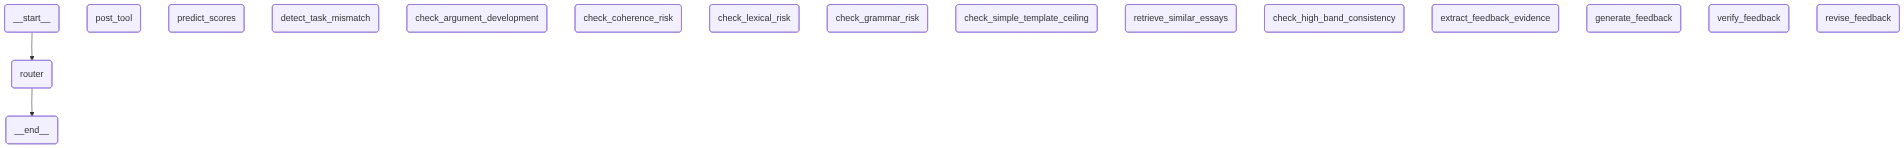

In [27]:
# Render the compiled LangGraph topology
render_aes_langgraph()


# ✅ Sanity Check

In [28]:
# =========================
# NOTEBOOK SANITY CHECK
# =========================

REQUIRED_SYMBOLS = [
    # core tools
    "tool_predict_scores",
    "tool_detect_task_mismatch",
    "tool_check_argument_development",
    "tool_check_coherence_risk",
    "tool_check_lexical_risk",
    "tool_check_grammar_risk",
    "tool_check_simple_template_ceiling",
    "tool_retrieve_similar_essays",
    "tool_extract_feedback_evidence",
    "tool_generate_feedback",
    "tool_verify_feedback",
    "tool_revise_feedback",
    "tool_check_high_band_consistency",

    # routing / orchestration helpers
    "execute_tool_call",
    "choose_next_tool",
    "get_available_tools",
    "fallback_policy",
    "ensure_retrieval_columns",
    "repair_feedback_language_with_llm",
    "enforce_vietnamese_feedback_light",
    "has_missing_feedback_fields",
    "has_english_feedback_fields",

    # langgraph pipeline
    "build_aes_langgraph",
    "AES_LANGGRAPH",
    "render_aes_langgraph",
    "run_agent_feedback_pipeline",
    "run_agent_feedback_pipeline_langgraph",

    # helper functions used by template ceiling / consistency
    "extract_gra_error_candidates_v2",
    "extract_structure_range_features",
    "analyze_body_paragraph_development",
    "extract_template_essay_signals",
    "apply_multi_caps",

    "repair_remaining_english_fields_with_llm",
    "clean_feedback_language_artifacts",
    "feedback_has_topic_drift",
    "feedback_is_too_generic",
    "build_evidence_based_feedback",
    "final_feedback_topic_and_specificity_repair",
]

missing_symbols = [name for name in REQUIRED_SYMBOLS if name not in globals()]
if missing_symbols:
    raise NameError(f"Notebook is missing required symbols: {missing_symbols}")

print("Sanity check passed. All required tool, helper, and LangGraph symbols are defined.")


Sanity check passed. All required tool, helper, and LangGraph symbols are defined.


# 🎯 Demo / Interface

Phần UI này vẫn dùng lại gần như nguyên trạng, nhưng backend gọi `run_agent_feedback_pipeline(...)`
đã được chuyển sang **LangGraph Graph API**.


In [29]:
# =========================
# FULL REPLACEMENT DEMO CELL (PRETTIER UI)
# =========================

import html
import json
import pandas as pd
import gradio as gr


# ---------- helpers ----------
def escape_html(x):
    return html.escape("" if x is None else str(x))


def make_json_safe(obj):
    try:
        return json.loads(json.dumps(obj, ensure_ascii=False, default=str))
    except Exception:
        return {"error": "state is not JSON serializable", "raw": str(obj)}


def feedback_is_empty(feedback):
    if not isinstance(feedback, dict):
        return True

    for crit in ["TR", "CC", "LR", "GRA"]:
        block = feedback.get(crit, {})
        if not isinstance(block, dict):
            continue
        if any(str(block.get(k, "")).strip() for k in ["Strength", "Limitation", "Revision"]):
            return False
    return True


def find_latest_feedback_raw_from_trace(state):
    trace = state.get("trace", []) or []
    for item in reversed(trace):
        tool = str(item.get("chosen_tool", "")).strip()
        tool_result = item.get("tool_result", {}) or {}
        if tool in ["revise_feedback", "generate_feedback"]:
            raw_preview = tool_result.get("raw_preview", "")
            if str(raw_preview).strip():
                return str(raw_preview)
    return ""


def get_status_class(verdict):
    verdict = str(verdict or "").strip().lower()
    if verdict in ["pass", "done", "success"]:
        return "ok"
    if verdict in ["partial_mismatch", "revise", "warning"]:
        return "warn"
    if verdict in ["off_topic", "error", "failed"]:
        return "bad"
    return "muted"


def render_badge(text, status="muted"):
    return f'<span class="badge {escape_html(status)}">{escape_html(text)}</span>'


def render_empty_card(title, subtitle):
    return f"""
    <div class="ui-card">
        <div class="section-title">{escape_html(title)}</div>
        <div class="muted">{escape_html(subtitle)}</div>
    </div>
    """


def render_summary_html(state):
    trace = state.get("trace", []) or []
    pred_scores = state.get("pred_scores", {}) or {}
    done = state.get("done", False)
    done_reason = state.get("done_reason", "") or "N/A"
    revision_count = state.get("revision_count", 0)
    verification = state.get("verification", {}) or {}
    verification_verdict = verification.get("verdict", "")
    task_check = state.get("task_check", {}) or {}
    task_verdict = task_check.get("verdict", "")

    done_badge = render_badge("Done" if done else "Running/Stopped", "ok" if done else "warn")
    verify_badge = render_badge(
        verification_verdict if verification_verdict else "N/A",
        get_status_class(verification_verdict)
    )
    task_badge = render_badge(
        task_verdict if task_verdict else "N/A",
        get_status_class(task_verdict)
    )

    overall = pred_scores.get("Overall", "—")

    return f"""
    <div class="ui-card hero-card">
        <div class="hero-top">
            <div>
                <div class="eyebrow">IELTS AES Agent</div>
                <div class="hero-title">Execution Summary</div>
                <div class="hero-subtitle">{escape_html(done_reason)}</div>
            </div>
            <div class="hero-overall">
                <div class="hero-overall-label">Overall</div>
                <div class="hero-overall-score">{escape_html(overall)}</div>
            </div>
        </div>

        <div class="stats-grid">
            <div class="stat-tile">
                <div class="stat-label">Steps</div>
                <div class="stat-value">{len(trace)}</div>
            </div>
            <div class="stat-tile">
                <div class="stat-label">Revisions</div>
                <div class="stat-value">{revision_count}</div>
            </div>
            <div class="stat-tile">
                <div class="stat-label">Finished</div>
                <div class="stat-value small">{done_badge}</div>
            </div>
            <div class="stat-tile">
                <div class="stat-label">Verification</div>
                <div class="stat-value small">{verify_badge}</div>
            </div>
        </div>

        <div class="chip-row">
            <div class="chip-block"><span class="chip-label">Task check</span>{task_badge}</div>
            <div class="chip-block"><span class="chip-label">Verification</span>{verify_badge}</div>
        </div>
    </div>
    """


def render_scores_html(pred_scores):
    if not pred_scores:
        return render_empty_card("Scores", "Chưa có điểm.")

    def score_card(label, value, accent="blue"):
        return f"""
        <div class="score-card {accent}">
            <div class="score-name">{escape_html(label)}</div>
            <div class="score-value">{escape_html(value)}</div>
        </div>
        """

    return f"""
    <div class="ui-card">
        <div class="section-title">Predicted Scores</div>
        <div class="scores-grid">
            {score_card("TR", pred_scores.get("TR", "—"), "blue")}
            {score_card("CC", pred_scores.get("CC", "—"), "violet")}
            {score_card("LR", pred_scores.get("LR", "—"), "teal")}
            {score_card("GRA", pred_scores.get("GRA", "—"), "orange")}
            {score_card("Overall", pred_scores.get("Overall", "—"), "pink")}
        </div>
    </div>
    """


def render_task_check_html(task_check, pred_scores=None):
    if not task_check:
        return render_empty_card("Task Check", "Chưa có kết quả task check.")

    verdict = str(task_check.get("verdict", "")).strip()
    reason = str(task_check.get("reason", "")).strip()
    evidence = str(task_check.get("evidence", "")).strip()
    missing_parts = task_check.get("missing_parts", []) or []

    badge = render_badge(verdict or "N/A", get_status_class(verdict))

    missing_html = ""
    if missing_parts:
        items = "".join([f"<li>{escape_html(x)}</li>" for x in missing_parts])
        missing_html = f"""
        <div class="subsection">
            <div class="sub-label">Missing parts</div>
            <ul class="nice-list">{items}</ul>
        </div>
        """
    else:
        missing_html = """
        <div class="subsection">
            <div class="sub-label">Missing parts</div>
            <div class="muted">None</div>
        </div>
        """

    tr_html = ""
    if pred_scores:
        tr_html = f"""
        <div class="mini-grid">
            <div class="mini-card">
                <div class="mini-label">TR after guardrail</div>
                <div class="mini-value">{escape_html(pred_scores.get("TR", "N/A"))}</div>
            </div>
            <div class="mini-card">
                <div class="mini-label">Overall</div>
                <div class="mini-value">{escape_html(pred_scores.get("Overall", "N/A"))}</div>
            </div>
        </div>
        """

    return f"""
    <div class="ui-card">
        <div class="section-head">
            <div class="section-title">Task Check</div>
            {badge}
        </div>

        <div class="subsection">
            <div class="sub-label">Reason</div>
            <div class="body-text">{escape_html(reason or "N/A")}</div>
        </div>

        <div class="subsection">
            <div class="sub-label">Evidence</div>
            <div class="body-text">{escape_html(evidence or "N/A")}</div>
        </div>

        {missing_html}
        {tr_html}
    </div>
    """


def render_feedback_html(feedback, feedback_raw=""):
    if not feedback or feedback_is_empty(feedback):
        if str(feedback_raw).strip():
            return f"""
            <div class="ui-card">
                <div class="section-title">Feedback</div>
                <div class="warn-box">Structured parse failed. Đây là raw output từ model.</div>
                <pre class="pretty-pre">{escape_html(feedback_raw)}</pre>
            </div>
            """
        return render_empty_card("Feedback", "Chưa có feedback.")

    crit_colors = {
        "TR": "blue",
        "CC": "violet",
        "LR": "teal",
        "GRA": "orange",
    }

    blocks = []
    for crit in ["TR", "CC", "LR", "GRA"]:
        block = feedback.get(crit, {}) or {}
        strength = str(block.get("Strength", "")).strip() or "—"
        limitation = str(block.get("Limitation", "")).strip() or "—"
        revision = str(block.get("Revision", "")).strip() or "—"

        blocks.append(
            f"""
            <div class="feedback-card {crit_colors.get(crit, 'blue')}">
                <div class="feedback-head">
                    <div class="feedback-crit">{escape_html(crit)}</div>
                </div>

                <div class="feedback-item">
                    <div class="feedback-label">Strength</div>
                    <div class="feedback-text">{escape_html(strength)}</div>
                </div>

                <div class="feedback-item">
                    <div class="feedback-label">Limitation</div>
                    <div class="feedback-text">{escape_html(limitation)}</div>
                </div>

                <div class="feedback-item">
                    <div class="feedback-label">Revision</div>
                    <div class="feedback-text">{escape_html(revision)}</div>
                </div>
            </div>
            """
        )

    return f"""
    <div class="ui-card">
        <div class="section-title">Criterion Feedback</div>
        <div class="feedback-grid">
            {''.join(blocks)}
        </div>
    </div>
    """


def render_verification_html(verification):
    if not verification:
        return render_empty_card("Verification", "Chưa có verification.")

    verdict = str(verification.get("verdict", "")).strip()
    issues = verification.get("issues", []) or []
    badge = render_badge(verdict or "N/A", get_status_class(verdict))

    if not issues:
        issues_html = '<div class="success-box">No issues. Feedback passed verification.</div>'
    else:
        cards = []
        for i, issue in enumerate(issues, start=1):
            criterion = str(issue.get("criterion", "")).strip()
            problem = str(issue.get("problem", "")).strip()
            reason = str(issue.get("reason", "")).strip()
            fix_instruction = str(issue.get("fix_instruction", "")).strip()

            cards.append(
                f"""
                <div class="issue-card">
                    <div class="issue-top">
                        <div class="issue-index">#{i}</div>
                        <div class="issue-criterion">{escape_html(criterion)}</div>
                    </div>
                    <div class="issue-row"><span>Problem</span>{escape_html(problem or "N/A")}</div>
                    <div class="issue-row"><span>Reason</span>{escape_html(reason or "N/A")}</div>
                    <div class="issue-row"><span>Fix</span>{escape_html(fix_instruction or "N/A")}</div>
                </div>
                """
            )
        issues_html = f'<div class="issues-grid">{"".join(cards)}</div>'

    return f"""
    <div class="ui-card">
        <div class="section-head">
            <div class="section-title">Verification</div>
            {badge}
        </div>
        {issues_html}
    </div>
    """


def prepare_cases_df(top_cases):
    if top_cases is None:
        return pd.DataFrame()

    try:
        df = pd.DataFrame(top_cases)
    except Exception:
        return pd.DataFrame()

    if len(df) == 0:
        return pd.DataFrame()

    out = df.copy()

    for c in ["prompt", "essay", "evaluation", "doc_text"]:
        if c in out.columns:
            out[c] = out[c].astype(str).str.replace("\n", " ", regex=False).str.slice(0, 240)

    preferred = ["TR", "CC", "LR", "GRA", "Overall", "final_score", "prompt", "essay"]
    cols = [c for c in preferred if c in out.columns]

    if not cols:
        return out.reset_index(drop=True)

    return out[cols].reset_index(drop=True)


def render_cases_info_html(top_cases):
    try:
        n = len(top_cases or [])
    except Exception:
        n = 0

    if n == 0:
        return render_empty_card("Retrieved Cases", "Không có retrieved cases.")

    return f"""
    <div class="ui-card">
        <div class="section-head">
            <div class="section-title">Retrieved Cases</div>
            {render_badge(f"{n} cases", "ok")}
        </div>
        <div class="body-text">
            Các bài tương tự đã được truy xuất từ vector database để grounding feedback.
        </div>
    </div>
    """


def render_trace_html(trace):
    if not trace:
        return """
        <div class="trace-wrap">
            <div class="trace-card">
                <div class="trace-title">No trace</div>
            </div>
        </div>
        """

    blocks = []
    for t in trace:
        step = t.get("step", "")
        tool = t.get("chosen_tool", "")
        source = t.get("source", "")
        thought = t.get("thought", "")
        fallback_reason = t.get("fallback_reason", "")
        raw_decision = t.get("raw_decision", "")
        parsed_tool_call = t.get("parsed_tool_call", {})
        tool_result = t.get("tool_result", {})

        try:
            parsed_pretty = json.dumps(parsed_tool_call, indent=2, ensure_ascii=False, default=str)
        except Exception:
            parsed_pretty = str(parsed_tool_call)

        try:
            tool_result_pretty = json.dumps(tool_result, indent=2, ensure_ascii=False, default=str)
        except Exception:
            tool_result_pretty = str(tool_result)

        tool_badge = render_badge(tool or "N/A", "ok")
        source_badge = render_badge(source or "N/A", "muted")

        blocks.append(
            f"""
            <div class="trace-card">
                <div class="trace-head">
                    <div class="trace-title">Step {escape_html(step)}</div>
                    <div class="trace-badges">{tool_badge}{source_badge}</div>
                </div>

                <div class="trace-line"><span>Thought</span>{escape_html(thought or "N/A")}</div>
                <div class="trace-line"><span>Fallback</span>{escape_html(fallback_reason or "None")}</div>

                <details>
                    <summary>Raw decision</summary>
                    <pre class="trace-pre">{escape_html(raw_decision)}</pre>
                </details>

                <details>
                    <summary>Parsed tool call</summary>
                    <pre class="trace-pre">{escape_html(parsed_pretty)}</pre>
                </details>

                <details open>
                    <summary>Tool result</summary>
                    <pre class="trace-pre">{escape_html(tool_result_pretty)}</pre>
                </details>
            </div>
            """
        )

    return f'<div class="trace-wrap">{"".join(blocks)}</div>'


def run_demo_pipeline(prompt, essay):
    if not str(prompt).strip() or not str(essay).strip():
        empty_html = render_empty_card("Thiếu dữ liệu", "Vui lòng nhập cả đề bài và essay.")
        empty_df = pd.DataFrame()
        empty_trace = """
        <div class="trace-wrap">
            <div class="trace-card">
                <div class="trace-title">No trace</div>
            </div>
        </div>
        """
        return (
            empty_html,   # summary_out
            empty_html,   # feedback_preview_out
            empty_html,   # scores_out
            empty_html,   # task_out
            empty_html,   # feedback_tab_out
            empty_html,   # verification_out
            empty_df,     # cases_df_out
            empty_html,   # cases_info_out
            empty_trace,  # trace_out
            {},           # state_out
        )

    state = run_agent_feedback_pipeline(
        prompt=prompt,
        essay=essay,
        df=df_retrieval,
        db_embeddings=db_embeddings,
        max_steps=MAX_AGENT_STEPS,
        top_k_vector=20,
        top_k_final=5,
        verbose=False,
    )
    feedback_raw = state.get("feedback_raw", "")
    if not str(feedback_raw).strip():
        feedback_raw = find_latest_feedback_raw_from_trace(state)

    summary_html = render_summary_html(state)
    scores_html = render_scores_html(state.get("pred_scores"))
    task_html = render_task_check_html(state.get("task_check"), state.get("pred_scores"))
    feedback_html = render_feedback_html(state.get("feedback"), feedback_raw)
    verification_html = render_verification_html(state.get("verification"))
    cases_df = prepare_cases_df(state.get("top_cases"))
    cases_info_html = render_cases_info_html(state.get("top_cases"))
    trace_html = render_trace_html(state.get("trace", []))
    safe_state = make_json_safe(state)

    return (
        summary_html,       # summary_out
        feedback_html,      # feedback_preview_out
        scores_html,        # scores_out
        task_html,          # task_out
        feedback_html,      # feedback_tab_out
        verification_html,  # verification_out
        cases_df,           # cases_df_out
        cases_info_html,    # cases_info_out
        trace_html,         # trace_out
        safe_state,         # state_out
    )


# ---------- CSS ----------
DEMO_CSS = """
:root{
  --bg: #08111f;
  --bg-2: #0b1426;
  --panel: rgba(14, 24, 43, 0.88);
  --panel-2: rgba(17, 28, 49, 0.96);
  --panel-soft: rgba(20, 33, 57, 0.85);
  --border: rgba(110, 140, 190, 0.18);
  --text: #e8eefc;
  --muted: #95a3c7;
  --blue: #60a5fa;
  --violet: #a78bfa;
  --teal: #2dd4bf;
  --orange: #f59e0b;
  --pink: #f472b6;
  --red: #f87171;
  --green: #34d399;
  --yellow: #fbbf24;
  --shadow: 0 10px 30px rgba(0,0,0,.28);
}

.gradio-container{
  background:
    radial-gradient(circle at top left, rgba(37,99,235,.20), transparent 28%),
    radial-gradient(circle at top right, rgba(168,85,247,.14), transparent 24%),
    linear-gradient(180deg, #07101d 0%, #0a1220 100%) !important;
  color: var(--text) !important;
}

.gradio-container, .gradio-container *{
  color: var(--text);
}

.block, .gr-box, .gr-panel, .gr-form{
  background: transparent !important;
  border-color: transparent !important;
  box-shadow: none !important;
}

label, .gradio-container .prose, .gr-markdown, .gr-form *{
  color: var(--text) !important;
}

textarea, input{
  background: rgba(11, 19, 35, 0.92) !important;
  color: var(--text) !important;
  border: 1px solid rgba(120,145,190,.18) !important;
  border-radius: 16px !important;
  box-shadow: inset 0 1px 0 rgba(255,255,255,.02) !important;
}

textarea:focus, input:focus{
  border-color: rgba(96,165,250,.55) !important;
  box-shadow: 0 0 0 3px rgba(96,165,250,.12) !important;
}

button.primary, button[variant="primary"]{
  background: linear-gradient(90deg, #2563eb 0%, #4f46e5 100%) !important;
  color: white !important;
  border: none !important;
  border-radius: 14px !important;
  min-height: 46px !important;
  box-shadow: 0 10px 24px rgba(37,99,235,.28) !important;
}

button.primary:hover, button[variant="primary"]:hover{
  filter: brightness(1.05);
}

.ui-card{
  background: linear-gradient(180deg, rgba(17,28,49,.96) 0%, rgba(13,22,39,.94) 100%);
  border: 1px solid var(--border);
  border-radius: 22px;
  padding: 18px;
  box-shadow: var(--shadow);
}

.hero-card{
  padding: 22px;
}

.hero-top{
  display: flex;
  align-items: flex-start;
  justify-content: space-between;
  gap: 20px;
  margin-bottom: 18px;
}

.eyebrow{
  font-size: 12px;
  letter-spacing: .12em;
  text-transform: uppercase;
  color: #8fb7ff;
  margin-bottom: 6px;
}

.hero-title{
  font-size: 28px;
  font-weight: 800;
  line-height: 1.15;
  margin-bottom: 6px;
}

.hero-subtitle{
  color: var(--muted);
  font-size: 14px;
}

.hero-overall{
  min-width: 120px;
  text-align: center;
  background: linear-gradient(180deg, rgba(96,165,250,.15), rgba(168,85,247,.12));
  border: 1px solid rgba(120,145,190,.22);
  border-radius: 20px;
  padding: 14px 16px;
}

.hero-overall-label{
  color: var(--muted);
  font-size: 12px;
  margin-bottom: 6px;
}

.hero-overall-score{
  font-size: 34px;
  font-weight: 800;
}

.section-head{
  display:flex;
  align-items:center;
  justify-content:space-between;
  gap:12px;
  margin-bottom: 14px;
}

.section-title{
  font-size: 18px;
  font-weight: 800;
  margin-bottom: 12px;
}

.stats-grid{
  display:grid;
  grid-template-columns: repeat(4, minmax(0,1fr));
  gap: 12px;
}

.stat-tile{
  background: rgba(255,255,255,.025);
  border: 1px solid rgba(120,145,190,.15);
  border-radius: 16px;
  padding: 14px;
}

.stat-label{
  color: var(--muted);
  font-size: 12px;
  margin-bottom: 8px;
}

.stat-value{
  font-size: 22px;
  font-weight: 800;
}

.stat-value.small{
  font-size: 15px;
  font-weight: 600;
}

.chip-row{
  display:flex;
  gap:12px;
  flex-wrap:wrap;
  margin-top: 14px;
}

.chip-block{
  display:flex;
  align-items:center;
  gap:10px;
  background: rgba(255,255,255,.025);
  border: 1px solid rgba(120,145,190,.14);
  padding: 10px 12px;
  border-radius: 14px;
}

.chip-label{
  color: var(--muted);
  font-size: 13px;
}

.badge{
  display:inline-flex;
  align-items:center;
  gap:8px;
  padding: 6px 10px;
  border-radius: 999px;
  font-size: 12px;
  font-weight: 700;
  border: 1px solid transparent;
  white-space: nowrap;
}

.badge.ok{
  background: rgba(52,211,153,.10);
  color: #9ff2cf;
  border-color: rgba(52,211,153,.22);
}

.badge.warn{
  background: rgba(251,191,36,.10);
  color: #ffe08a;
  border-color: rgba(251,191,36,.22);
}

.badge.bad{
  background: rgba(248,113,113,.11);
  color: #ffb1b1;
  border-color: rgba(248,113,113,.22);
}

.badge.muted{
  background: rgba(148,163,184,.10);
  color: #d3dceb;
  border-color: rgba(148,163,184,.16);
}

.scores-grid{
  display:grid;
  grid-template-columns: repeat(5, minmax(0,1fr));
  gap: 12px;
}

.score-card{
  border-radius: 18px;
  padding: 16px;
  border: 1px solid rgba(255,255,255,.06);
  background: rgba(255,255,255,.025);
}

.score-card.blue{ box-shadow: inset 0 0 0 1px rgba(96,165,250,.08); }
.score-card.violet{ box-shadow: inset 0 0 0 1px rgba(167,139,250,.08); }
.score-card.teal{ box-shadow: inset 0 0 0 1px rgba(45,212,191,.08); }
.score-card.orange{ box-shadow: inset 0 0 0 1px rgba(245,158,11,.08); }
.score-card.pink{ box-shadow: inset 0 0 0 1px rgba(244,114,182,.08); }

.score-name{
  color: var(--muted);
  font-size: 13px;
  margin-bottom: 10px;
}

.score-value{
  font-size: 28px;
  font-weight: 800;
  line-height: 1;
}

.subsection{
  margin-top: 12px;
  padding: 14px;
  border-radius: 16px;
  background: rgba(255,255,255,.025);
  border: 1px solid rgba(120,145,190,.12);
}

.sub-label{
  font-size: 12px;
  text-transform: uppercase;
  letter-spacing: .06em;
  color: #9bb2e2;
  margin-bottom: 8px;
}

.body-text{
  line-height: 1.65;
  color: var(--text);
}

.muted{
  color: var(--muted);
}

.nice-list{
  margin: 0;
  padding-left: 18px;
  color: var(--text);
}

.mini-grid{
  display:grid;
  grid-template-columns: repeat(2, minmax(0,1fr));
  gap: 12px;
  margin-top: 12px;
}

.mini-card{
  background: rgba(255,255,255,.025);
  border: 1px solid rgba(120,145,190,.12);
  padding: 14px;
  border-radius: 14px;
}

.mini-label{
  color: var(--muted);
  font-size: 12px;
  margin-bottom: 8px;
}

.mini-value{
  font-size: 22px;
  font-weight: 800;
}

.feedback-grid{
  display:grid;
  grid-template-columns: repeat(2, minmax(0,1fr));
  gap: 14px;
}

.feedback-card{
  border-radius: 18px;
  padding: 16px;
  border: 1px solid rgba(120,145,190,.14);
  background: rgba(255,255,255,.025);
}

.feedback-card.blue{ box-shadow: inset 0 0 0 1px rgba(96,165,250,.08); }
.feedback-card.violet{ box-shadow: inset 0 0 0 1px rgba(167,139,250,.08); }
.feedback-card.teal{ box-shadow: inset 0 0 0 1px rgba(45,212,191,.08); }
.feedback-card.orange{ box-shadow: inset 0 0 0 1px rgba(245,158,11,.08); }

.feedback-head{
  display:flex;
  align-items:center;
  justify-content:space-between;
  margin-bottom: 10px;
}

.feedback-crit{
  font-size: 18px;
  font-weight: 800;
}

.feedback-item{
  padding: 12px 0;
  border-top: 1px solid rgba(255,255,255,.06);
}

.feedback-item:first-of-type{
  border-top: 0;
}

.feedback-label{
  color: #9bb2e2;
  font-size: 12px;
  text-transform: uppercase;
  letter-spacing: .06em;
  margin-bottom: 7px;
}

.feedback-text{
  line-height: 1.65;
  color: var(--text);
  white-space: pre-wrap;
}

.pretty-pre{
  background: #08101d;
  border: 1px solid rgba(120,145,190,.16);
  color: #dbe7ff;
  padding: 14px;
  border-radius: 16px;
  white-space: pre-wrap;
  word-break: break-word;
  overflow-x: auto;
}

.warn-box{
  background: rgba(251,191,36,.10);
  color: #ffe08a;
  border: 1px solid rgba(251,191,36,.18);
  padding: 12px 14px;
  border-radius: 14px;
  margin-bottom: 12px;
}

.success-box{
  background: rgba(52,211,153,.10);
  color: #b3f5d8;
  border: 1px solid rgba(52,211,153,.18);
  padding: 14px;
  border-radius: 14px;
}

.issues-grid{
  display:grid;
  grid-template-columns: repeat(2, minmax(0,1fr));
  gap: 12px;
}

.issue-card{
  background: rgba(255,255,255,.025);
  border: 1px solid rgba(120,145,190,.14);
  border-radius: 16px;
  padding: 14px;
}

.issue-top{
  display:flex;
  align-items:center;
  gap:10px;
  margin-bottom: 12px;
}

.issue-index{
  width: 28px;
  height: 28px;
  border-radius: 999px;
  display:flex;
  align-items:center;
  justify-content:center;
  background: rgba(248,113,113,.14);
  color: #ffb1b1;
  font-weight: 800;
  font-size: 12px;
}

.issue-criterion{
  font-weight: 800;
  font-size: 16px;
}

.issue-row{
  display:grid;
  grid-template-columns: 72px 1fr;
  gap: 10px;
  margin-top: 8px;
  line-height: 1.55;
}

.issue-row span{
  color: #9bb2e2;
  font-weight: 700;
  font-size: 12px;
  text-transform: uppercase;
}

.trace-wrap{
  display:flex;
  flex-direction:column;
  gap:12px;
}

.trace-card{
  border: 1px solid rgba(120,145,190,.16);
  border-radius: 18px;
  padding: 16px;
  background: linear-gradient(180deg, rgba(17,28,49,.96) 0%, rgba(11,20,37,.94) 100%);
  box-shadow: var(--shadow);
}

.trace-head{
  display:flex;
  align-items:center;
  justify-content:space-between;
  gap:12px;
  margin-bottom: 10px;
}

.trace-badges{
  display:flex;
  gap:8px;
  flex-wrap:wrap;
}

.trace-title{
  font-weight: 800;
  font-size: 18px;
}

.trace-line{
  display:grid;
  grid-template-columns: 84px 1fr;
  gap: 10px;
  margin-top: 8px;
  line-height: 1.5;
}

.trace-line span{
  color: #9bb2e2;
  font-weight: 700;
  font-size: 12px;
  text-transform: uppercase;
}

.trace-card details{
  margin-top: 12px;
  border-top: 1px solid rgba(255,255,255,.06);
  padding-top: 12px;
}

.trace-card summary{
  cursor: pointer;
  font-weight: 700;
  color: #a8c5ff;
}

.trace-pre{
  white-space: pre-wrap;
  word-break: break-word;
  background: #07101d;
  color: #dbe7ff;
  padding: 12px;
  border-radius: 14px;
  border: 1px solid rgba(120,145,190,.16);
  margin-top: 10px;
  font-size: 13px;
  line-height: 1.55;
  overflow-x: auto;
}

.gradio-container .tab-nav{
  background: rgba(255,255,255,.02) !important;
  border: 1px solid rgba(120,145,190,.12) !important;
  border-radius: 16px !important;
  padding: 6px !important;
}

.gradio-container .tab-nav button{
  border-radius: 12px !important;
}

.gradio-container .tab-nav button.selected{
  background: linear-gradient(90deg, rgba(37,99,235,.22), rgba(79,70,229,.18)) !important;
}

footer{
  display:none !important;
}

@media (max-width: 1100px){
  .scores-grid{
    grid-template-columns: repeat(2, minmax(0,1fr));
  }
  .feedback-grid, .issues-grid{
    grid-template-columns: 1fr;
  }
  .stats-grid{
    grid-template-columns: repeat(2, minmax(0,1fr));
  }
}

@media (max-width: 700px){
  .hero-top{
    flex-direction: column;
  }
  .mini-grid{
    grid-template-columns: 1fr;
  }
}
"""


# ---------- close old demo if exists ----------
if 'demo' in globals():
    try:
        globals()['demo'].close()
    except Exception:
        pass


# ---------- UI ----------
with gr.Blocks(
    title="IELTS AES Agent Demo",
    theme=gr.themes.Soft(),
    css=DEMO_CSS
) as demo:
    gr.HTML("""
    <div class="ui-card hero-card" style="margin-bottom:14px;">
        <div class="eyebrow">Demo Interface</div>
        <div class="hero-title">IELTS Writing Task 2 AES Agent</div>
        <div class="hero-subtitle">
            Scoring · Task Guardrail · Retrieval · Feedback · Verification · Revision
        </div>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=5):
            prompt_in = gr.Textbox(
                label="Essay Prompt",
                lines=7,
                placeholder="Paste IELTS Writing Task 2 prompt here..."
            )
            essay_in = gr.Textbox(
                label="Essay",
                lines=18,
                placeholder="Paste essay here..."
            )
            run_btn = gr.Button("Run Demo", variant="primary")

        with gr.Column(scale=5):
            summary_out = gr.HTML()
            feedback_preview_out = gr.HTML()

    with gr.Tabs():
        with gr.Tab("Scores & Task Check"):
            scores_out = gr.HTML()
            task_out = gr.HTML()

        with gr.Tab("Feedback"):
            feedback_tab_out = gr.HTML()
            verification_out = gr.HTML()

        with gr.Tab("Retrieved Cases"):
            cases_info_out = gr.HTML()
            cases_df_out = gr.Dataframe(
                label="Top retrieved cases",
                interactive=False
            )

        with gr.Tab("Trace"):
            trace_out = gr.HTML()

        with gr.Tab("Raw State"):
            state_out = gr.JSON(label="Agent state")

    run_btn.click(
        fn=run_demo_pipeline,
        inputs=[prompt_in, essay_in],
        outputs=[
            summary_out,
            feedback_preview_out,
            scores_out,
            task_out,
            feedback_tab_out,
            verification_out,
            cases_df_out,
            cases_info_out,
            trace_out,
            state_out,
        ],
    )

demo.launch(debug=True, share=True)

/tmp/ipykernel_6415/3408300799.py:1087: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_6415/3408300799.py:1087: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://534af6672c46a58d3d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://534af6672c46a58d3d.gradio.live


In [ ]:
# =========================
# DEBUG FEEDBACK SOURCE CELL
# =========================

debug_prompt = """Some people believe that artificial intelligence will eventually replace human teachers in education. To what extent do you agree or disagree?"""

debug_essay = """In recent years, artificial intelligence has made remarkable progress in education, offering personalised learning platforms, instant feedback, and automated assessment tools. Some therefore argue that AI will eventually replace human teachers altogether. While I accept that AI will transform the way students learn, I strongly disagree that it can fully substitute for human educators, because teaching involves not only the delivery of information but also emotional guidance, moral judgement, and adaptive human interaction.

Admittedly, AI has several advantages that make it a powerful educational tool. Unlike traditional classroom instruction, AI-based systems can analyse a learner’s performance in real time and provide exercises tailored to their specific weaknesses. For example, a student struggling with algebra can receive unlimited practice questions, step-by-step explanations, and immediate correction without having to wait for a teacher’s availability. In this sense, AI can make learning more efficient, especially in large classes where individual attention is often limited. Moreover, automated platforms can reduce the burden of repetitive tasks such as marking quizzes, tracking attendance, and generating progress reports, allowing schools to operate more effectively.

However, the role of a teacher extends far beyond transmitting knowledge. A good teacher does not merely explain concepts; they notice when a student is anxious, discouraged, overconfident, or silently falling behind. These subtle emotional and psychological signals are often expressed through tone, facial expression, hesitation, or behaviour, and they require empathy rather than computation. For instance, a student who repeatedly performs poorly may not need another set of practice exercises, but encouragement, reassurance, or a change in learning strategy. Although AI can simulate supportive language, it does not genuinely understand human emotions or build trust in the same way a caring teacher can.

Furthermore, education is also a social and moral process. Teachers help students develop discipline, curiosity, cooperation, and ethical awareness, all of which are difficult to cultivate through algorithms alone. In a classroom, students learn how to debate respectfully, listen to different perspectives, handle failure, and work with others. These experiences depend heavily on human relationships and real social interaction. If education were reduced to individualised screen-based learning, students might gain technical knowledge but lose many of the interpersonal skills that are essential for adult life.

Finally, human teachers are better equipped to deal with uncertainty and context. AI systems rely on data, patterns, and predefined objectives, but real classrooms are unpredictable. A teacher may need to abandon a planned lesson because students are confused, connect a topic to a recent event, or respond sensitively to a student’s personal circumstances. Such decisions require professional judgement, cultural understanding, and moral responsibility. AI can assist in these situations, but it should not be the final authority, especially when students’ development and wellbeing are at stake.

In conclusion, artificial intelligence will undoubtedly become an important part of education, particularly in personalising learning and reducing administrative work. Nevertheless, it cannot fully replace human teachers, whose value lies in empathy, judgement, social guidance, and the ability to respond meaningfully to individual students. The future of education, therefore, is unlikely to be teacherless; rather, it will be most effective when AI supports teachers instead of replacing them."""

debug_state = run_agent_feedback_pipeline(
    prompt=debug_prompt,
    essay=debug_essay,
    df=df_retrieval,
    db_embeddings=db_embeddings,
    max_steps=20,
    top_k_vector=20,
    top_k_final=5,
    verbose=True,
)

fb = debug_state.get("feedback", {})

print("feedback_source =", debug_state.get("feedback_source"))
print("feedback_source_reason =", debug_state.get("feedback_source_reason"))
print(
    "feedback_source_extra =",
    json.dumps(debug_state.get("feedback_source_extra", {}), ensure_ascii=False, indent=2)
)

print("feedback_total_length =", _feedback_total_length(fb))
print("topic_drift =", feedback_has_topic_drift(fb, debug_prompt, debug_essay))
print("too_generic =", feedback_is_too_generic(fb))

print("\n===== FINAL FEEDBACK =====")
print(json.dumps(fb, ensure_ascii=False, indent=2))

print("\n===== DONE REASON =====")
print(debug_state.get("done_reason"))

print("\n===== TOOL TRACE =====")
for i, step in enumerate(debug_state.get("trace", []), start=1):
    print(
        i,
        "| chosen_tool =", step.get("chosen_tool"),
        "| source =", step.get("source"),
        "| fallback_reason =", step.get("fallback_reason"),
    )


[Step 1] DECISION
chosen_tool   : predict_scores
source        : rule
thought       : Only one valid tool is available in the current state.
fallback      : None
raw_decision  : [deterministic] only one valid tool: predict_scores


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[Step 1] TOOL RESULT
{
  "scores": {
    "TR": 9.0,
    "CC": 8.5,
    "LR": 8.5,
    "GRA": 8.5,
    "Overall": 8.5
  }
}

[Step 2] DECISION
chosen_tool   : detect_task_mismatch
source        : rule
thought       : Selected detect_task_mismatch by deterministic pipeline priority.
fallback      : None
raw_decision  : [deterministic] forced priority tool: detect_task_mismatch
